# Exploratory Data Analysis  Lung-PET-CT-Dx Dataset

Understand the dataset completely before any modelling decisions are made.


## 1. Setup

In [3]:
import os
import glob
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pydicom
from tqdm.auto import tqdm

ROOT      = r"E:\Dissertation - Code\LPT\manifest-1608669183333"
IMG_ROOT  = os.path.join(ROOT, "Lung-PET-CT-Dx")
ANN_ROOT  = os.path.join(ROOT, "Annotation")
META_CSV  = os.path.join(ROOT, "metadata.csv")
CLIN_XLS  = os.path.join(ROOT, "statistics-clinical-20201221.xlsx")

SUBTYPE_NAME = {
    "A": "Adenocarcinoma",
    "B": "Small cell carcinoma",
    "E": "Large cell carcinoma",
    "G": "Squamous cell carcinoma",
}
COLORS = {"A": "#4C72B0", "B": "#DD8452", "E": "#55A868", "G": "#C44E52"}

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

print("ROOT exists:", os.path.isdir(ROOT))
print("Annotation folder exists:", os.path.isdir(ANN_ROOT))
print("metadata.csv exists:", os.path.isfile(META_CSV))
print("Clinical xlsx exists:", os.path.isfile(CLIN_XLS))

ROOT exists: True
Annotation folder exists: True
metadata.csv exists: True
Clinical xlsx exists: True


e:\Dissertation - Code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Collection-level overview

In [4]:
meta = pd.read_csv(META_CSV)

meta["File Location"] = meta["File Location"].apply(
    lambda p: os.path.normpath(os.path.join(ROOT, p))
)

n_patients = meta["Subject ID"].nunique()
n_series   = meta["Series UID"].nunique()
n_images   = meta["Number of Images"].sum()

print(f"Patients   : {n_patients}")
print(f"Series     : {n_series}")
print(f"Total DICOM files : {n_images:,}")
print()
print("Breakdown by modality and SOP class:")
breakdown = (
    meta.groupby(["Modality", "SOP Class Name"])["Number of Images"]
    .agg(series="count", total_images="sum", mean_images_per_series="mean")
    .round(1)
)
print(breakdown.to_string())
print()
print("Study date range:")
dates = pd.to_datetime(meta["Study Date"], errors="coerce")
print(f"  Earliest : {dates.min().date()}")
print(f"  Latest   : {dates.max().date()}")
print(f"  Span     : {(dates.max() - dates.min()).days} days")

Patients   : 355
Series     : 1295
Total DICOM files : 251,135

Breakdown by modality and SOP class:
                                                     series  total_images  mean_images_per_series
Modality SOP Class Name                                                                          
CT       CT Image Storage                               881        148457                   168.5
         Secondary Capture Image Storage                281         57002                   202.9
PT       Positron Emission Tomography Image Storage     133         45676                   343.4

Study date range:
  Earliest : 2004-07-01
  Latest   : 2011-06-09
  Span     : 2534 days


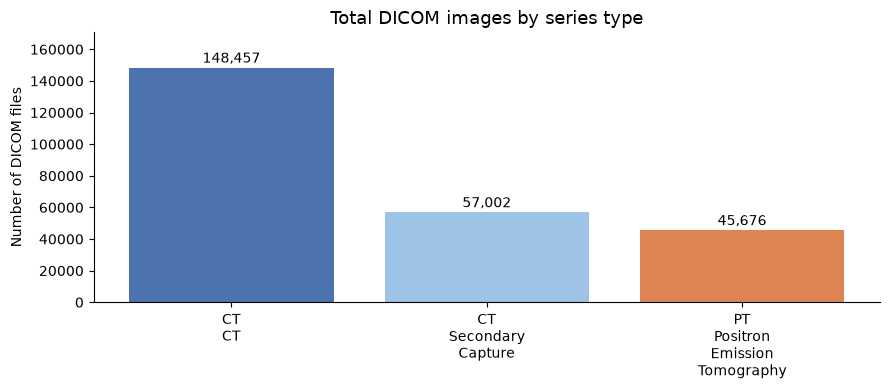

In [5]:
# Visual breakdown of image count by modality/SOP class
plot_data = (
    meta.groupby(["Modality", "SOP Class Name"])["Number of Images"]
    .sum()
    .reset_index()
)
labels = [f"{row.Modality}\n{row['SOP Class Name'].replace(' Image Storage','').replace(' ','\n')}" for _, row in plot_data.iterrows()]
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, plot_data["Number of Images"], color=["#4C72B0","#9DC3E6","#DD8452"])
for bar, val in zip(bars, plot_data["Number of Images"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, f"{val:,}",
            ha="center", va="bottom", fontsize=10)
ax.set_title("Total DICOM images by series type", fontsize=13)
ax.set_ylabel("Number of DICOM files")
ax.set_ylim(0, max(plot_data["Number of Images"]) * 1.15)
plt.tight_layout()
plt.show()

## 3. Patient demographics and clinical data

In [6]:
clin = pd.read_excel(CLIN_XLS)
print("Clinical table shape:", clin.shape)
print("Columns:", list(clin.columns))
print()
print(clin.head(5).to_string())
print()
print("Missing values per column:")
print(clin.isnull().sum().to_string())

Clinical table shape: (355, 10)
Columns: ['No.', 'NewPatientID', 'Sex', 'Age', 'weight (kg)', 'T-Stage', 'N-Stage', 'Ｍ-Stage', 'Histopathological grading', 'Smoking History']

   No. NewPatientID Sex   Age  weight (kg) T-Stage  N-Stage Ｍ-Stage Histopathological grading  Smoking History
0    1        A0001   M  58.0         65.0      2b        3      1b                        G3                1
1    2        A0002   F  53.0         55.0      2b        1       0                       NaN                0
2    3        A0003   M  60.0         62.0      1c        1       0                        G3                0
3    4        A0004   F  48.0         56.0      1c        3       0                       NaN                0
4    5        A0005   M  70.0         75.0      1b        0       0                        G2                1

Missing values per column:
No.                            0
NewPatientID                   0
Sex                            0
Age                            

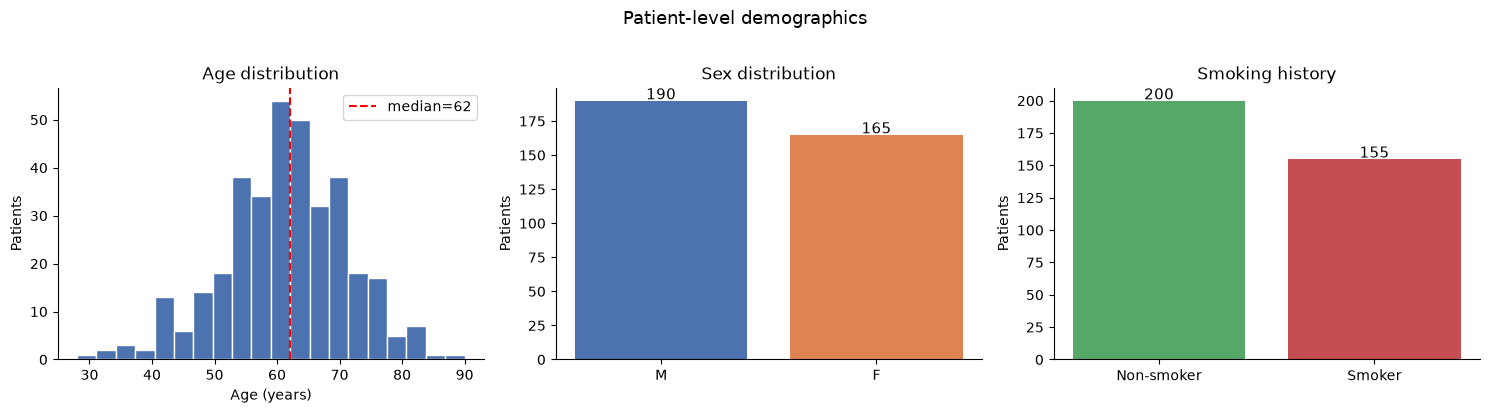

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age
axes[0].hist(clin["Age"].dropna(), bins=20, color="#4C72B0", edgecolor="white")
axes[0].axvline(clin["Age"].median(), color="red", linestyle="--", label=f"median={clin['Age'].median():.0f}")
axes[0].set_title("Age distribution")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Patients")
axes[0].legend()

# Sex
sex_counts = clin["Sex"].value_counts()
axes[1].bar(sex_counts.index, sex_counts.values, color=["#4C72B0","#DD8452"])
for i, (k, v) in enumerate(sex_counts.items()):
    axes[1].text(i, v + 1, str(v), ha="center", fontsize=11)
axes[1].set_title("Sex distribution")
axes[1].set_ylabel("Patients")

# Smoking history
smoke_counts = clin["Smoking History"].value_counts().sort_index()
smoke_labels = {0: "Non-smoker", 1: "Smoker"}
axes[2].bar([smoke_labels.get(k, str(k)) for k in smoke_counts.index],
            smoke_counts.values, color=["#55A868","#C44E52"])
for i, v in enumerate(smoke_counts.values):
    axes[2].text(i, v + 1, str(v), ha="center", fontsize=11)
axes[2].set_title("Smoking history")
axes[2].set_ylabel("Patients")

plt.suptitle("Patient-level demographics", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Stage columns found: ['T-Stage', 'N-Stage', 'Ｍ-Stage']


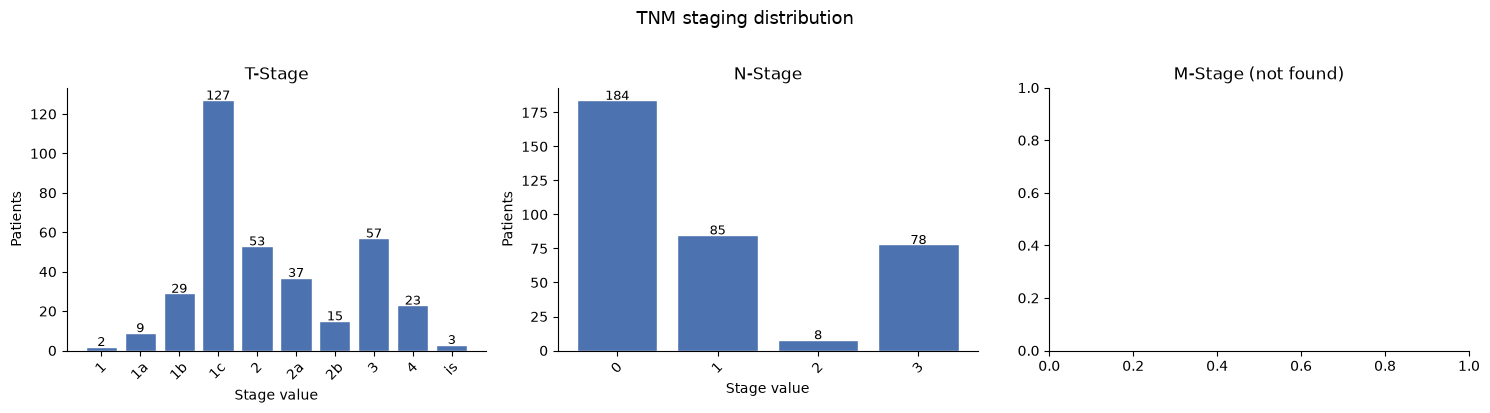

Histopathological grading:
Histopathological grading
 G1       1
 G3       1
G1       11
G1-2      7
G1-G2     2
G2       27
G2-3     34
G2-G3     1
G3       61
  Missing: 210


In [8]:
# TNM staging
stage_cols = [c for c in clin.columns if 'stage' in c.lower()]
print('Stage columns found:', stage_cols)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, letter, title in zip(axes, ['t', 'n', 'm'], ['T-Stage', 'N-Stage', 'M-Stage']):
    # Match column by first letter, tolerating unicode (full-width M = \uff2d)
    actual_col = next(
        (c for c in clin.columns
         if 'stage' in c.lower() and c.lower().replace('\uff2d', 'm')[0] == letter),
        None
    )
    if actual_col is None:
        ax.set_title(title + ' (not found)')
        continue
    counts = clin[actual_col].astype(str).value_counts().sort_index()
    ax.bar(counts.index, counts.values, color='#4C72B0', edgecolor='white')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.3, str(v), ha='center', fontsize=9)
    ax.set_title(title)
    ax.set_ylabel('Patients')
    ax.set_xlabel('Stage value')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('TNM staging distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('Histopathological grading:')
grade_col = next((c for c in clin.columns if 'grad' in c.lower()), None)
if grade_col:
    print(clin[grade_col].astype(str).value_counts().sort_index().to_string())
    print('  Missing:', clin[grade_col].isnull().sum())


## 4. Cancer subtype distribution

Patient count per subtype:
  A – Adenocarcinoma               :  251 patients (70.7%)
  B – Small cell carcinoma         :   38 patients (10.7%)
  E – Large cell carcinoma         :    5 patients (1.4%)
  G – Squamous cell carcinoma      :   61 patients (17.2%)


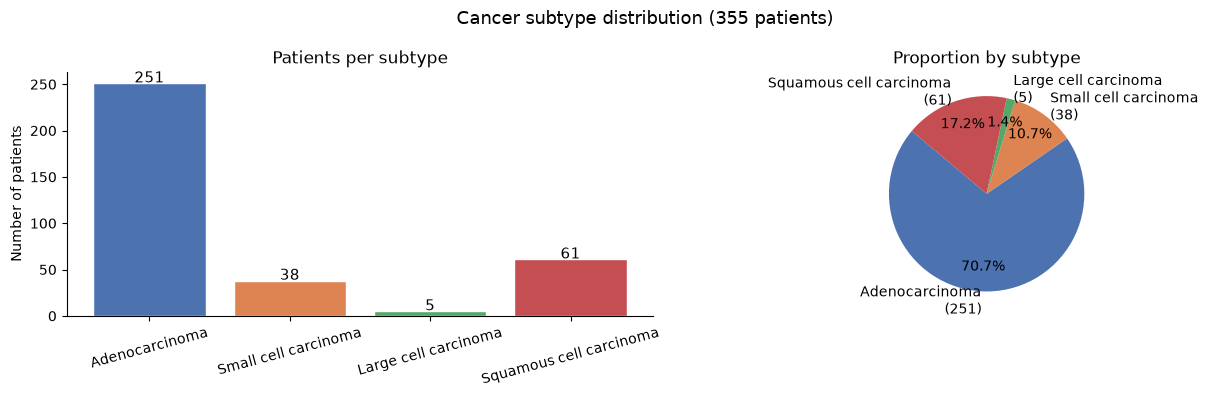

In [9]:
# Subtype is encoded in the patient ID prefix: Lung_Dx-A/B/E/G
patients = meta["Subject ID"].drop_duplicates().sort_values()
subtype_code = patients.str.replace("Lung_Dx-", "", regex=False).str[0]
subtype_series = pd.Series(subtype_code.values, index=patients.values, name="subtype")
subtype_counts = subtype_series.map(SUBTYPE_NAME).value_counts()

print("Patient count per subtype:")
for code, name in SUBTYPE_NAME.items():
    n = (subtype_code == code).sum()
    pct = 100 * n / len(patients)
    print(f"  {code} – {name:<28} : {n:>4} patients ({pct:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

names  = [SUBTYPE_NAME[c] for c in ["A","B","E","G"]]
counts = [(subtype_code == c).sum() for c in ["A","B","E","G"]]
clrs   = [COLORS[c] for c in ["A","B","E","G"]]

bars = axes[0].bar(names, counts, color=clrs, edgecolor="white")
for bar, v in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 1, str(v), ha="center", fontsize=11)
axes[0].set_title("Patients per subtype")
axes[0].set_ylabel("Number of patients")
axes[0].tick_params(axis="x", rotation=15)

axes[1].pie(counts, labels=[f"{n}\n({v})" for n, v in zip(names, counts)],
            colors=clrs, autopct="%1.1f%%", startangle=140, pctdistance=0.75)
axes[1].set_title("Proportion by subtype")

plt.suptitle("Cancer subtype distribution (355 patients)", fontsize=13)
plt.tight_layout()
plt.show()

PET patient count per subtype:
  A – Adenocarcinoma               :   95 PET patients (71.4%)
  B – Small cell carcinoma         :    9 PET patients (6.8%)
  E – Large cell carcinoma         :    0 PET patients (0.0%)
  G – Squamous cell carcinoma      :   29 PET patients (21.8%)

Total PET patients: 133


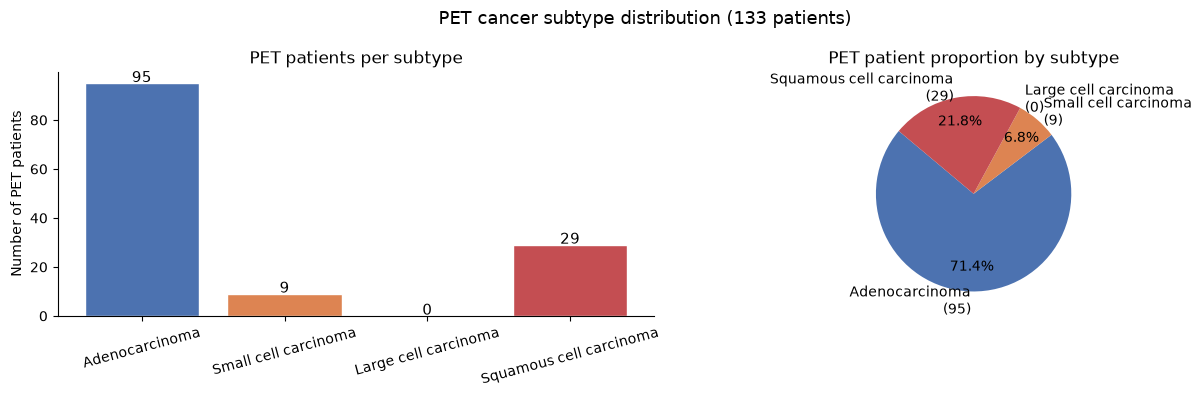

In [62]:
# PET subtype distribution
# PET/PT availability is based on metadata rows where Modality == "PT"
# or SOP Class Name indicates PET / Positron Emission Tomography Image Storage

pet_meta = meta[
    (meta["Modality"].astype(str).str.upper().isin(["PT", "PET"])) |
    (meta["SOP Class Name"].astype(str).str.contains("PET|Positron", case=False, na=False))
].copy()

# Unique patients with PET/PT data
pet_patients = pet_meta["Subject ID"].drop_duplicates().sort_values()

# Subtype is encoded in the patient ID prefix: Lung_Dx-A/B/E/G
pet_subtype_code = (
    pet_patients
    .str.replace("Lung_Dx-", "", regex=False)
    .str[0]
)

pet_subtype_series = pd.Series(
    pet_subtype_code.values,
    index=pet_patients.values,
    name="PET subtype"
)

pet_subtype_counts = pet_subtype_series.map(SUBTYPE_NAME).value_counts()

print("PET patient count per subtype:")
for code, name in SUBTYPE_NAME.items():
    n = (pet_subtype_code == code).sum()
    pct = 100 * n / len(pet_patients) if len(pet_patients) else 0
    print(f"  {code} – {name:<28} : {n:>4} PET patients ({pct:.1f}%)")

print(f"\nTotal PET patients: {len(pet_patients)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

order = ["A", "B", "E", "G"]

names  = [SUBTYPE_NAME[c] for c in order]
counts = [(pet_subtype_code == c).sum() for c in order]
clrs   = [COLORS[c] for c in order]

# Bar chart
bars = axes[0].bar(names, counts, color=clrs, edgecolor="white")

for bar, v in zip(bars, counts):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.5,
        str(v),
        ha="center",
        fontsize=11
    )

axes[0].set_title("PET patients per subtype")
axes[0].set_ylabel("Number of PET patients")
axes[0].tick_params(axis="x", rotation=15)

# Pie chart
axes[1].pie(
    counts,
    labels=[f"{n}\n({v})" for n, v in zip(names, counts)],
    colors=clrs,
    autopct=lambda pct: f"{pct:.1f}%" if pct > 0 else "",
    startangle=140,
    pctdistance=0.75
)

axes[1].set_title("PET patient proportion by subtype")

plt.suptitle(f"PET cancer subtype distribution ({len(pet_patients)} patients)", fontsize=13)
plt.tight_layout()
plt.show()

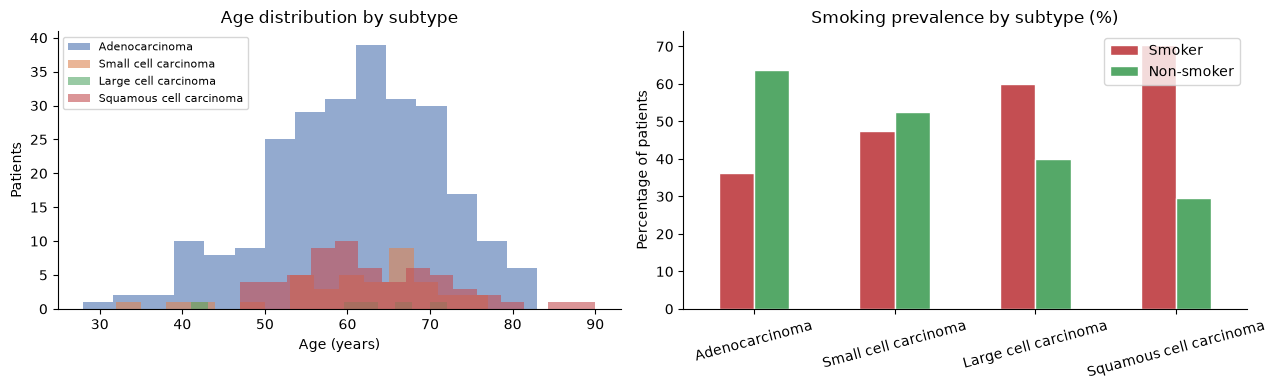

In [ ]:
# Link subtype to clinical features
# Map the clinical patient ID to subtype 
id_col = next((c for c in clin.columns if "patientid" in c.lower() or "id" in c.lower()), clin.columns[1])
clin["subtype_code"] = clin[id_col].astype(str).str[0]
clin["subtype_name"] = clin["subtype_code"].map(SUBTYPE_NAME)

# Age by subtype
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for code in ["A","B","E","G"]:
    ages = clin[clin["subtype_code"] == code]["Age"].dropna()
    if len(ages):
        axes[0].hist(ages, bins=15, alpha=0.6, label=SUBTYPE_NAME[code], color=COLORS[code])
axes[0].set_title("Age distribution by subtype")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Patients")
axes[0].legend(fontsize=8)

# Smoking by subtype
smoke_col = next((c for c in clin.columns if "smok" in c.lower()), None)
if smoke_col:
    smoke_by_sub = clin.groupby("subtype_code")[smoke_col].value_counts(normalize=True).unstack(fill_value=0) * 100
    smoke_by_sub.index = [SUBTYPE_NAME.get(c, c) for c in smoke_by_sub.index]
    smoke_by_sub.rename(columns={0: "Non-smoker", 1: "Smoker"}, inplace=True)
    smoke_by_sub[["Smoker", "Non-smoker"]].plot(kind="bar", ax=axes[1],
                                                  color=["#C44E52","#55A868"], edgecolor="white")
    axes[1].set_title("Smoking prevalence by subtype (%)")
    axes[1].set_ylabel("Percentage of patients")
    axes[1].tick_params(axis="x", rotation=15)
    axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Modality breakdown : CT vs PET vs Secondary Capture

In [10]:
# How many patients have each modality?
for mod in ["CT", "PT"]:
    n = meta[meta.Modality == mod]["Subject ID"].nunique()
    print(f"Patients with at least one {mod} series: {n}")

# CT series per patient
ct_all = meta[meta.Modality == "CT"]
ct_img = meta[(meta.Modality == "CT") & (meta["SOP Class Name"] == "CT Image Storage")]
ct_sc  = meta[(meta.Modality == "CT") & (meta["SOP Class Name"] == "Secondary Capture Image Storage")]
pt     = meta[meta.Modality == "PT"]

print()
print("CT Image Storage series per patient:")
print(ct_img.groupby("Subject ID")["Series UID"].nunique().describe().round(2).to_string())
print()
print("Secondary Capture series per patient:")
print(ct_sc.groupby("Subject ID")["Series UID"].nunique().describe().round(2).to_string())
print()
print("PET series per patient:")
print(pt.groupby("Subject ID")["Series UID"].nunique().describe().round(2).to_string())

Patients with at least one CT series: 355
Patients with at least one PT series: 133

CT Image Storage series per patient:
count    355.00
mean       2.48
std        1.19
min        1.00
25%        2.00
50%        2.00
75%        2.00
max       12.00

Secondary Capture series per patient:
count    133.00
mean       2.11
std        0.36
min        1.00
25%        2.00
50%        2.00
75%        2.00
max        3.00

PET series per patient:
count    133.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0


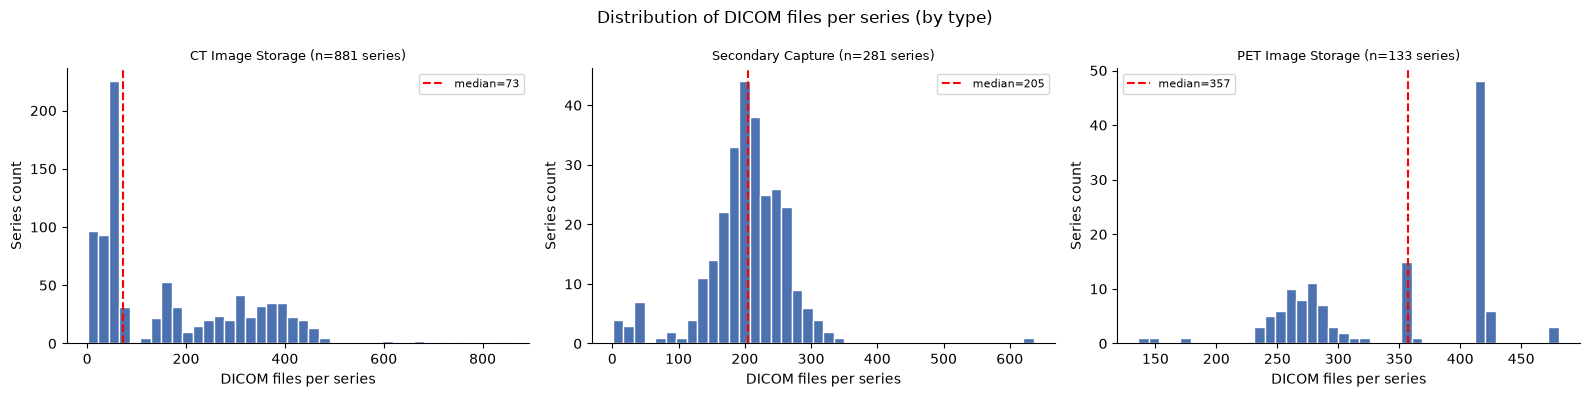

In [11]:
# Slices per series for each type
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, df, title in zip(
    axes,
    [ct_img, ct_sc, pt],
    ["CT Image Storage (n=881 series)",
     "Secondary Capture (n=281 series)",
     "PET Image Storage (n=133 series)"],
):
    ax.hist(df["Number of Images"], bins=40, color="#4C72B0", edgecolor="white")
    ax.axvline(df["Number of Images"].median(), color="red", linestyle="--",
               label=f"median={df['Number of Images'].median():.0f}")
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("DICOM files per series")
    ax.set_ylabel("Series count")
    ax.legend(fontsize=8)

plt.suptitle("Distribution of DICOM files per series (by type)", fontsize=12)
plt.tight_layout()
plt.show()

Patients per subtype per series type:
subtype_name                                Adenocarcinoma  Small cell carcinoma  Large cell carcinoma  Squamous cell carcinoma  TOTAL
SOP Class Name                                                                                                                        
CT Image Storage                                       251                    38                     5                       61    355
Positron Emission Tomography Image Storage              95                     9                     0                       29    133
Secondary Capture Image Storage                         95                     9                     0                       29    133

Images per subtype per series type:
subtype_name                                Adenocarcinoma  Small cell carcinoma  Large cell carcinoma  Squamous cell carcinoma   TOTAL
SOP Class Name                                                                                                    

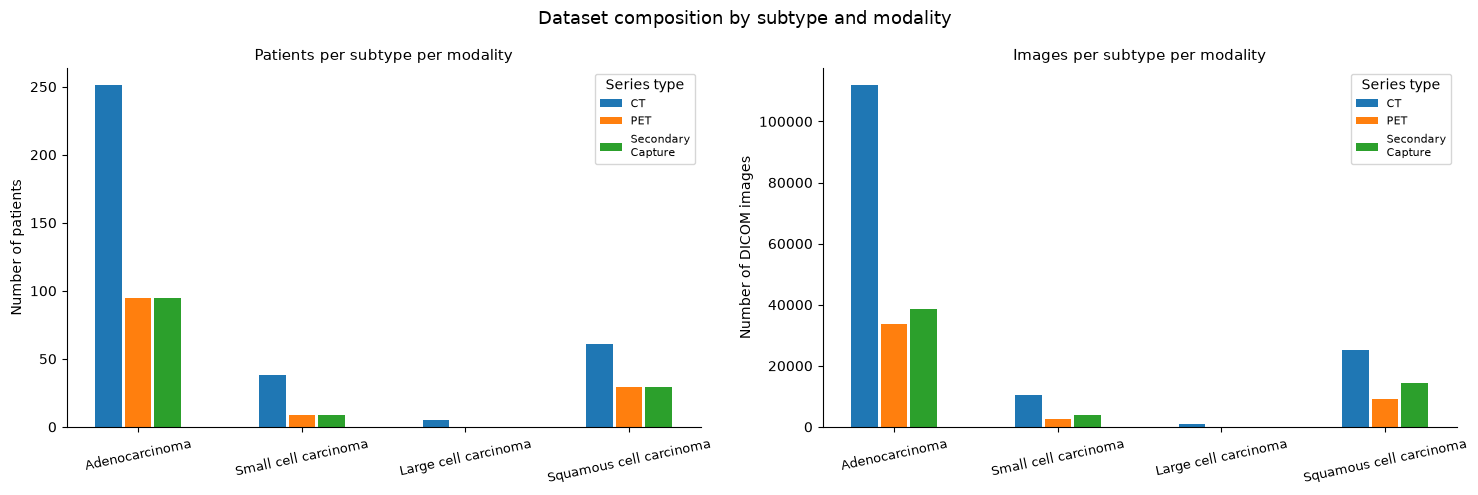

In [ ]:
# Patients and images per subtype per modality/series-type

# Extract subtype code from Subject ID
meta["subtype"] = (
    meta["Subject ID"]
    .str.replace("Lung_Dx-", "", regex=False)
    .str[0]
)
meta["subtype_name"] = meta["subtype"].map(SUBTYPE_NAME)

# Patient counts
pat_mod = (
    meta.groupby(["SOP Class Name", "subtype_name"])["Subject ID"]
    .nunique()
    .unstack(fill_value=0)
)
# reorder subtypes
col_order = [SUBTYPE_NAME[c] for c in ["A", "B", "E", "G"] if SUBTYPE_NAME[c] in pat_mod.columns]
pat_mod = pat_mod[col_order]
pat_mod["TOTAL"] = pat_mod.sum(axis=1)

print("Patients per subtype per series type:")
print(pat_mod.to_string())
print()

# Image counts
img_mod = (
    meta.groupby(["SOP Class Name", "subtype_name"])["Number of Images"]
    .sum()
    .unstack(fill_value=0)
)
img_mod = img_mod[col_order]
img_mod["TOTAL"] = img_mod.sum(axis=1)

print("Images per subtype per series type:")
print(img_mod.to_string())
print()

# Visualisation
short_labels = {
    "CT Image Storage":                             "CT",
    "Secondary Capture Image Storage":              "Secondary\nCapture",
    "Positron Emission Tomography Image Storage":   "PET",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = range(len(col_order))
width = 0.18
colors = [COLORS[c] for c in ["A", "B", "E", "G"]]

for ax, df, ylabel, title in zip(
    axes,
    [pat_mod, img_mod],
    ["Number of patients", "Number of DICOM images"],
    ["Patients per subtype per modality", "Images per subtype per modality"],
):
    row_labels = [short_labels.get(r, r) for r in df.index if r != "TOTAL" or False]
    # one group of bars per series type
    n_rows = len(df) - 0  # exclude TOTAL column already handled
    for ri, (row_name, row) in enumerate(df.drop(columns="TOTAL").iterrows()):
        offset = (ri - (len(df) - 1) / 2) * width
        bars = ax.bar(
            [xi + offset for xi in x],
            row.values,
            width=width * 0.9,
            label=short_labels.get(row_name, row_name),
        )
    ax.set_xticks(list(x))
    ax.set_xticklabels(col_order, rotation=12, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11)
    ax.legend(title="Series type", fontsize=8)

plt.suptitle("Dataset composition by subtype and modality", fontsize=13)
plt.tight_layout()
plt.show()


## 6. CT technical parameters

In [ ]:
# Sample DICOM headers from CT Image Storage series to extract scanner parameters.
SAMPLE_N = 300  # number of series to sample

tags_of_interest = [
    "Manufacturer", "ManufacturerModelName", "KVP", "XRayTubeCurrent",
    "SliceThickness", "PixelSpacing", "ConvolutionKernel",
    "Rows", "Columns", "RescaleSlope", "RescaleIntercept",
    "ContrastBolusAgent", "StudyDate",
]

ct_series_sample = ct_img.sample(min(SAMPLE_N, len(ct_img)), random_state=42)
records = []

for _, row in tqdm(ct_series_sample.iterrows(), total=len(ct_series_sample), desc="Reading DICOM headers"):
    loc = row["File Location"]
    if not os.path.isdir(loc):
        continue
    dcm_files = sorted(glob.glob(os.path.join(loc, "*.dcm")))
    if not dcm_files:
        continue
    # Read middle slice 
    mid_file = dcm_files[len(dcm_files) // 2]
    try:
        ds = pydicom.dcmread(mid_file, stop_before_pixels=True)
    except Exception:
        continue
    rec = {"series_uid": row["Series UID"], "patient_id": row["Subject ID"],
           "n_slices": len(dcm_files)}
    for tag in tags_of_interest:
        val = getattr(ds, tag, None)
        if val is not None and hasattr(val, "__iter__") and not isinstance(val, str):
            val = list(val)
        rec[tag] = val
    records.append(rec)

ct_params = pd.DataFrame(records)
print(f"Sampled {len(ct_params)} CT series")
print(ct_params[["Manufacturer", "ManufacturerModelName"]].value_counts().head(15).to_string())

Reading DICOM headers: 100%|██████████| 300/300 [00:01<00:00, 261.18it/s]

Sampled 300 CT series
Manufacturer        ManufacturerModelName
SIEMENS             Biograph 64              75
GE MEDICAL SYSTEMS  Discovery CT750 HD       65
                    LightSpeed VCT           49
SIEMENS             Sensation 10             38
Philips             iCT 256                  29
                    Brilliance16             16
SIEMENS             Biograph64               13
GE MEDICAL SYSTEMS  Optima CT660              8
                    LightSpeed Pro 16         5
                    Revolution CT             2


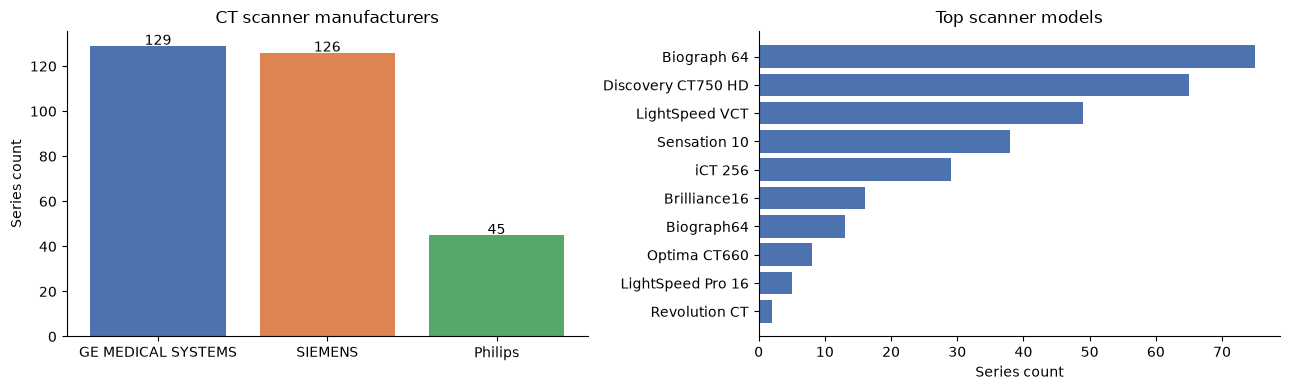

In [14]:
# Manufacturer distribution
mfr_counts = ct_params["Manufacturer"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(mfr_counts.index, mfr_counts.values, color=["#4C72B0","#DD8452","#55A868"])
for i, v in enumerate(mfr_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha="center")
axes[0].set_title("CT scanner manufacturers")
axes[0].set_ylabel("Series count")

model_counts = ct_params["ManufacturerModelName"].value_counts().head(10)
axes[1].barh(model_counts.index[::-1], model_counts.values[::-1], color="#4C72B0")
axes[1].set_title("Top scanner models")
axes[1].set_xlabel("Series count")

plt.tight_layout()
plt.show()

Slice thickness (mm) — statistics:
count    300.000
mean       5.203
std       23.609
min        0.625
25%        1.000
50%        5.000
75%        5.000
max      410.545

Value counts:
SliceThickness
0.625000        1
1.000000      101
1.250000        7
3.000000        4
5.000000      163
6.000000        2
7.000000        1
8.000000        3
10.000000      17
410.545457      1

Pixel spacing (mm/pixel) — statistics:
count    300.0000
mean       0.7425
std        0.0736
min        0.5449
25%        0.6836
50%        0.7363
75%        0.7812
max        0.9766


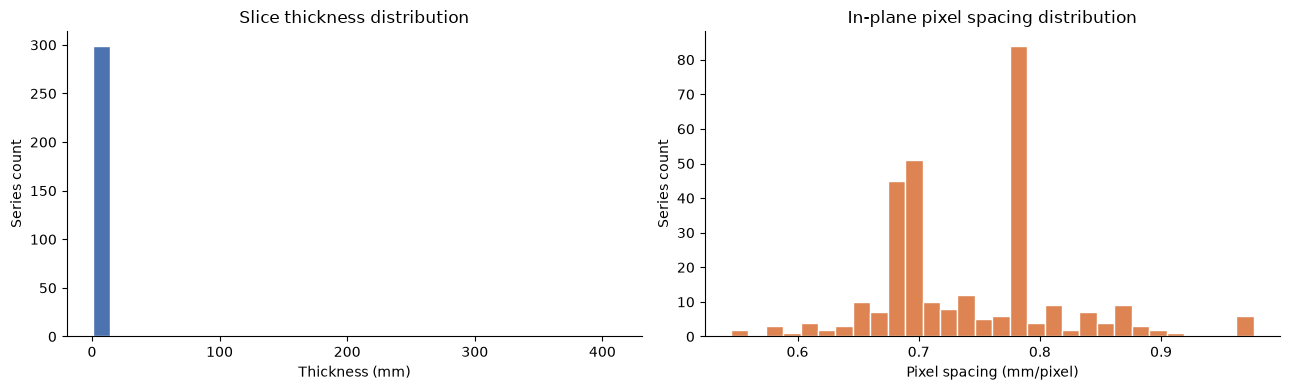

In [15]:
# Slice thickness distribution
thickness = pd.to_numeric(ct_params["SliceThickness"], errors="coerce").dropna()
print("Slice thickness (mm) — statistics:")
print(thickness.describe().round(3).to_string())
print("\nValue counts:")
print(thickness.value_counts().sort_index().to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(thickness, bins=30, color="#4C72B0", edgecolor="white")
axes[0].set_title("Slice thickness distribution")
axes[0].set_xlabel("Thickness (mm)")
axes[0].set_ylabel("Series count")

# Pixel spacing (in-plane resolution)
spacing_vals = []
for v in ct_params["PixelSpacing"].dropna():
    if isinstance(v, list) and len(v) >= 1:
        try:
            spacing_vals.append(float(v[0]))
        except (ValueError, TypeError):
            pass
spacing = np.array(spacing_vals)
print("\nPixel spacing (mm/pixel) — statistics:")
print(pd.Series(spacing).describe().round(4).to_string())

axes[1].hist(spacing, bins=30, color="#DD8452", edgecolor="white")
axes[1].set_title("In-plane pixel spacing distribution")
axes[1].set_xlabel("Pixel spacing (mm/pixel)")
axes[1].set_ylabel("Series count")

plt.tight_layout()
plt.show()

Reconstruction kernels (top 15):
ConvolutionKernel
B70f              65
STANDARD          62
LUNG              60
B31f              27
B                 22
B40f              17
B30f              16
YB                14
L                  6
SOFT               6
IMR1,SharpPlus     3
B70s               1
CHST               1


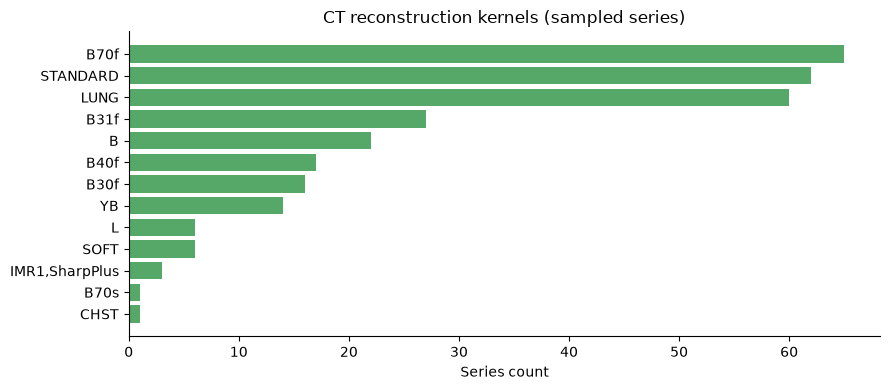


KVP: KVP
80.0       9
100.0     23
120.0    266
140.0      2

Tube current (mA) stats: count    300.0
mean     187.0
std       77.1
min       40.0
25%      150.0
50%      173.0
75%      217.0
max      591.0


In [ ]:
# Reconstruction kernel
kernel_counts = ct_params["ConvolutionKernel"].value_counts().head(15)
print("Reconstruction kernels (top 15):")
print(kernel_counts.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(kernel_counts.index[::-1], kernel_counts.values[::-1], color="#55A868")
ax.set_title("CT reconstruction kernels (sampled series)")
ax.set_xlabel("Series count")
plt.tight_layout()
plt.show()

print()

kvp = pd.to_numeric(ct_params["KVP"], errors="coerce").dropna()
ma  = pd.to_numeric(ct_params["XRayTubeCurrent"], errors="coerce").dropna()
print("KVP:", kvp.value_counts().sort_index().to_string())
print()
print("Tube current (mA) stats:", ma.describe().round(1).to_string())

CT series descriptions (top 20):
Series Description
5mm                           131
Thorax  1.0  B70f             129
5mm Lung SS50                  91
Thorax  1.0  B31f              91
A phase 5mm Stnd SS50          69
Recon 2 5mm                    46
ThoraxRoutine  10.0  B40f      44
ThoraxRoutine  5.0.0  B70f     43
CT WB  1.0  B30f               43
5mm Stnd SS50                  27
Smart Prep Series              16
lung iDose 3                   14
iDose 2                        12
iDose 4                        11
FBP                            11
lung IDose iDose 4             10
10mm                            6
Recon 3 5mm                     6
IMR                             6
CT WB  3.0  B30f                6

CT Image Storage series per patient:
Series UID
1       6
2     267
3      37
4      20
5      11
6      11
8       1
9       1
12      1


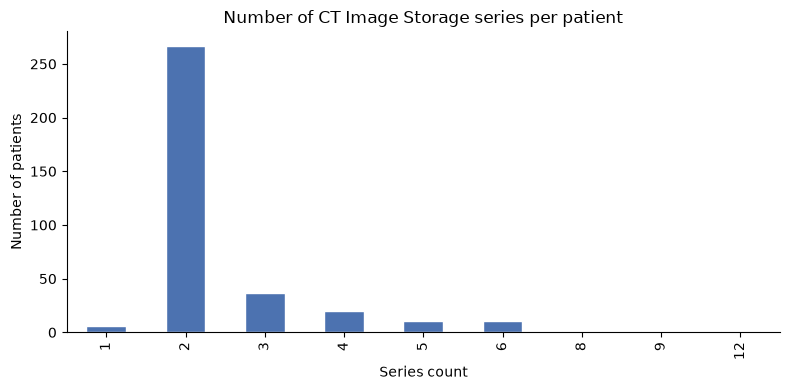


Interpretation: most patients have 2–3 CT reconstructions of the same study.
These are typically a standard soft-tissue kernel and a sharp lung kernel,
or thin-slice and thick-slice reconstructions from the same raw acquisition.


In [17]:
# Series descriptions reveal the clinical protocol intent
print("CT series descriptions (top 20):")
print(ct_img["Series Description"].value_counts().head(20).to_string())

# How many patients have multiple CT series reconstructions?
ct_series_per_patient = ct_img.groupby("Subject ID")["Series UID"].nunique()
print()
print("CT Image Storage series per patient:")
print(ct_series_per_patient.value_counts().sort_index().to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ct_series_per_patient.value_counts().sort_index().plot(kind="bar", ax=ax, color="#4C72B0", edgecolor="white")
ax.set_title("Number of CT Image Storage series per patient")
ax.set_xlabel("Series count")
ax.set_ylabel("Number of patients")
plt.tight_layout()
plt.show()

print()
print("Interpretation: most patients have 2–3 CT reconstructions of the same study.")
print("These are typically a standard soft-tissue kernel and a sharp lung kernel,")
print("or thin-slice and thick-slice reconstructions from the same raw acquisition.")

## 7. PET series 

In [18]:
# Read one PET DICOM to understand its content
pt_row = pt.iloc[0]
pt_loc = pt_row["File Location"]
pt_files = sorted(glob.glob(os.path.join(pt_loc, "*.dcm")))

if pt_files:
    ds_pet = pydicom.dcmread(pt_files[len(pt_files)//2], stop_before_pixels=True)
    print("=== Sample PET DICOM header ===")
    pet_tags = [
        "Modality", "Manufacturer", "ManufacturerModelName",
        "SeriesDescription", "Units", "CorrectedImage",
        "Rows", "Columns", "SliceThickness", "PixelSpacing",
        "RescaleSlope", "RescaleIntercept",
    ]
    for tag in pet_tags:
        print(f"  {tag}: {getattr(ds_pet, tag, 'N/A')}")

print()
print("PET series descriptions:")
print(pt["Series Description"].value_counts().to_string())
print()
print("Slices per PET series:")
print(pt["Number of Images"].describe().round(1).to_string())

=== Sample PET DICOM header ===
  Modality: PT
  Manufacturer: SIEMENS
  ManufacturerModelName: Biograph 64_mCT
  SeriesDescription: PET WB Corrected
  Units: BQML
  CorrectedImage: ['NORM', 'DTIM', 'ATTN', 'SCAT', 'DECY', 'RAN']
  Rows: 200
  Columns: 200
  SliceThickness: 2.027
  PixelSpacing: [4.07283, 4.07283]
  RescaleSlope: 2.23188
  RescaleIntercept: 0

PET series descriptions:
Series Description
PET WB Corrected    133

Slices per PET series:
count    133.0
mean     343.4
std       78.6
min      136.0
25%      273.0
50%      357.0
75%      419.0
max      481.0


## 8. Secondary Capture series

=== Sample Secondary Capture DICOM header ===
  Modality: CT
  SOPClassName: N/A
  SeriesDescription: Range-CT WB  1.0  B30f-Tra-<ALPHA Range>
  Rows: 512
  Columns: 512
  SamplesPerPixel: 3
  BitsAllocated: 8
  PhotometricInterpretation: RGB
  Pixel array shape: (512, 512, 3)
  Pixel array dtype: uint8



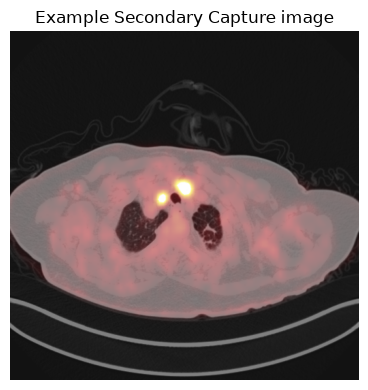

Secondary Capture series descriptions:
Series Description
Range-CT WB  1.0  B30f-Tra-ALPHA Range     245
ALPHA Range                                 11
Range-Thorax  1.0  B70f-Tra-ALPHA Range     10
ALPHA Range1                                 6
ALPHA Range2                                 4
Range-CT WB  3.0  B30f-Tra-ALPHA Range       3
Range-CT WB  1.0  B30f-Tra-MPR Range         2


In [19]:
# Read one Secondary Capture DICOM
sc_row = ct_sc.iloc[0]
sc_files = sorted(glob.glob(os.path.join(sc_row["File Location"], "*.dcm")))

if sc_files:
    ds_sc = pydicom.dcmread(sc_files[0])
    print("=== Sample Secondary Capture DICOM header ===")
    for tag in ["Modality", "SOPClassName", "SeriesDescription", "Rows", "Columns", "SamplesPerPixel",
                "BitsAllocated", "PhotometricInterpretation"]:
        val = getattr(ds_sc, tag, None)
        if val is None:
            val = ds_sc.get(tag, "N/A")
        print(f"  {tag}: {val}")
    print(f"  Pixel array shape: {ds_sc.pixel_array.shape}")
    print(f"  Pixel array dtype: {ds_sc.pixel_array.dtype}")
    print()
    fig, ax = plt.subplots(figsize=(6, 4))
    px = ds_sc.pixel_array
    if px.ndim == 3:
        ax.imshow(px)
    else:
        ax.imshow(px, cmap="gray")
    ax.set_title("Example Secondary Capture image")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

print("Secondary Capture series descriptions:")
print(ct_sc["Series Description"].value_counts().head(10).to_string())

## 9. Annotation structure and coverage

In [20]:
# Show the full structure of one XML annotation
ann_patient_dirs = sorted(os.listdir(ANN_ROOT))
print(f"Annotation folders: {len(ann_patient_dirs)}")
print(f"First 5: {ann_patient_dirs[:5]}")
print()

# Parse one example
example_dir = os.path.join(ANN_ROOT, ann_patient_dirs[0])
example_xml = sorted(glob.glob(os.path.join(example_dir, "*.xml")))[0]
tree = ET.parse(example_xml)
root_el = tree.getroot()

print("XML file name (= SOP Instance UID of the annotated DICOM):")
print(" ", os.path.basename(example_xml))
print()
print("XML content:")

def print_xml(elem, indent=0):
    text = (elem.text or "").strip()
    line = " " * indent + f"<{elem.tag}>"
    if text:
        line += f" {text}"
    print(line)
    for child in elem:
        print_xml(child, indent + 2)

print_xml(root_el)

Annotation folders: 358
First 5: ['A0001', 'A0002', 'A0003', 'A0004', 'A0005']

XML file name (= SOP Instance UID of the annotated DICOM):
  1.3.6.1.4.1.14519.5.2.1.6655.2359.102500633407588554681658808214.xml

XML content:
<annotation>
  <folder> Unknow
  <filename> Unknow
  <path> Unknow
  <source> Unknow
    <database> Unknown
  <size>
    <width> 512
    <height> 512
    <depth> 1
  <segmented> 0
  <object>
    <name> A
    <pose> Unspecified
    <truncated> 0
    <Difficult> 0
    <bndbox>
      <xmin> 286
      <ymin> 310
      <xmax> 355
      <ymax> 402


In [ ]:
# Parse all annotations : collect per-patient and per-slice statistics

def parse_annotation(xml_path):
    """Return list of dicts, one per bounding box in the XML."""
    sop_uid = os.path.splitext(os.path.basename(xml_path))[0]
    try:
        tree = ET.parse(xml_path)
    except ET.ParseError:
        return []
    root_el = tree.getroot()
    boxes = []
    for obj in root_el.findall("object"):
        name = obj.findtext("name", "").strip()
        bnd  = obj.find("bndbox")
        if bnd is None:
            continue
        try:
            x1 = float(bnd.findtext("xmin"))
            y1 = float(bnd.findtext("ymin"))
            x2 = float(bnd.findtext("xmax"))
            y2 = float(bnd.findtext("ymax"))
        except (TypeError, ValueError):
            continue
        boxes.append({
            "sop_uid": sop_uid,
            "label": name,
            "x1": x1, "y1": y1, "x2": x2, "y2": y2,
            "w": x2 - x1, "h": y2 - y1,
            "area_px": (x2 - x1) * (y2 - y1),
        })
    return boxes

all_boxes = []
patient_ann_count = defaultdict(int)  # annotated slices per patient

for pat_dir in tqdm(ann_patient_dirs, desc="Parsing annotations"):
    pat_id = pat_dir  # e.g. A0001
    full_dir = os.path.join(ANN_ROOT, pat_dir)
    if not os.path.isdir(full_dir):
        continue
    xml_files = glob.glob(os.path.join(full_dir, "*.xml"))
    patient_ann_count[pat_id] = len(xml_files)
    for xf in xml_files:
        for box in parse_annotation(xf):
            box["patient_id"] = pat_id
            box["subtype"] = pat_id[0] if pat_id else "?"
            all_boxes.append(box)

boxes_df = pd.DataFrame(all_boxes)
print(f"Total annotated XML files  : {sum(patient_ann_count.values())}")
print(f"Total bounding boxes       : {len(boxes_df)}")
print(f"Patients with annotations  : {len(patient_ann_count)}")
print()
print("Boxes per label (subtype):")
print(boxes_df["label"].value_counts().to_string())

Parsing annotations: 100%|██████████| 358/358 [05:20<00:00,  1.12it/s]

Total annotated XML files  : 31562
Total bounding boxes       : 31659
Patients with annotations  : 358

Boxes per label (subtype):
label
A        13065
a         7911
G         5270
B         2244
g         2089
b          860
E          201
Q           10
A0192        9


Annotated slices per patient — statistics:
count    358.0
mean      88.2
std       99.7
min        0.0
25%       19.0
50%       45.0
75%      124.8
max      586.0

Patients with 0 annotated slices: 1
Patients with annotated slices  : 357


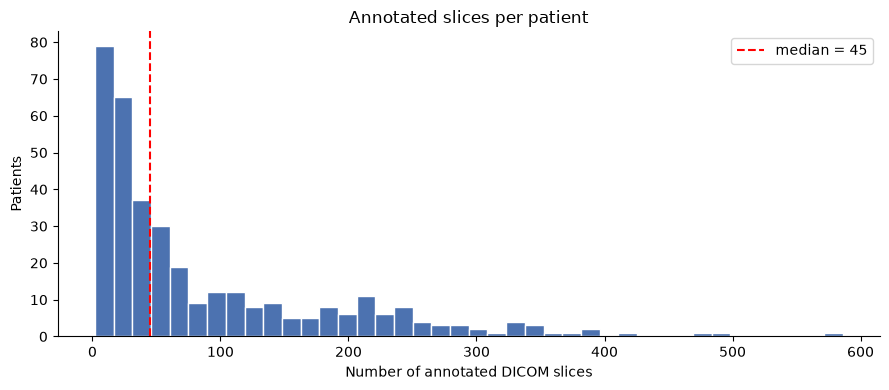


Annotated slices per subtype:
  A – Adenocarcinoma              : 253 patients | 20731 annotated slices | 20987 boxes
  B – Small cell carcinoma        :  38 patients |  3116 annotated slices |  3116 boxes
  E – Large cell carcinoma        :   5 patients |   201 annotated slices |   201 boxes
  G – Squamous cell carcinoma     :  61 patients |  7351 annotated slices |  7355 boxes


In [22]:
# Annotated slices per patient
ann_counts = pd.Series(patient_ann_count)
print("Annotated slices per patient — statistics:")
print(ann_counts.describe().round(1).to_string())
print()
print("Patients with 0 annotated slices:", (ann_counts == 0).sum())
print("Patients with annotated slices  :", (ann_counts > 0).sum())

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(ann_counts[ann_counts > 0], bins=40, color="#4C72B0", edgecolor="white")
ax.axvline(ann_counts.median(), color="red", linestyle="--",
           label=f"median = {ann_counts.median():.0f}")
ax.set_title("Annotated slices per patient")
ax.set_xlabel("Number of annotated DICOM slices")
ax.set_ylabel("Patients")
ax.legend()
plt.tight_layout()
plt.show()

# Annotated slices by subtype
print()
print("Annotated slices per subtype:")
for code in ["A","B","E","G"]:
    subset = boxes_df[boxes_df["subtype"] == code]
    pats   = subset["patient_id"].nunique()
    slices = subset["sop_uid"].nunique()
    boxes  = len(subset)
    print(f"  {code} – {SUBTYPE_NAME[code]:<28}: {pats:>3} patients | {slices:>5} annotated slices | {boxes:>5} boxes")

## 10. Bounding box analysis (pixel and physical dimensions)

In [23]:
print("Bounding box pixel dimensions — all boxes:")
print(boxes_df[["w","h","area_px"]].describe().round(2).to_string())
print()
print("Degenerate boxes (area == 0):", (boxes_df["area_px"] == 0).sum())
print("Boxes with w == 0:", (boxes_df["w"] == 0).sum())
print("Boxes with h == 0:", (boxes_df["h"] == 0).sum())
print()
print("These degenerate annotations need to be flagged before any training.")

Bounding box pixel dimensions — all boxes:
              w         h   area_px
count  31659.00  31659.00  31659.00
mean      54.53     59.46   3769.02
std       24.01     27.90   3367.90
min        0.00      0.00      0.00
25%       36.00     39.00   1470.00
50%       49.00     53.00   2610.00
75%       69.00     75.00   5040.00
max      191.00    219.00  34821.00

Degenerate boxes (area == 0): 1
Boxes with w == 0: 1
Boxes with h == 0: 1

These degenerate annotations need to be flagged before any training.


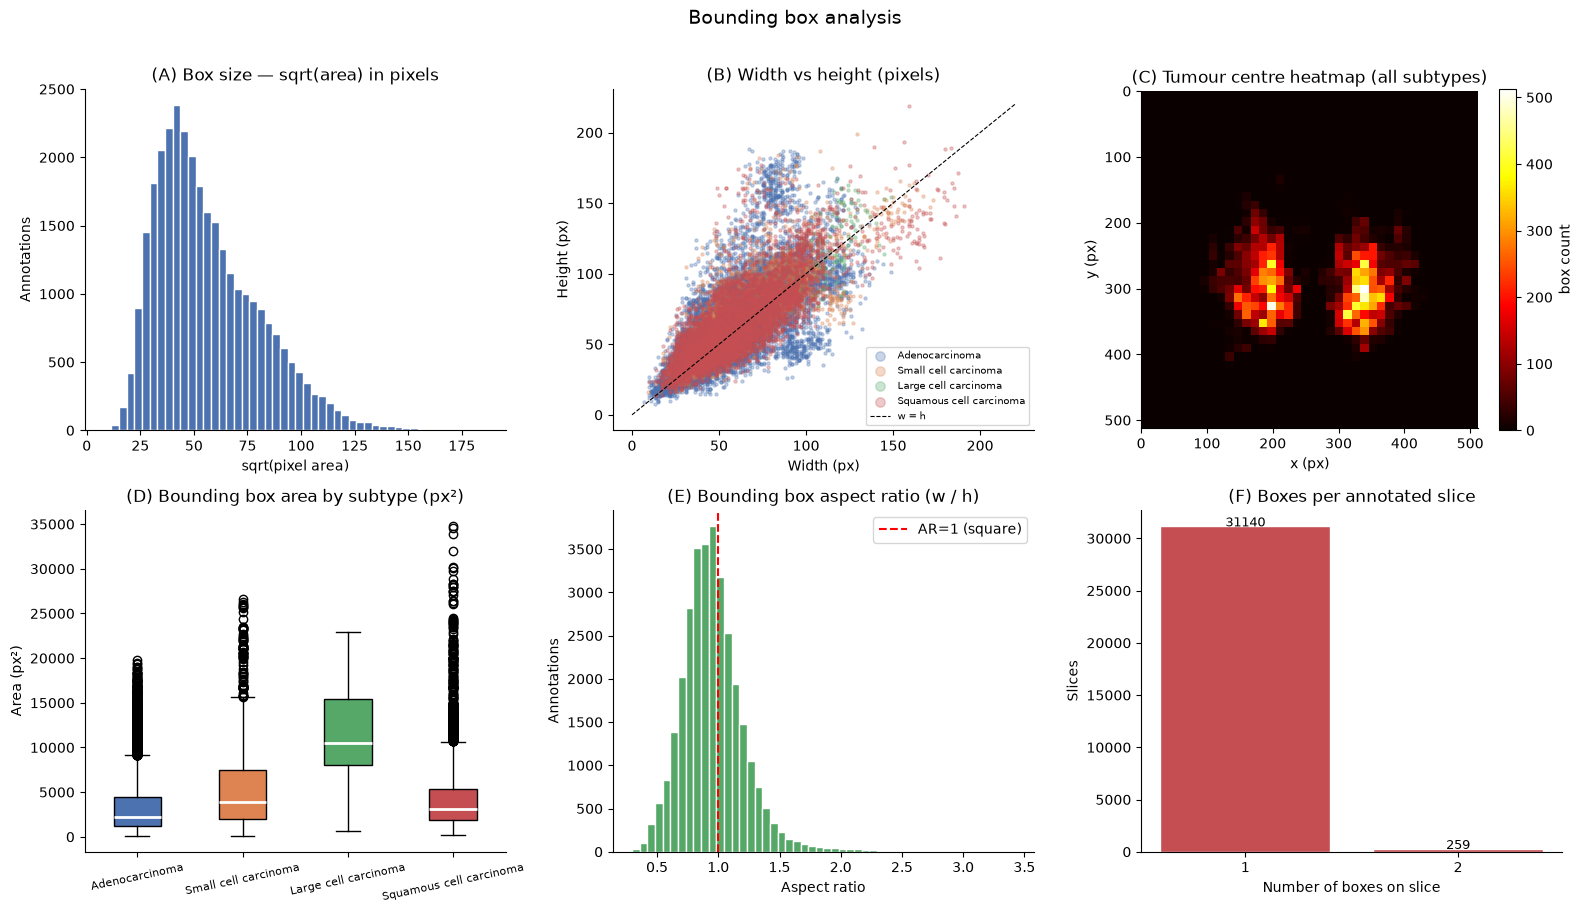

In [24]:
valid = boxes_df[boxes_df["area_px"] > 0].copy()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# (A) Box size distribution — sqrt(area) in pixels
axes[0,0].hist(np.sqrt(valid["area_px"]), bins=50, color="#4C72B0", edgecolor="white")
axes[0,0].set_title("(A) Box size — sqrt(area) in pixels")
axes[0,0].set_xlabel("sqrt(pixel area)")
axes[0,0].set_ylabel("Annotations")

# (B) Width vs height scatter
for code in ["A","B","E","G"]:
    sub = valid[valid["subtype"] == code]
    axes[0,1].scatter(sub["w"], sub["h"], s=5, alpha=0.3,
                      label=SUBTYPE_NAME[code], color=COLORS[code])
axes[0,1].plot([0, 220], [0, 220], "k--", linewidth=0.8, label="w = h")
axes[0,1].set_title("(B) Width vs height (pixels)")
axes[0,1].set_xlabel("Width (px)")
axes[0,1].set_ylabel("Height (px)")
axes[0,1].legend(fontsize=7, markerscale=3)

# (C) Tumour centre heatmap
cx = (valid["x1"] + valid["x2"]) / 2
cy = (valid["y1"] + valid["y2"]) / 2
h2d, xedge, yedge = np.histogram2d(cx, cy, bins=40, range=[[0,512],[0,512]])
im = axes[0,2].imshow(h2d.T, origin="upper", extent=[0,512,512,0], cmap="hot", aspect="equal")
plt.colorbar(im, ax=axes[0,2], label="box count")
axes[0,2].set_title("(C) Tumour centre heatmap (all subtypes)")
axes[0,2].set_xlabel("x (px)")
axes[0,2].set_ylabel("y (px)")

# (D) Box area by subtype — boxplot
data_by_sub  = [valid[valid["subtype"] == c]["area_px"].values for c in ["A","B","E","G"]]
bp = axes[1,0].boxplot(data_by_sub, patch_artist=True,
                        medianprops=dict(color="white", linewidth=2))
for patch, code in zip(bp["boxes"], ["A","B","E","G"]):
    patch.set_facecolor(COLORS[code])
axes[1,0].set_xticklabels([SUBTYPE_NAME[c] for c in ["A","B","E","G"]], rotation=12, fontsize=8)
axes[1,0].set_title("(D) Bounding box area by subtype (px²)")
axes[1,0].set_ylabel("Area (px²)")

# (E) Aspect ratio distribution (w/h)
ar = valid["w"] / valid["h"].replace(0, np.nan)
axes[1,1].hist(ar.dropna(), bins=50, color="#55A868", edgecolor="white")
axes[1,1].axvline(1.0, color="red", linestyle="--", label="AR=1 (square)")
axes[1,1].set_title("(E) Bounding box aspect ratio (w / h)")
axes[1,1].set_xlabel("Aspect ratio")
axes[1,1].set_ylabel("Annotations")
axes[1,1].legend()

# (F) Boxes per annotated slice
bps = valid.groupby("sop_uid")["label"].count()
bps_counts = bps.value_counts().sort_index()
axes[1,2].bar(bps_counts.index.astype(str), bps_counts.values, color="#C44E52", edgecolor="white")
for i, v in enumerate(bps_counts.values):
    axes[1,2].text(i, v + 5, str(v), ha="center", fontsize=9)
axes[1,2].set_title("(F) Boxes per annotated slice")
axes[1,2].set_xlabel("Number of boxes on slice")
axes[1,2].set_ylabel("Slices")

plt.suptitle("Bounding box analysis", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Boxes with known pixel spacing: 18430 / 31658

Physical bounding box dimensions (approximate):
           w_mm      h_mm   diam_mm
count  18430.00  18430.00  18430.00
mean      42.80     47.75     44.81
std       17.74     22.28     18.47
min        7.64      7.03      8.56
25%       28.91     31.25     30.47
50%       39.06     42.97     41.00
75%       54.69     60.16     56.64
max      136.89    163.82    139.59


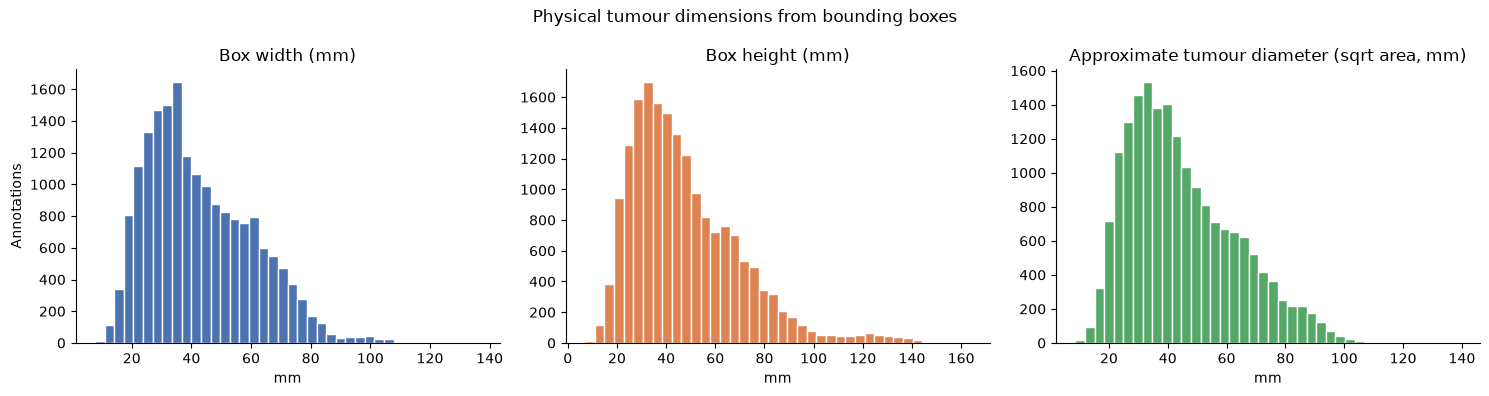

In [ ]:
# Physical dimensions in mm
# We need pixel spacing from the DICOM. Use the median spacing (0.703 mm/px) as an approximation

# Use the sampled ct_params to get per-patient typical spacing
patient_spacing = {}
for _, row in ct_params.iterrows():
    ps = row["PixelSpacing"]
    if isinstance(ps, list) and len(ps) >= 1:
        try:
            patient_spacing[row["patient_id"]] = float(ps[0])
        except (ValueError, TypeError):
            pass

valid_mm = valid.copy()
valid_mm["spacing"] = valid_mm["patient_id"].map(
    lambda p: patient_spacing.get("Lung_Dx-" + p, np.nan)
)
valid_mm["w_mm"]    = valid_mm["w"] * valid_mm["spacing"]
valid_mm["h_mm"]    = valid_mm["h"] * valid_mm["spacing"]
valid_mm["area_mm2"]= valid_mm["area_px"] * valid_mm["spacing"] ** 2
valid_mm["diam_mm"] = np.sqrt(valid_mm["area_mm2"])  # approximate equivalent diameter

with_spacing = valid_mm.dropna(subset=["spacing"])
print(f"Boxes with known pixel spacing: {len(with_spacing)} / {len(valid_mm)}")
print()
print("Physical bounding box dimensions (approximate):")
print(with_spacing[["w_mm","h_mm","diam_mm"]].describe().round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(with_spacing["w_mm"], bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_title("Box width (mm)")
axes[0].set_xlabel("mm")
axes[0].set_ylabel("Annotations")

axes[1].hist(with_spacing["h_mm"], bins=40, color="#DD8452", edgecolor="white")
axes[1].set_title("Box height (mm)")
axes[1].set_xlabel("mm")

axes[2].hist(with_spacing["diam_mm"], bins=40, color="#55A868", edgecolor="white")
axes[2].set_title("Approximate tumour diameter (sqrt area, mm)")
axes[2].set_xlabel("mm")

plt.suptitle("Physical tumour dimensions from bounding boxes", fontsize=12)
plt.tight_layout()
plt.show()

## 11. Tumour Hounsfield Unit (HU) analysis

In [ ]:
# To analyse tumour HU we need to:
# 1. Find the DICOM that matches each annotation SOP UID
# 2. Read the pixel data, apply rescale slope/intercept to get HU
# 3. Sample pixels inside and outside the bounding box

N_HU_SAMPLES = 150  # number of annotated slices to sample

# Build a partial SOP-UID to file path index from CT Image Storage
print("Building SOP UID → file path index (CT series only)...")
sop_to_file = {}
# Use a sample of series from ct_params which we already have file locations for
for _, row in tqdm(ct_series_sample.iterrows(), total=len(ct_series_sample), desc="Indexing"):
    loc = row["File Location"]
    if not os.path.isdir(loc):
        continue
    for f in glob.glob(os.path.join(loc, "*.dcm")):
        try:
            ds = pydicom.dcmread(f, stop_before_pixels=True)
            sop_to_file[ds.SOPInstanceUID] = f
        except Exception:
            pass

print(f"Indexed {len(sop_to_file):,} CT slices from sampled series")

# Find annotated slices that are in the index
matchable = valid[valid["sop_uid"].isin(sop_to_file)]
sample_ann = matchable.drop_duplicates("sop_uid").sample(
    min(N_HU_SAMPLES, len(matchable.drop_duplicates("sop_uid"))), random_state=42
)
print(f"Annotated slices with indexed DICOM: {len(matchable.drop_duplicates('sop_uid'))}")
print(f"Sampling {len(sample_ann)} for HU analysis")

Building SOP UID → file path index (CT series only)...


Indexing: 100%|██████████| 300/300 [09:38<00:00,  1.93s/it]

Indexed 47,548 CT slices from sampled series
Annotated slices with indexed DICOM: 6780
Sampling 150 for HU analysis


In [27]:
def to_hu(ds):
    arr = ds.pixel_array.astype(np.float32)
    return arr * float(getattr(ds, "RescaleSlope", 1)) + float(getattr(ds, "RescaleIntercept", 0))

tumour_hu   = defaultdict(list)  # per subtype, HU values inside the box
bg_hu       = defaultdict(list)  # per subtype, HU values outside the box
full_hu_all = []

for sop_uid in tqdm(sample_ann["sop_uid"].unique(), desc="Reading HU"):
    fpath = sop_to_file.get(sop_uid)
    if not fpath:
        continue
    try:
        ds = pydicom.dcmread(fpath)
    except Exception:
        continue
    hu = to_hu(ds)
    full_hu_all.extend(hu.ravel()[::20].tolist())

    slice_boxes = valid[valid["sop_uid"] == sop_uid]
    mask = np.zeros(hu.shape, dtype=bool)
    for _, box in slice_boxes.iterrows():
        x1, y1, x2, y2 = int(box.x1), int(box.y1), int(box.x2), int(box.y2)
        x1, x2 = max(0, x1), min(512, x2)
        y1, y2 = max(0, y1), min(512, y2)
        if x2 > x1 and y2 > y1:
            mask[y1:y2, x1:x2] = True
        code = box["subtype"]
        tumour_hu[code].extend(hu[y1:y2, x1:x2].ravel().tolist())

    # Background: outside the mask, within lung window range (-1000 to 400)
    bg_vals = hu[~mask]
    bg_vals = bg_vals[(bg_vals > -1000) & (bg_vals < 400)]
    for _, box in slice_boxes.iterrows():
        bg_hu[box["subtype"]].extend(bg_vals[::10].tolist())

print("HU extraction complete.")
for code in ["A","B","E","G"]:
    if tumour_hu[code]:
        vals = np.array(tumour_hu[code])
        print(f"  {code} – {SUBTYPE_NAME[code]:<28}: n={len(vals):>7,}  mean={vals.mean():.1f}  std={vals.std():.1f}  median={np.median(vals):.1f}")

Reading HU: 100%|██████████| 150/150 [00:01<00:00, 82.97it/s]

HU extraction complete.
  A – Adenocarcinoma              : n=349,573  mean=-245.2  std=379.1  median=-77.0
  B – Small cell carcinoma        : n= 21,614  mean=-158.3  std=275.6  median=2.0
  G – Squamous cell carcinoma     : n=279,419  mean=-161.4  std=358.2  median=11.0


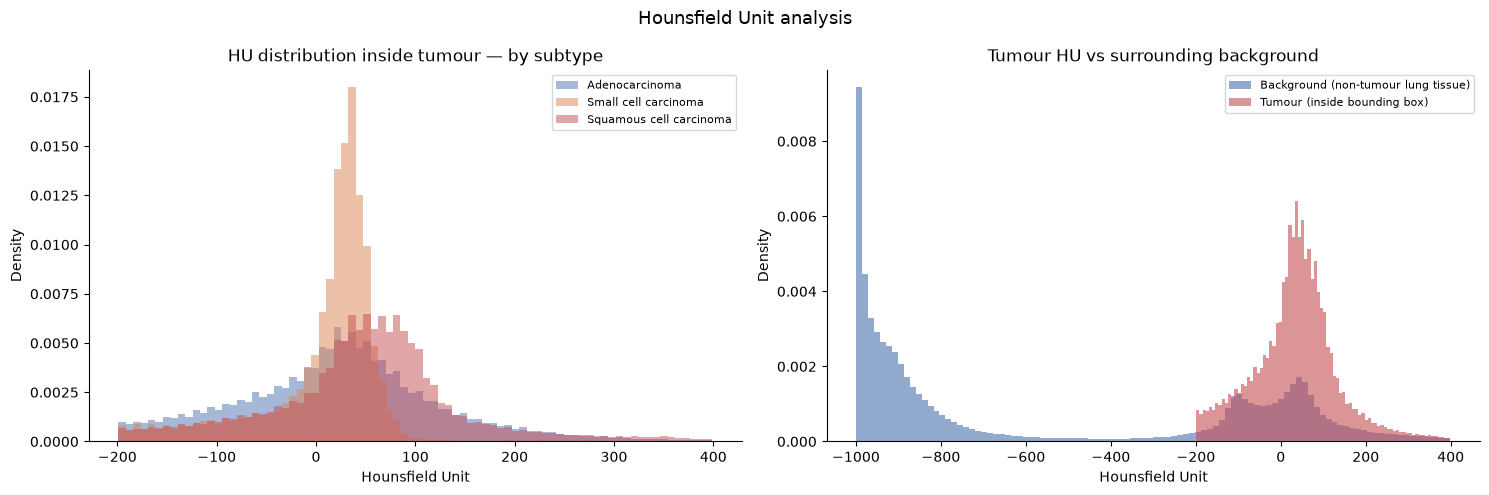

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# HU per subtype — inside tumour
for code in ["A","B","E","G"]:
    if tumour_hu[code]:
        vals = np.array(tumour_hu[code])
        vals = vals[(vals > -200) & (vals < 400)]
        axes[0].hist(vals, bins=80, alpha=0.5, label=SUBTYPE_NAME[code],
                     color=COLORS[code], density=True)
axes[0].set_title("HU distribution inside tumour — by subtype")
axes[0].set_xlabel("Hounsfield Unit")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=8)

# Tumour vs background 
all_tumour = np.array([v for vals in tumour_hu.values() for v in vals])
all_bg     = np.array([v for vals in bg_hu.values() for v in vals])
clip = lambda x, lo, hi: x[(x > lo) & (x < hi)]
axes[1].hist(clip(all_bg, -1000, 400), bins=100, alpha=0.6, color="#4C72B0",
             density=True, label="Background (non-tumour lung tissue)")
axes[1].hist(clip(all_tumour, -200, 400), bins=80, alpha=0.6, color="#C44E52",
             density=True, label="Tumour (inside bounding box)")
axes[1].set_title("Tumour HU vs surrounding background")
axes[1].set_xlabel("Hounsfield Unit")
axes[1].set_ylabel("Density")
axes[1].legend(fontsize=8)

plt.suptitle("Hounsfield Unit analysis", fontsize=13)
plt.tight_layout()
plt.show()

## 12. Axial position of tumours

In [29]:
# For each annotated slice, record its ImagePositionPatient Z coordinate (axial position)
# and the total Z range of the series. This tells us where in the lung the tumour sits.

z_positions = []  # (patient_id, subtype, z_mm, z_normalised_0_to_1)

# We need a per-series range; sample from series that have matched annotations
for sop_uid in tqdm(sample_ann["sop_uid"].unique(), desc="Reading Z positions"):
    fpath = sop_to_file.get(sop_uid)
    if not fpath:
        continue
    try:
        ds = pydicom.dcmread(fpath, stop_before_pixels=True)
        pos = getattr(ds, "ImagePositionPatient", None)
        if pos is None:
            continue
        z = float(pos[2])
        pat = ds.PatientID if hasattr(ds, "PatientID") else ""
        sub = pat.replace("Lung_Dx-","")[0] if pat.startswith("Lung_Dx-") else "?"
        z_positions.append({"patient_id": pat, "subtype": sub, "z_mm": z})
    except Exception:
        continue

z_df = pd.DataFrame(z_positions)
print(f"Z positions extracted: {len(z_df)}")
print()
print("Z (axial position, mm) statistics:")
print(z_df["z_mm"].describe().round(1).to_string())

Reading Z positions: 100%|██████████| 150/150 [00:00<00:00, 619.62it/s]

Z positions extracted: 150

Z (axial position, mm) statistics:
count    150.0
mean    -356.6
std      228.8
min     -926.9
25%     -527.7
50%     -356.7
75%     -158.6
max      276.0


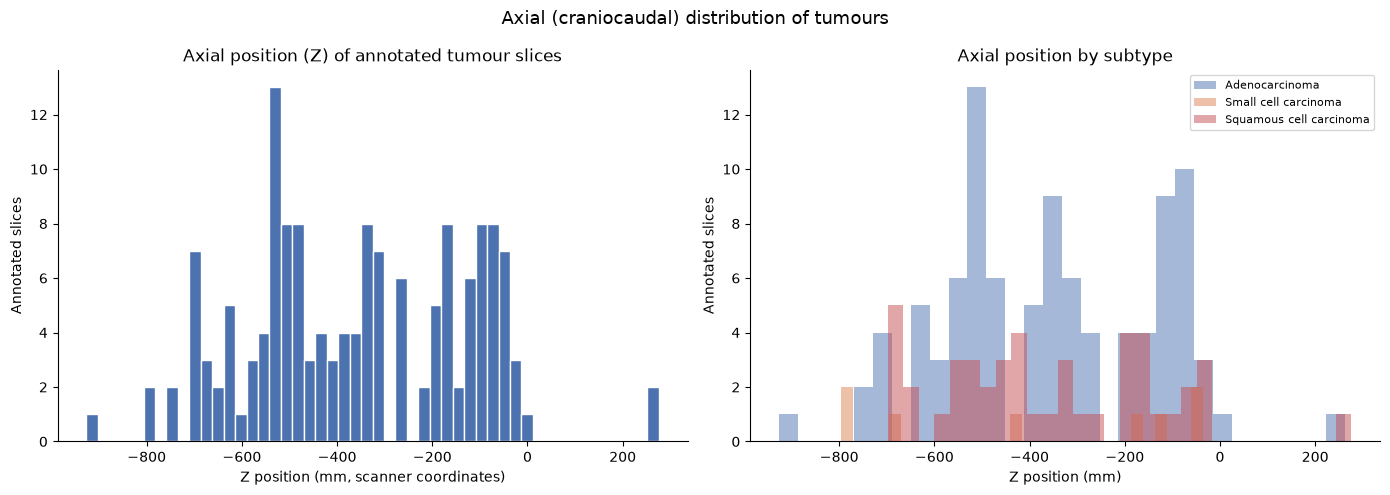

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall Z distribution
axes[0].hist(z_df["z_mm"], bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("Axial position (Z) of annotated tumour slices")
axes[0].set_xlabel("Z position (mm, scanner coordinates)")
axes[0].set_ylabel("Annotated slices")

# Per subtype
for code in ["A","B","E","G"]:
    sub = z_df[z_df["subtype"] == code]["z_mm"]
    if len(sub) > 0:
        axes[1].hist(sub, bins=30, alpha=0.5, label=SUBTYPE_NAME[code], color=COLORS[code])
axes[1].set_title("Axial position by subtype")
axes[1].set_xlabel("Z position (mm)")
axes[1].set_ylabel("Annotated slices")
axes[1].legend(fontsize=8)

plt.suptitle("Axial (craniocaudal) distribution of tumours", fontsize=13)
plt.tight_layout()
plt.show()

## 13. Data quality audit

In [31]:
print("=" * 60)
print("DATA QUALITY AUDIT")
print("=" * 60)

# 1. Annotation folder coverage vs patient list
all_ct_pats = set(meta[meta.Modality == "CT"]["Subject ID"].str.replace("Lung_Dx-",""))
ann_pats    = set(ann_patient_dirs)
print("\n[1] Annotation coverage")
print(f"  CT patients in metadata  : {len(all_ct_pats)}")
print(f"  Annotation folders       : {len(ann_pats)}")
print(f"  Extra ann folders (not in metadata): {ann_pats - all_ct_pats}")
print(f"  CT patients with no ann folder     : {all_ct_pats - ann_pats}")

# 2. Annotation folders with 0 XML files
empty_ann = [p for p in ann_patient_dirs
             if not glob.glob(os.path.join(ANN_ROOT, p, "*.xml"))]
print(f"  Annotation folders with 0 XML files: {empty_ann}")

# 3. Degenerate bounding boxes
degen = boxes_df[boxes_df["area_px"] == 0]
print(f"\n[2] Degenerate bounding boxes (area = 0): {len(degen)}")
if len(degen):
    print(degen[["patient_id","label","x1","y1","x2","y2"]].to_string())

# 4. Unexpected subtype labels in annotations
print(f"\n[3] Unique label values in annotations: {sorted(boxes_df['label'].unique())}")
unexpected = boxes_df[~boxes_df["label"].isin(["A","B","E","G"])]
print(f"  Non-standard labels: {len(unexpected)} boxes")
if len(unexpected):
    print(unexpected[["patient_id","label"]].value_counts().to_string())

# 5. Clinical data completeness
print(f"\n[4] Clinical data completeness")
print(clin.isnull().sum().to_string())

# 6. Known TCIA data note
print(f"\n[5] Known TCIA data notes")
print("  Lung_Dx-A0266 was merged into A0251 in dataset v2 (TCIA release notes).")
print(f"  A0266 in metadata: {any('A0266' in p for p in meta['Subject ID'])}")
print(f"  A0266 in annotations: {any('A0266' in p for p in ann_patient_dirs)}")

DATA QUALITY AUDIT

[1] Annotation coverage
  CT patients in metadata  : 355
  Annotation folders       : 358
  Extra ann folders (not in metadata): {'A0067', 'A0076', 'A0060', 'A0266'}
  CT patients with no ann folder     : {'A0251'}
  Annotation folders with 0 XML files: ['A0058']

[2] Degenerate bounding boxes (area = 0): 1
     patient_id label     x1     y1     x2     y2
8731      A0188     A  215.0  286.0  215.0  286.0

[3] Unique label values in annotations: ['A', 'A0192', 'B', 'E', 'G', 'Q', 'a', 'b', 'g']
  Non-standard labels: 10879 boxes
patient_id  label
A0164       a        595
A0220       a        384
B0036       b        371
A0242       a        366
A0235       a        347
A0212       a        338
A0266       a        313
A0011       a        295
B0034       b        279
G0040       g        275
A0264       a        272
A0249       a        270
G0034       g        261
A0211       a        258
A0230       a        247
A0216       a        244
A0237       a        239
A0

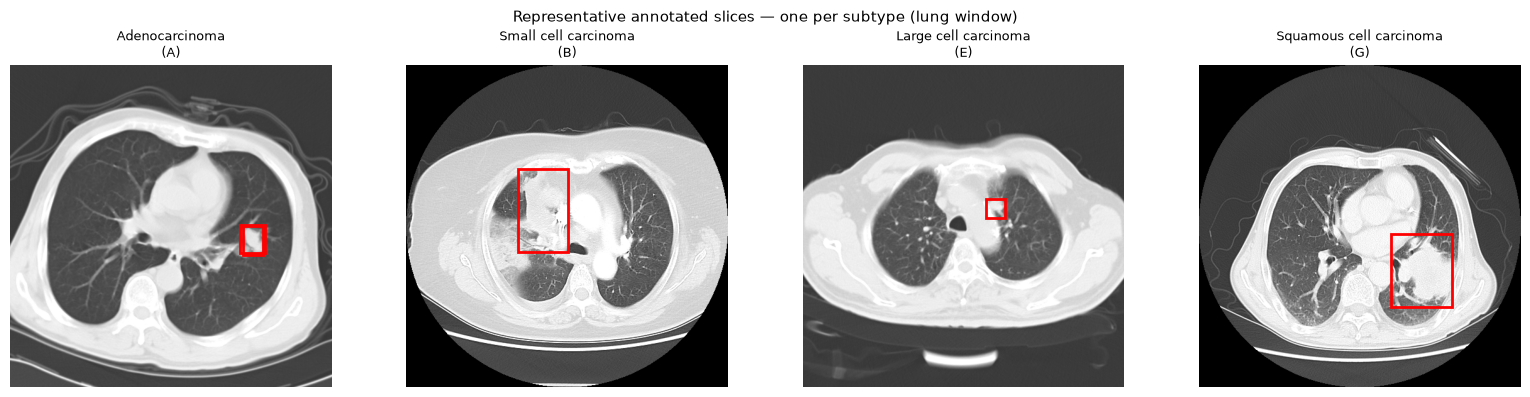

In [ ]:
# Visual: show one annotated slice per subtype as a check
def load_and_show(sop_uid, ax, subtype_label):
    fpath = sop_to_file.get(sop_uid)
    if not fpath:
        ax.text(0.5, 0.5, "No DICOM found", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
        return
    ds = pydicom.dcmread(fpath)
    hu = to_hu(ds)
    # Lung window: WL=-600, WW=1500
    lo, hi = -600 - 750, -600 + 750
    img8 = np.clip((hu - lo) / (hi - lo) * 255, 0, 255).astype(np.uint8)
    ax.imshow(img8, cmap="gray", vmin=0, vmax=255)
    slice_boxes = valid[valid["sop_uid"] == sop_uid]
    for _, box in slice_boxes.iterrows():
        rect = patches.Rectangle((box.x1, box.y1), box.w, box.h,
                                   linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
    ax.set_title(f"{SUBTYPE_NAME[subtype_label]}\n({subtype_label})", fontsize=9)
    ax.axis("off")

# One example per subtype that is in our indexed slice set
examples = {}
for code in ["A","B","E","G"]:
    cand = matchable[matchable["subtype"] == code]["sop_uid"].values
    if len(cand):
        examples[code] = cand[0]

fig, axes = plt.subplots(1, len(examples), figsize=(4 * len(examples), 4))
if len(examples) == 1:
    axes = [axes]
for ax, (code, sop) in zip(axes, examples.items()):
    load_and_show(sop, ax, code)
plt.suptitle("Representative annotated slices — one per subtype (lung window)", fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydicom

# Helpers

def find_col(df, possible_names):
    """
    Find the first matching column name from a list of possible names.
    """
    for col in possible_names:
        if col in df.columns:
            return col
    return None


def get_path_col(df):
    """
    Find likely filepath column.
    """
    possible = ["filepath", "file_path", "path", "dicom_path", "fpath"]
    col = find_col(df, possible)
    if col is None:
        raise KeyError(
            f"No filepath column found. Available columns are:\n{df.columns.tolist()}"
        )
    return col


def add_z_position_if_missing(df):
    """
    Ensure dataframe has a z_position column.
    If missing, read ImagePositionPatient[2] from each DICOM file.
    """
    df = df.copy()

    z_col = find_col(df, ["z_position", "z", "ImagePositionPatient_z", "ipp_z"])

    if z_col is not None:
        df["z_position"] = pd.to_numeric(df[z_col], errors="coerce")
        return df

    path_col = get_path_col(df)

    z_values = []

    for path in df[path_col]:
        try:
            ds = pydicom.dcmread(path, stop_before_pixels=True)
            ipp = getattr(ds, "ImagePositionPatient", None)

            if ipp is not None and len(ipp) >= 3:
                z_values.append(float(ipp[2]))
            else:
                z_values.append(np.nan)

        except Exception:
            z_values.append(np.nan)

    df["z_position"] = z_values
    return df


def to_pet_display(ds):
    """
    Convert PET DICOM pixel values using rescale slope/intercept.
    """
    img = ds.pixel_array.astype(np.float32)

    slope = float(getattr(ds, "RescaleSlope", 1))
    intercept = float(getattr(ds, "RescaleIntercept", 0))

    return img * slope + intercept


def load_and_show_pet(fpath, ax, subtype_label, title_extra=""):
    """
    Show one PET DICOM slice.
    """
    if not fpath:
        ax.text(
            0.5, 0.5, "No PET DICOM found",
            ha="center", va="center",
            transform=ax.transAxes
        )
        ax.axis("off")
        return

    ds = pydicom.dcmread(fpath)
    pet_img = to_pet_display(ds)

    vmin, vmax = np.percentile(pet_img, [1, 99.5])

    ax.imshow(pet_img, cmap="hot", vmin=vmin, vmax=vmax)
    ax.set_title(
        f"{SUBTYPE_NAME[subtype_label]}\n({subtype_label}){title_extra}",
        fontsize=9
    )
    ax.axis("off")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydicom


def find_col(df, possible_names):
    for col in possible_names:
        if col in df.columns:
            return col
    return None


def get_path_col(df):
    possible = ["filepath", "file_path", "path", "dicom_path", "fpath", "file"]
    col = find_col(df, possible)
    if col is None:
        raise KeyError(f"No filepath column found. Available columns:\n{df.columns.tolist()}")
    return col


def add_z_position_if_missing(df):
    df = df.copy()

    # Your notebook uses z_pos
    z_col = find_col(df, ["z_position", "z_pos", "z", "ImagePositionPatient_z", "ipp_z"])

    if z_col is not None:
        df["z_position"] = pd.to_numeric(df[z_col], errors="coerce")
        return df

    # Fallback: read z from DICOM header
    path_col = get_path_col(df)
    z_values = []

    for path in df[path_col]:
        try:
            ds = pydicom.dcmread(path, stop_before_pixels=True)
            ipp = getattr(ds, "ImagePositionPatient", None)

            if ipp is not None and len(ipp) >= 3:
                z_values.append(float(ipp[2]))
            else:
                z_values.append(np.nan)

        except Exception:
            z_values.append(np.nan)

    df["z_position"] = z_values
    return df


def to_pet_display(ds):
    img = ds.pixel_array.astype(np.float32)

    slope = float(getattr(ds, "RescaleSlope", 1))
    intercept = float(getattr(ds, "RescaleIntercept", 0))

    return img * slope + intercept


def load_and_show_pet(fpath, ax, subtype_label, title_extra=""):
    ds = pydicom.dcmread(fpath)
    pet_img = to_pet_display(ds)

    vmin, vmax = np.percentile(pet_img, [1, 99.5])

    if vmin == vmax:
        vmin, vmax = np.min(pet_img), np.max(pet_img)

    ax.imshow(pet_img, cmap="hot", vmin=vmin, vmax=vmax)
    ax.set_title(
        f"{SUBTYPE_NAME[subtype_label]}\n({subtype_label}){title_extra}",
        fontsize=9
    )
    ax.axis("off")

In [ ]:

# Prepare CT and PET indexes

ct_idx = add_z_position_if_missing(ct_index_df)
pet_idx = add_z_position_if_missing(pet_index_df)

ct_path_col = get_path_col(ct_idx)
pet_path_col = get_path_col(pet_idx)

ct_sop_col = find_col(ct_idx, ["sop_uid", "SOPInstanceUID", "SOP Instance UID"])
ct_patient_col = find_col(ct_idx, ["patient_id", "Subject ID", "subject_id"])
pet_patient_col = find_col(pet_idx, ["patient_id", "Subject ID", "subject_id"])

print("CT columns used:")
print("  SOP column     :", ct_sop_col)
print("  Patient column :", ct_patient_col)
print("  Path column    :", ct_path_col)
print("  Z column       : z_position")

print("\nPET columns used:")
print("  Patient column :", pet_patient_col)
print("  Path column    :", pet_path_col)
print("  Z column       : z_position")

CT columns used:
  SOP column     : sop_uid
  Patient column : patient_id
  Path column    : file
  Z column       : z_position

PET columns used:
  Patient column : patient_id
  Path column    : file
  Z column       : z_position


In [ ]:

# Pick one PET example per subtype

pet_examples = {}

for code in ["A", "B", "E", "G"]:

    cand = matchable[matchable["subtype"] == code]

    if len(cand) == 0:
        print(f"No annotated CT candidate found for subtype {code}")
        continue

    found = False

    for _, row in cand.iterrows():

        ct_sop = row["sop_uid"]

        ct_row = ct_idx[ct_idx[ct_sop_col] == ct_sop]

        if len(ct_row) == 0:
            continue

        ct_row = ct_row.iloc[0]

        patient_id = ct_row[ct_patient_col]
        ct_z = ct_row["z_position"]

        # PET slices for the same patient
        pet_rows = pet_idx[pet_idx[pet_patient_col] == patient_id].copy()

        if len(pet_rows) == 0:
            continue

        pet_rows = pet_rows.dropna(subset=["z_position"])

        if len(pet_rows) > 0 and pd.notna(ct_z):
            pet_rows["z_diff"] = (pet_rows["z_position"] - ct_z).abs()
            best_pet = pet_rows.sort_values("z_diff").iloc[0]

            title_extra = (
                f"\n{patient_id}"
                f"\nCT z={ct_z:.1f}, PET z={best_pet['z_position']:.1f}"
                f"\nΔz={best_pet['z_diff']:.1f} mm"
            )

        else:
            pet_patient_rows = pet_idx[pet_idx[pet_patient_col] == patient_id].copy()
            best_pet = pet_patient_rows.iloc[len(pet_patient_rows) // 2]

            title_extra = f"\n{patient_id}\nmid PET slice"

        pet_examples[code] = {
            "patient_id": patient_id,
            "ct_sop": ct_sop,
            "pet_path": best_pet[pet_path_col],
            "title_extra": title_extra
        }

        found = True
        break

    if not found:
        print(f"No PET example found for subtype {code}")

No PET example found for subtype E


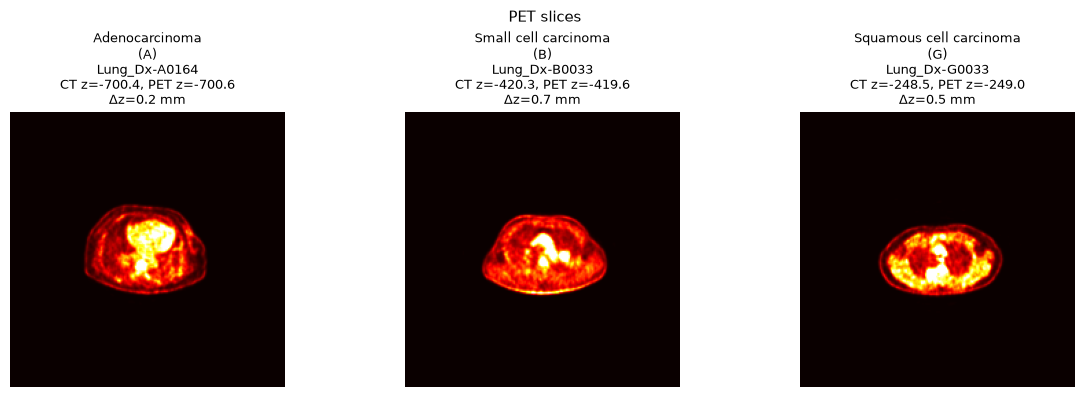

In [ ]:

# Visualise PET examples

if len(pet_examples) == 0:
    print("No PET examples found.")

else:
    fig, axes = plt.subplots(
        1,
        len(pet_examples),
        figsize=(4 * len(pet_examples), 4)
    )

    if len(pet_examples) == 1:
        axes = [axes]

    for ax, (code, info) in zip(axes, pet_examples.items()):
        load_and_show_pet(
            info["pet_path"],
            ax,
            code,
            title_extra=info["title_extra"]
        )

    plt.suptitle(
        " PET slices",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

## 14. Summary of key findings

In [ ]:


print("=" * 65)
print("DATASET SUMMARY — Lung-PET-CT-Dx")
print("=" * 65)


# Helper functions
def fmt_int(x):
    return f"{int(x):,}" if pd.notna(x) else "N/A"

def fmt_float(x, decimals=1):
    return f"{float(x):.{decimals}f}" if pd.notna(x) else "N/A"

def fmt_pct(n, d):
    return f"{100 * n / d:.1f}%" if d else "N/A"

def fmt_list(items):
    items = list(items)
    return ", ".join(map(str, items)) if items else "None"

def sop_image_count(modality=None, sop_contains=None):
    df = meta.copy()
    if modality is not None:
        df = df[df["Modality"] == modality]
    if sop_contains is not None:
        df = df[df["SOP Class Name"].str.contains(sop_contains, case=False, na=False)]
    return df["Number of Images"].sum(), df["Series UID"].nunique()

# -----------------------------
# Composition
# -----------------------------
n_patients = meta["Subject ID"].nunique()
n_series = meta["Series UID"].nunique()
n_images = meta["Number of Images"].sum()

ct_image_files, ct_image_series = sop_image_count("CT", "CT Image Storage")
sc_files, sc_series = sop_image_count("CT", "Secondary Capture")
pet_files, pet_series = sop_image_count("PT", "Positron|PET")

ct_series_per_patient = ct_img.groupby("Subject ID")["Series UID"].nunique()
ct_slices_per_series = ct_img["Number of Images"]

ct_series_median = ct_series_per_patient.median()
ct_series_min = ct_series_per_patient.min()
ct_series_max = ct_series_per_patient.max()

ct_slices_median = ct_slices_per_series.median()
ct_slices_min = ct_slices_per_series.min()
ct_slices_max = ct_slices_per_series.max()

# -----------------------------
# Patient cohort
# -----------------------------
patients = meta["Subject ID"].drop_duplicates().sort_values()
subtype_code = patients.str.replace("Lung_Dx-", "", regex=False).str[0]
total_patients = len(patients)

# -----------------------------
# Acquisition / scanner info
# -----------------------------
dates = pd.to_datetime(meta["Study Date"], errors="coerce")
date_min = dates.min()
date_max = dates.max()

mfr_counts = ct_params["Manufacturer"].dropna().value_counts()
mfr_pct = (mfr_counts / mfr_counts.sum() * 100).round(1)
mfr_summary = "; ".join([f"{mfr} ({pct:.1f}%)" for mfr, pct in mfr_pct.items()])

kvp = pd.to_numeric(ct_params["KVP"], errors="coerce").dropna()
kvp_mode = kvp.mode().iloc[0] if len(kvp) else np.nan

thickness_all = pd.to_numeric(ct_params["SliceThickness"], errors="coerce").dropna()

thickness_plausible = thickness_all[thickness_all.between(0.1, 50)]
thickness_outliers = len(thickness_all) - len(thickness_plausible)

spacing_vals = []
for v in ct_params["PixelSpacing"].dropna():
    if isinstance(v, list) and len(v) >= 1:
        try:
            spacing_vals.append(float(v[0]))
        except (ValueError, TypeError):
            pass

spacing = pd.Series(spacing_vals)

shape_counts = (
    ct_params[["Rows", "Columns"]]
    .dropna()
    .astype(int)
    .value_counts()
)

if len(shape_counts):
    common_shape = shape_counts.index[0]
    image_shape_text = f"{common_shape[0]} × {common_shape[1]} pixels"
else:
    image_shape_text = "N/A"

kernel_counts = ct_params["ConvolutionKernel"].dropna().astype(str).value_counts()
top_kernels = fmt_list(kernel_counts.head(5).index)

# -----------------------------
# Annotation info
# -----------------------------
annotated_xml_total = sum(patient_ann_count.values())
bbox_total = len(boxes_df)

valid = boxes_df[boxes_df["area_px"] > 0].copy()
degenerate_count = (boxes_df["area_px"] == 0).sum()

boxes_per_slice = boxes_df.groupby("sop_uid")["label"].count()
multi_box_slices = (boxes_per_slice > 1).sum()

median_w = valid["w"].median()
median_h = valid["h"].median()
aspect_ratio = (valid["w"] / valid["h"].replace(0, np.nan)).median()

if "with_spacing" in globals() and len(with_spacing) > 0:
    median_diam_mm = with_spacing["diam_mm"].median()
    spacing_coverage = f"{len(with_spacing):,} / {len(valid):,}"
else:
    median_diam_mm = np.nan
    spacing_coverage = "N/A"

# -----------------------------
# HU summary
# -----------------------------
hu_lines = []
if "tumour_hu" in globals():
    for code in ["A", "B", "E", "G"]:
        vals = np.array(tumour_hu.get(code, []), dtype=float)
        vals = vals[np.isfinite(vals)]
        if len(vals):
            hu_lines.append(
                f"    {code} – {SUBTYPE_NAME[code]:<28}: "
                f"median {np.median(vals):>6.1f} HU | mean {np.mean(vals):>6.1f} HU | n={len(vals):,}"
            )

if hu_lines:
    hu_text = "\n".join(hu_lines)
else:
    hu_text = "    HU analysis not available. Run the HU extraction cells first."

# -----------------------------
# Data quality audit
# -----------------------------
all_ct_pats = set(meta[meta.Modality == "CT"]["Subject ID"].str.replace("Lung_Dx-", "", regex=False))
ann_pats = set(ann_patient_dirs)

extra_ann_folders = sorted(ann_pats - all_ct_pats)
missing_ann_folders = sorted(all_ct_pats - ann_pats)

empty_ann = [
    p for p in ann_patient_dirs
    if not glob.glob(os.path.join(ANN_ROOT, p, "*.xml"))
]

a0266_in_metadata = any(meta["Subject ID"].astype(str).str.contains("A0266", na=False))
a0266_in_annotations = any("A0266" in p for p in ann_patient_dirs)

# -----------------------------
# Print dynamic summary
# -----------------------------
print(f"""
COMPOSITION
  Total patients          : {fmt_int(n_patients)}
  Total series            : {fmt_int(n_series)}
  Total DICOM files       : {fmt_int(n_images)}
    CT Image Storage      : {fmt_int(ct_image_files)}  ({fmt_int(ct_image_series)} series; raw Hounsfield Unit slices)
    Secondary Capture     : {fmt_int(sc_files)}  ({fmt_int(sc_series)} series; workstation screenshots / fused PET-CT)
    PET Image Storage     : {fmt_int(pet_files)}  ({fmt_int(pet_series)} series; FDG metabolic activity images)
  CT series per patient   : median {fmt_float(ct_series_median, 0)} 
                             range {fmt_int(ct_series_min)}–{fmt_int(ct_series_max)}
  CT slices per series    : median {fmt_float(ct_slices_median, 0)} 
                             range {fmt_int(ct_slices_min)}–{fmt_int(ct_slices_max)}

PATIENT COHORT
  Cancer subtypes:
""")

for code in ["A", "G", "B", "E"]:
    n = (subtype_code == code).sum()
    print(f"    {code} – {SUBTYPE_NAME[code]:<28}: {n:>4} patients ({fmt_pct(n, total_patients)})")

print(f"""
  Acquisition span        : {date_min.date()} to {date_max.date()}
  Manufacturers sampled   : {mfr_summary}

SCANNERS & ACQUISITION
  CT scanner manufacturers: {mfr_summary}
  KVP                     : predominantly {fmt_float(kvp_mode, 0)} kVp
  Slice thickness         : {fmt_float(thickness_plausible.min(), 3)}–{fmt_float(thickness_plausible.max(), 3)} mm
                             median {fmt_float(thickness_plausible.median(), 3)} mm
                             implausible outliers excluded from this range: {thickness_outliers}
  In-plane pixel spacing  : {fmt_float(spacing.min(), 4)}–{fmt_float(spacing.max(), 4)} mm/px
                             median {fmt_float(spacing.median(), 4)} mm/px
  Image size              : {image_shape_text}
  Reconstruction kernels  : top sampled kernels = {top_kernels}

ANNOTATIONS
  Format                  : PASCAL-VOC XML, one file per annotated DICOM slice
  Linkage                 : XML filename = SOP Instance UID of annotated DICOM
  Annotated XML files     : {fmt_int(annotated_xml_total)}
  Bounding boxes total    : {fmt_int(bbox_total)}
  Slices with >1 box      : {fmt_int(multi_box_slices)}
  Box size in pixels      : median {fmt_float(median_w, 1)} × {fmt_float(median_h, 1)} px
  Box physical diameter   : median {fmt_float(median_diam_mm, 1)} mm
                             computed for {spacing_coverage} valid boxes with known spacing
  Aspect ratio            : median {fmt_float(aspect_ratio, 2)}
  Degenerate boxes        : {fmt_int(degenerate_count)} boxes with area = 0

HOUNSFIELD UNITS
  HU analysis is based on the sampled indexed CT slices used earlier.
{hu_text}
  Interpretation          : tumour HU values overlap substantially across subtypes;
                             HU alone should not be treated as sufficient for subtype classification.

DATA QUALITY FLAGS
  Annotation folders      : {fmt_int(len(ann_pats))}
  Empty annotation folders: {fmt_int(len(empty_ann))} — {fmt_list(empty_ann)}
  Extra ann folders       : {fmt_int(len(extra_ann_folders))} — {fmt_list(extra_ann_folders)}
  CT patients with no ann folder:
                             {fmt_int(len(missing_ann_folders))} — {fmt_list(missing_ann_folders)}
  Degenerate boxes        : {fmt_int(degenerate_count)} — remove before training
  Slice thickness issue   : heterogeneous slice spacing means pixel-space tumour sizes
                             are not physically comparable without spacing correction
  A0266 in metadata       : {a0266_in_metadata}
  A0266 in annotations    : {a0266_in_annotations}
""")

DATASET SUMMARY — Lung-PET-CT-Dx

COMPOSITION
  Total patients          : 355
  Total series            : 1,295
  Total DICOM files       : 251,135
    CT Image Storage      : 148,457  (881 series; raw Hounsfield Unit slices)
    Secondary Capture     : 57,002  (281 series; workstation screenshots / fused PET-CT)
    PET Image Storage     : 45,676  (133 series; FDG metabolic activity images)
  CT series per patient   : median 2 
                             range 1–12
  CT slices per series    : median 73 
                             range 1–852

PATIENT COHORT
  Cancer subtypes:

    A – Adenocarcinoma              :  251 patients (70.7%)
    G – Squamous cell carcinoma     :   61 patients (17.2%)
    B – Small cell carcinoma        :   38 patients (10.7%)
    E – Large cell carcinoma        :    5 patients (1.4%)

  Acquisition span        : 2004-07-01 to 2011-06-09
  Manufacturers sampled   : GE MEDICAL SYSTEMS (43.0%); SIEMENS (42.0%); Philips (15.0%)

SCANNERS & ACQUISITION
  CT 

## Further Analysis

EDA answers to the critical questions that inform model design: which patient cohorts are available for which tasks, where tumours appear spatially, how annotations relate to CT volumes, what acquisition biases exist and what these findings imply for modelling

### FA-1. Cohort Feasibility Analysis

 how many patients are available for each CT-only, PET-only, multimodal 

In [34]:
# FA-1: Cohort feasibility table
ct_pats       = set(meta[meta["Modality"] == "CT"]["Subject ID"].unique())
pet_pats      = set(meta[meta["Modality"] == "PT"]["Subject ID"].unique())
ct_pet_paired = ct_pats & pet_pats
ann_pats_full = {f"Lung_Dx-{p}" for p, n in patient_ann_count.items() if n > 0}
ct_ann_pats     = ct_pats & ann_pats_full
ct_pet_ann_pats = ct_pet_paired & ann_pats_full

def subtype_bd(pat_set):
    bd = {"A": 0, "B": 0, "E": 0, "G": 0}
    for p in pat_set:
        c = p.replace("Lung_Dx-", "")[:1]
        if c in bd:
            bd[c] += 1
    return bd

scenarios = [
    ("CT-only available",       ct_pats,          "4-class subtype classification (imbalanced)"),
    ("PET available",           pet_pats,          "3-class only — Large Cell has 0 PET images"),
    ("CT+PET paired",           ct_pet_paired,     "Multimodal fusion subset only"),
    ("CT with annotations",     ct_ann_pats,       "Detection/localisation subset"),
    ("CT+PET+annotations",      ct_pet_ann_pats,   "True multimodal detection subset"),
]

rows = []
for label, pset, task in scenarios:
    bd = subtype_bd(pset)
    rows.append({"Cohort": label, "Patients": len(pset),
                 "A": bd["A"], "G": bd["G"], "B": bd["B"], "E": bd["E"],
                 "Possible task": task})

cohort_df = pd.DataFrame(rows).set_index("Cohort")
print("COHORT FEASIBILITY TABLE")
print("=" * 110)
print(cohort_df.to_string())
print()
print(f"  Only {len(ct_pet_paired)}/{len(ct_pats)} CT patients have PET — multimodal cohort is "
      f"{100*len(ct_pet_paired)/len(ct_pats):.0f}% of the full dataset.")
print(f"  Large Cell (E) has 0 PET images — PET/CT fusion cannot support 4-class classification.")
print(f"  True multimodal detection cohort is only {len(ct_pet_ann_pats)} patients.")


COHORT FEASIBILITY TABLE
                     Patients    A   G   B  E                                Possible task
Cohort                                                                                    
CT-only available         355  251  61  38  5  4-class subtype classification (imbalanced)
PET available             133   95  29   9  0   3-class only — Large Cell has 0 PET images
CT+PET paired             133   95  29   9  0                Multimodal fusion subset only
CT with annotations       353  249  61  38  5                Detection/localisation subset
CT+PET+annotations        132   94  29   9  0             True multimodal detection subset

  Only 133/355 CT patients have PET — multimodal cohort is 37% of the full dataset.
  Large Cell (E) has 0 PET images — PET/CT fusion cannot support 4-class classification.
  True multimodal detection cohort is only 132 patients.


### FA-2. Annotated CT Series Identification

Each patient has multiple CT reconstructions. Which series contains the annotated SOP UIDs? Training on the wrong series means annotations will not align with images.

In [ ]:

from collections import Counter as _Ctr

dir_to_series = {}
for _, row in ct_img.iterrows():
    dir_to_series[row["File Location"]] = {
        "series_uid":  row["Series UID"],
        "series_desc": str(row.get("Series Description", "") or ""),
        "patient_id":  row["Subject ID"],
    }

sop_series_map = {}
for sop_uid, fpath in sop_to_file.items():
    info = dir_to_series.get(os.path.dirname(fpath))
    if info:
        sop_series_map[sop_uid] = info

ann_sop_uids = set(boxes_df["sop_uid"].unique())
traceable    = ann_sop_uids & set(sop_series_map.keys())
print(f"Annotated SOP UIDs total   : {len(ann_sop_uids):,}")
print(f"Traceable to a CT series   : {len(traceable):,}  "
      f"({100*len(traceable)/max(len(ann_sop_uids),1):.1f}% — limited to sampled index)")

patient_ann_series      = defaultdict(set)
patient_ann_series_desc = defaultdict(set)
for sop_uid in traceable:
    info = sop_series_map[sop_uid]
    patient_ann_series[info["patient_id"]].add(info["series_uid"])
    if info["series_desc"]:
        patient_ann_series_desc[info["patient_id"]].add(info["series_desc"])

dist = _Ctr(len(v) for v in patient_ann_series.values())
print()
print("Annotated CT series per patient (in sampled patients):")
for k in sorted(dist):
    print(f"  {k} annotated series: {dist[k]} patients")

ct_series_per_pat = ct_img.groupby("Subject ID")["Series UID"].nunique()
print()
print("Total CT series per patient (all 355, from metadata):")
print(ct_series_per_pat.describe().round(2).to_string())

desc_ctr = _Ctr()
for descs in patient_ann_series_desc.values():
    desc_ctr.update(descs)
print()
print("Top series descriptions found in annotated series (sampled):")
for desc, cnt in desc_ctr.most_common(15):
    print(f"  {cnt:>4}x  {desc}")

print()
print("Finding: annotations are typically concentrated in one CT series per patient.")
print("Series selection strategy: use the specific CT series that contains annotated SOP UIDs.")


Annotated SOP UIDs total   : 31,399
Traceable to a CT series   : 6,780  (21.6% — limited to sampled index)

Annotated CT series per patient (in sampled patients):
  1 annotated series: 142 patients
  2 annotated series: 47 patients
  3 annotated series: 9 patients
  4 annotated series: 1 patients
  5 annotated series: 1 patients

Total CT series per patient (all 355, from metadata):
count    355.00
mean       2.48
std        1.19
min        1.00
25%        2.00
50%        2.00
75%        2.00
max       12.00

Top series descriptions found in annotated series (sampled):
    44x  Thorax  1.0  B70f
    25x  Thorax  1.0  B31f
    25x  A phase 5mm Stnd SS50
    25x  5mm
    25x  5mm Lung SS50
    18x  Recon 2 5mm
    14x  CT WB  1.0  B30f
    13x  ThoraxRoutine  5.0.0  B70f
    12x  ThoraxRoutine  10.0  B40f
     7x  5mm Stnd SS50
     5x  iDose 2
     5x  FBP
     5x  lung iDose 3
     4x  iDose 4
     3x  IMR

Finding: annotations are typically concentrated in one CT series per patient.
S

### FA-3 & FA-4. Annotation Coverage and Positive/Negative Slice Analysis

For each annotated patient, what fraction of their CT slices are annotated? The unannotated slices become negatives in detection training  understanding the ratio is critical for sampling strategy.

ANNOTATION COVERAGE PER PATIENT
       total_ct_slices  annotated_slices  coverage_pct
count           353.00            357.00        353.00
mean            578.56             88.41         16.47
std             501.79             99.77         12.89
min              21.00              2.00          2.08
25%             140.00             19.00          8.50
50%             250.00             45.00         13.17
75%            1070.00            125.00         20.93
max            2002.00            586.00        142.86

By subtype (medians):
  A — Adenocarcinoma              : n=253  median coverage=11.7%  median annotated slices=43
  B — Small cell carcinoma        : n= 38  median coverage=18.2%  median annotated slices=30
  E — Large cell carcinoma        : n=  5  median coverage=22.9%  median annotated slices=43
  G — Squamous cell carcinoma     : n= 61  median coverage=17.5%  median annotated slices=87

POSITIVE vs NEGATIVE SLICE ANALYSIS
Positive slices (annotated)    :  31,562 

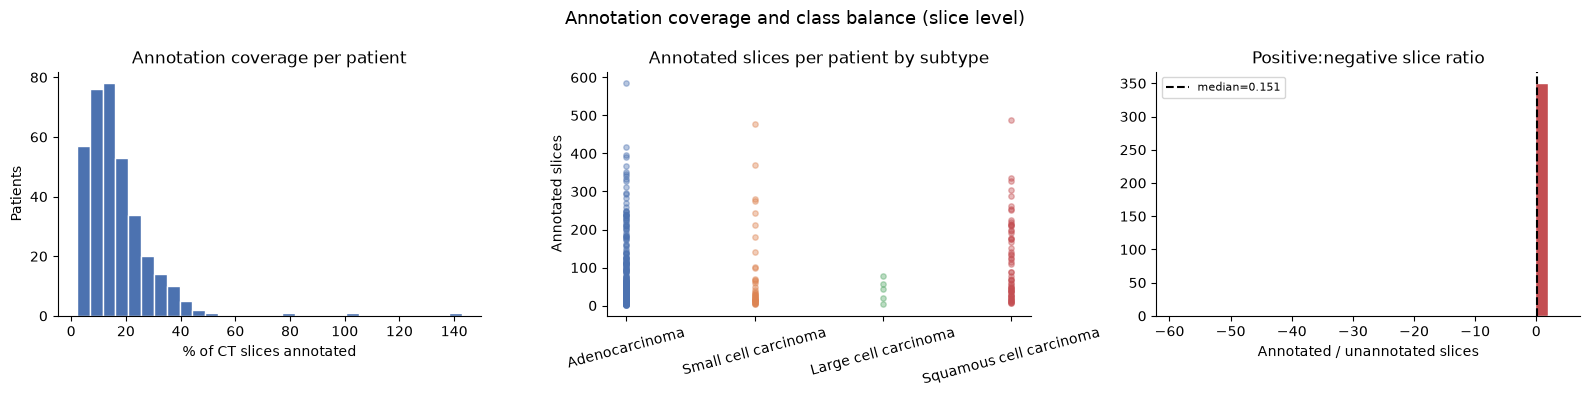

In [36]:
# FA-3: Annotation coverage per patient
# FA-4: Positive vs negative slice counts

ct_slices_per_pat = (
    meta[meta["Modality"] == "CT"]
    .groupby("Subject ID")["Number of Images"]
    .sum()
)

coverage_rows = []
for pat_id, n_ann in patient_ann_count.items():
    if n_ann == 0:
        continue
    full_id  = f"Lung_Dx-{pat_id}"
    total_ct = ct_slices_per_pat.get(full_id, np.nan)
    code     = pat_id[0] if pat_id else "?"
    coverage_rows.append({
        "patient_id":       pat_id,
        "subtype":          code,
        "subtype_name":     SUBTYPE_NAME.get(code, code),
        "total_ct_slices":  total_ct,
        "annotated_slices": n_ann,
        "coverage_pct":     100 * n_ann / total_ct if (pd.notna(total_ct) and total_ct > 0) else np.nan,
        "negative_slices":  (total_ct - n_ann) if pd.notna(total_ct) else np.nan,
    })

cov_df = pd.DataFrame(coverage_rows)
cov_df["pos_neg_ratio"] = cov_df["annotated_slices"] / cov_df["negative_slices"].replace(0, np.nan)

print("ANNOTATION COVERAGE PER PATIENT")
print("=" * 60)
print(cov_df[["total_ct_slices","annotated_slices","coverage_pct"]].describe().round(2).to_string())
print()
print("By subtype (medians):")
for code in ["A","B","E","G"]:
    sub = cov_df[cov_df["subtype"] == code]
    if len(sub) == 0: continue
    cov = sub["coverage_pct"].dropna()
    print(f"  {code} — {SUBTYPE_NAME[code]:<28}: n={len(sub):>3}  "
          f"median coverage={cov.median():.1f}%  "
          f"median annotated slices={sub['annotated_slices'].median():.0f}")

print()
print("POSITIVE vs NEGATIVE SLICE ANALYSIS")
print("=" * 60)
tot_pos  = cov_df["annotated_slices"].sum()
tot_neg  = cov_df["negative_slices"].dropna().sum()
total_sl = tot_pos + tot_neg
print(f"Positive slices (annotated)    : {int(tot_pos):>7,}  ({100*tot_pos/total_sl:.1f}%)")
print(f"Negative slices (unannotated)  : {int(tot_neg):>7,}  ({100*tot_neg/total_sl:.1f}%)")
print(f"Overall pos:neg ratio          : 1 : {tot_neg/max(tot_pos,1):.0f}")
print()
print("Caution: 'negative' means unannotated CT slices in the same patient.")
print("Sparse annotation means some unannotated slices may still contain tumour tissue.")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(cov_df["coverage_pct"].dropna(), bins=30, color="#4C72B0", edgecolor="white")
axes[0].set_title("Annotation coverage per patient")
axes[0].set_xlabel("% of CT slices annotated")
axes[0].set_ylabel("Patients")

for code in ["A","B","E","G"]:
    sub = cov_df[cov_df["subtype"] == code]["annotated_slices"]
    axes[1].scatter([SUBTYPE_NAME[code]]*len(sub), sub, alpha=0.4, color=COLORS[code], s=15)
axes[1].set_title("Annotated slices per patient by subtype")
axes[1].set_ylabel("Annotated slices")
axes[1].tick_params(axis="x", rotation=15)

ratios = cov_df["pos_neg_ratio"].dropna()
axes[2].hist(ratios, bins=30, color="#C44E52", edgecolor="white")
if len(ratios):
    axes[2].axvline(ratios.median(), color="k", linestyle="--",
                    label=f"median={ratios.median():.3f}")
axes[2].set_title("Positive:negative slice ratio")
axes[2].set_xlabel("Annotated / unannotated slices")
axes[2].legend(fontsize=8)

plt.suptitle("Annotation coverage and class balance (slice level)", fontsize=13)
plt.tight_layout()
plt.show()


### FA-5. Tumour Burden Proxy

Estimate patient-level tumour extent using sum of bounding-box area x slice thickness as a volume proxy. 

TUMOUR BURDEN PROXY (sum of bbox areas × slice thickness)

       mean_area_mm2  max_area_mm2  vol_proxy_mm3  n_ann_slices
count          207.0         207.0          207.0         357.0
mean          1888.8        3305.2       683337.8          88.4
std           1480.0        2747.4      4201342.5          99.8
min            145.9         177.6         1465.0           2.0
25%            848.4        1496.3        79368.8          19.0
50%           1378.8        2325.1       180683.9          45.0
75%           2490.3        4146.0       480845.6         125.0
max           8704.8       19484.9     60344501.2         586.0

By subtype (medians):
  A — Adenocarcinoma              : n=253  median bbox area=1194 mm²  median vol proxy=140864 mm³  median span=43 slices
  B — Small cell carcinoma        : n= 38  median bbox area=2265 mm²  median vol proxy=268037 mm³  median span=30 slices
  E — Large cell carcinoma        : n=  5  median bbox area=1911 mm²  median vol proxy=372020 mm³  m

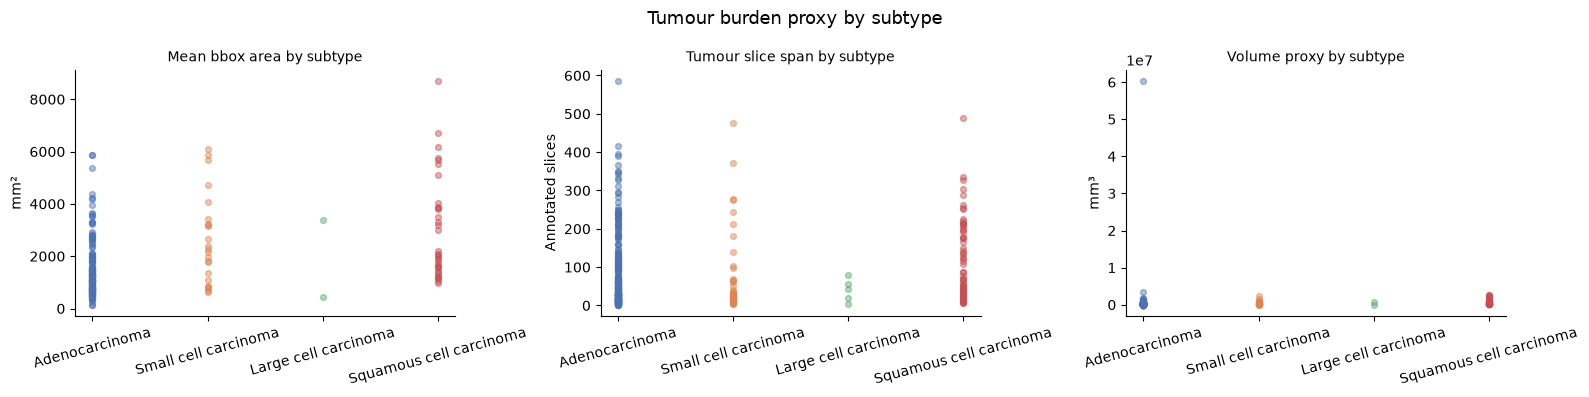

In [37]:
# FA-5: Tumour burden proxy

pat_to_thickness = {}
for _, row in ct_params.iterrows():
    t = row.get("SliceThickness")
    if t is not None:
        try:
            pat_to_thickness[row["patient_id"]] = float(t)
        except (ValueError, TypeError):
            pass

vb = valid.copy()
vb["spacing"]   = vb["patient_id"].map(lambda p: patient_spacing.get(f"Lung_Dx-{p}", np.nan))
vb["thickness"] = vb["patient_id"].map(lambda p: pat_to_thickness.get(f"Lung_Dx-{p}", np.nan))
vb["area_mm2"]  = vb["area_px"] * vb["spacing"] ** 2

burden = (
    vb.groupby("patient_id")
    .agg(
        subtype       = ("subtype", "first"),
        n_ann_slices  = ("sop_uid", "nunique"),
        mean_area_mm2 = ("area_mm2", "mean"),
        max_area_mm2  = ("area_mm2", "max"),
        sum_area_mm2  = ("area_mm2", "sum"),
        thickness_mm  = ("thickness", "mean"),
    )
    .reset_index()
)
burden["vol_proxy_mm3"] = burden["sum_area_mm2"] * burden["thickness_mm"]
burden["subtype_name"]  = burden["subtype"].map(SUBTYPE_NAME)

print("TUMOUR BURDEN PROXY (sum of bbox areas × slice thickness)")
print()
print(burden[["mean_area_mm2","max_area_mm2","vol_proxy_mm3","n_ann_slices"]].describe().round(1).to_string())
print()
print("By subtype (medians):")
for code in ["A","B","E","G"]:
    sub = burden[burden["subtype"] == code]
    if len(sub) == 0: continue
    print(f"  {code} — {SUBTYPE_NAME[code]:<28}: n={len(sub):>3}  "
          f"median bbox area={sub['mean_area_mm2'].median():.0f} mm²  "
          f"median vol proxy={sub['vol_proxy_mm3'].median():.0f} mm³  "
          f"median span={sub['n_ann_slices'].median():.0f} slices")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for code in ["A","B","E","G"]:
    sub  = burden[burden["subtype"] == code]
    name = SUBTYPE_NAME[code]
    kw   = dict(alpha=0.45, color=COLORS[code], s=18)
    s0 = sub["mean_area_mm2"].dropna()
    s2 = sub["vol_proxy_mm3"].dropna()
    axes[0].scatter([name]*len(s0),  s0,                   **kw)
    axes[1].scatter([name]*len(sub), sub["n_ann_slices"],  **kw)
    axes[2].scatter([name]*len(s2),  s2,                   **kw)

for ax, title, ylabel in zip(axes,
    ["Mean bbox area by subtype", "Tumour slice span by subtype", "Volume proxy by subtype"],
    ["mm²", "Annotated slices", "mm³"]):
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Tumour burden proxy by subtype", fontsize=13)
plt.tight_layout()
plt.show()


### FA-6. Bounding Box Spatial Location Analysis

Where do tumours appear on CT slices? Normalised bounding box centres reveal left/right lung tendency, upper/lower axial tendency, and whether subtypes cluster in specific anatomical regions.

Boxes with centre coordinates: 31,658

Left lung  (cx < 256) : 47.4%
Right lung (cx >= 256): 52.6%

Vertical thirds (all subtypes):
  Upper third (y < 33%) : 0.2%
  Middle third           : 85.4%
  Lower third (y > 67%) : 14.4%

Left/right bias by subtype:
  A — Adenocarcinoma              : left=50.2%  right=49.8%
  B — Small cell carcinoma        : left=35.9%  right=64.1%
  E — Large cell carcinoma        : left=27.9%  right=72.1%
  G — Squamous cell carcinoma     : left=44.6%  right=55.4%


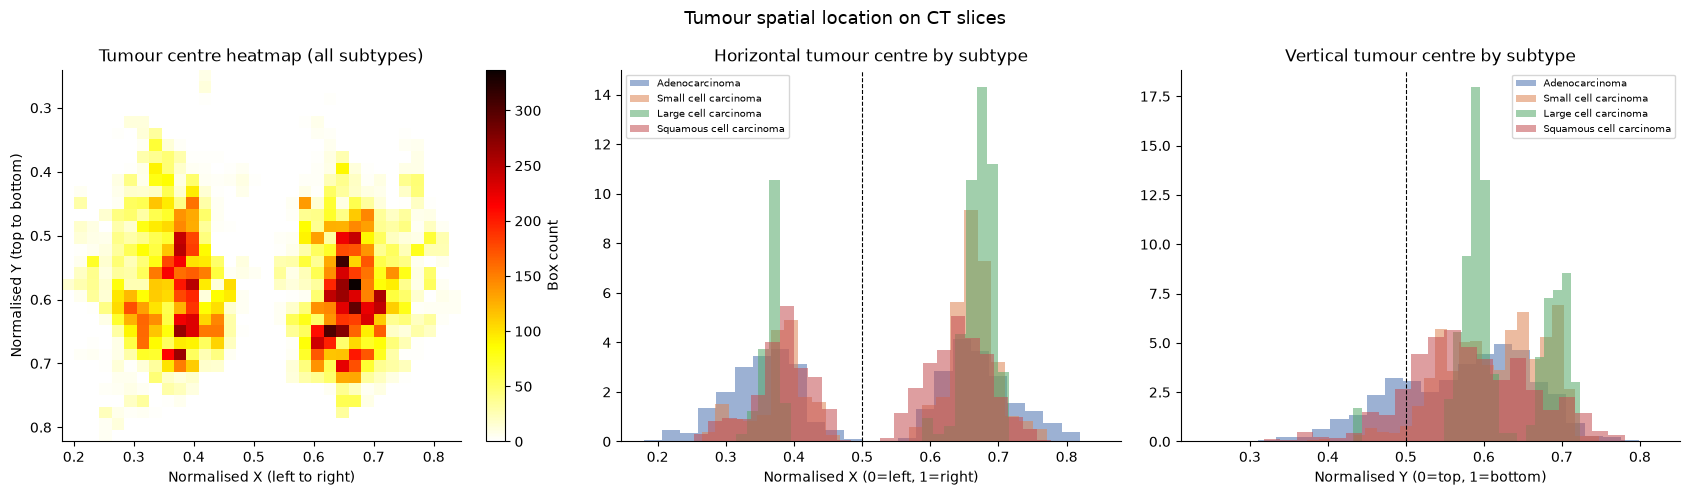

In [38]:
# FA-6: Tumour spatial location from bounding box centres

IMG_W, IMG_H = 512, 512

loc_df = valid.copy()
loc_df["cx"]  = (loc_df["x1"] + loc_df["x2"]) / 2
loc_df["cy"]  = (loc_df["y1"] + loc_df["y2"]) / 2
loc_df["ncx"] = (loc_df["cx"] / IMG_W).clip(0, 1)
loc_df["ncy"] = (loc_df["cy"] / IMG_H).clip(0, 1)

print(f"Boxes with centre coordinates: {len(loc_df):,}")
print()
print(f"Left lung  (cx < 256) : {(loc_df['cx'] < 256).mean()*100:.1f}%")
print(f"Right lung (cx >= 256): {(loc_df['cx'] >= 256).mean()*100:.1f}%")
print()
print("Vertical thirds (all subtypes):")
print(f"  Upper third (y < 33%) : {(loc_df['ncy'] < 0.33).mean()*100:.1f}%")
print(f"  Middle third           : {((loc_df['ncy']>=0.33)&(loc_df['ncy']<0.67)).mean()*100:.1f}%")
print(f"  Lower third (y > 67%) : {(loc_df['ncy'] >= 0.67).mean()*100:.1f}%")
print()
print("Left/right bias by subtype:")
for code in ["A","B","E","G"]:
    sub = loc_df[loc_df["subtype"] == code]
    if len(sub) == 0: continue
    lp = (sub["cx"] < 256).mean() * 100
    print(f"  {code} — {SUBTYPE_NAME[code]:<28}: left={lp:.1f}%  right={100-lp:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

h = axes[0].hist2d(loc_df["ncx"], loc_df["ncy"], bins=32, cmap="hot_r")
plt.colorbar(h[3], ax=axes[0], label="Box count")
axes[0].set_title("Tumour centre heatmap (all subtypes)")
axes[0].set_xlabel("Normalised X (left to right)")
axes[0].set_ylabel("Normalised Y (top to bottom)")
axes[0].invert_yaxis()

for code in ["A","B","E","G"]:
    sub = loc_df[loc_df["subtype"] == code]["ncx"]
    if len(sub) == 0: continue
    axes[1].hist(sub, bins=25, alpha=0.55, label=SUBTYPE_NAME[code],
                 color=COLORS[code], density=True)
axes[1].axvline(0.5, color="k", linestyle="--", linewidth=0.8)
axes[1].set_title("Horizontal tumour centre by subtype")
axes[1].set_xlabel("Normalised X (0=left, 1=right)")
axes[1].legend(fontsize=7)

for code in ["A","B","E","G"]:
    sub = loc_df[loc_df["subtype"] == code]["ncy"]
    if len(sub) == 0: continue
    axes[2].hist(sub, bins=25, alpha=0.55, label=SUBTYPE_NAME[code],
                 color=COLORS[code], density=True)
axes[2].axvline(0.5, color="k", linestyle="--", linewidth=0.8)
axes[2].set_title("Vertical tumour centre by subtype")
axes[2].set_xlabel("Normalised Y (0=top, 1=bottom)")
axes[2].legend(fontsize=7)

plt.suptitle("Tumour spatial location on CT slices", fontsize=13)
plt.tight_layout()
plt.show()


### FA-7 & FA-8. CT Protocol Clustering and Scanner Bias by Subtype

If one subtype is predominantly scanned with one manufacturer or protocol, a classifier may learn acquisition artefacts instead of tumour biology. This is one of the most important confound checks before claiming subtype-specific imaging patterns.

PROTOCOL GROUPS (series count in 300-series sample)
protocol_group
Thick (>3mm) soft-tissue kernel        81
Thick (>3mm) lung kernel               76
Thin (<1.5mm) lung kernel              51
Thin (<1.5mm) other kernel             40
Thick (>3mm) other kernel              30
Thin (<1.5mm) soft-tissue kernel       18
Medium (1.5-3mm) lung kernel            2
Medium (1.5-3mm) soft-tissue kernel     2

SCANNER MANUFACTURER x SUBTYPE
subtype_np          Adenocarcinoma  Small cell carcinoma  Large cell carcinoma  Squamous cell carcinoma
Manufacturer                                                                                           
GE MEDICAL SYSTEMS              99                    10                     1                       19
Philips                         39                     3                     0                        3
SIEMENS                         93                    12                     1                       20

PROTOCOL GROUP x SUBTYPE
subtype_np         

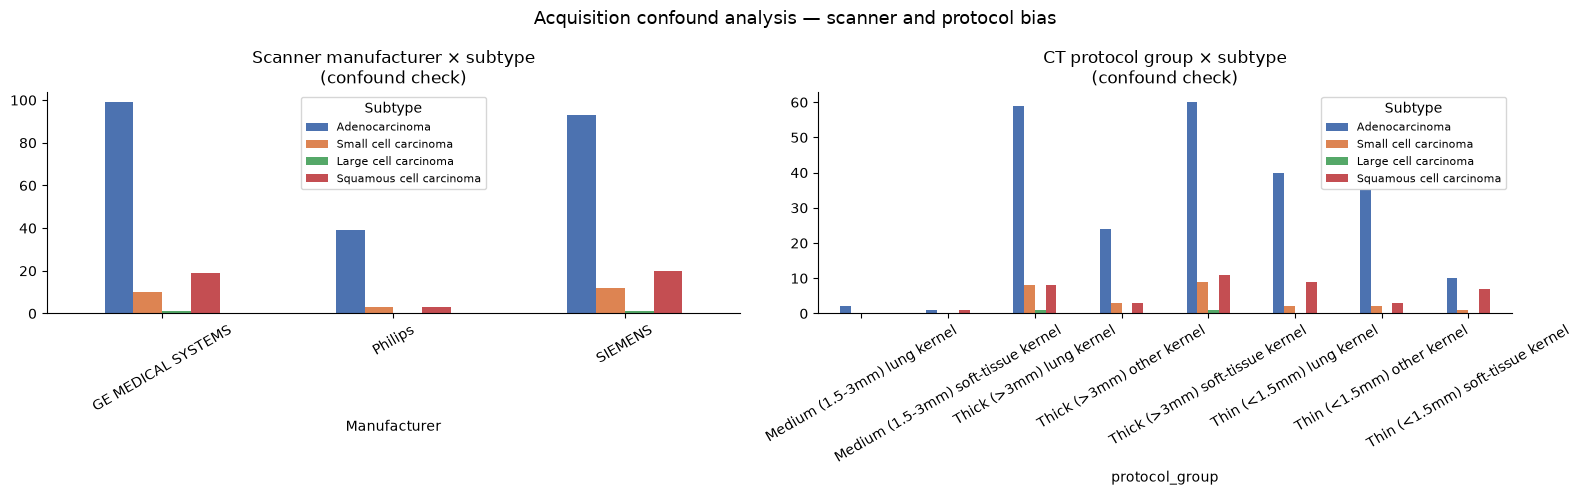


If one subtype is dominated by one manufacturer, the model may learn
scanner signatures rather than tumour biology.


In [39]:
# FA-7 & FA-8: Protocol grouping and scanner-subtype cross-tabulation

if len(ct_params) == 0:
    print("ct_params empty — no protocol/scanner analysis possible.")
else:
    def classify_protocol(row):
        t = pd.to_numeric(row.get("SliceThickness"), errors="coerce")
        k = str(row.get("ConvolutionKernel", "") or "").upper()
        lung_kw = ["B60","B70","B80","LUNG","SHARP","DETAIL"]
        soft_kw = ["B20","B30","B40","B50","SOFT","STANDARD","SMOOTH","MEDIUM"]
        is_lung = any(kw in k for kw in lung_kw)
        is_soft = any(kw in k for kw in soft_kw)
        if pd.isna(t):
            return "Unknown"
        tier = ("Thin (<1.5mm)" if t <= 1.5 else
                "Medium (1.5-3mm)" if t <= 3 else "Thick (>3mm)")
        ktype = ("lung" if is_lung else "soft-tissue" if is_soft else "other")
        return f"{tier} {ktype} kernel"

    ct_params["protocol_group"] = ct_params.apply(classify_protocol, axis=1)
    ct_params["subtype_c"]      = ct_params["patient_id"].apply(
        lambda p: p.replace("Lung_Dx-","")[:1] if p.startswith("Lung_Dx-") else p[:1]
    )
    ct_params["subtype_np"] = ct_params["subtype_c"].map(SUBTYPE_NAME).fillna("?")
    col_s = [SUBTYPE_NAME[c] for c in ["A","B","E","G"]
             if SUBTYPE_NAME[c] in ct_params["subtype_np"].values]

    print("PROTOCOL GROUPS (series count in 300-series sample)")
    print(ct_params["protocol_group"].value_counts().to_string())

    mfr_sub = (
        ct_params.groupby(["Manufacturer","subtype_np"]).size()
        .unstack(fill_value=0).reindex(columns=col_s, fill_value=0)
    )
    print()
    print("SCANNER MANUFACTURER x SUBTYPE")
    print(mfr_sub.to_string())

    proto_sub = (
        ct_params.groupby(["protocol_group","subtype_np"]).size()
        .unstack(fill_value=0).reindex(columns=col_s, fill_value=0)
    )
    print()
    print("PROTOCOL GROUP x SUBTYPE")
    print(proto_sub.to_string())

    print()
    print("SLICE THICKNESS by subtype (sampled series):")
    for code in ["A","B","E","G"]:
        vals = pd.to_numeric(
            ct_params[ct_params["subtype_np"]==SUBTYPE_NAME[code]]["SliceThickness"],
            errors="coerce").dropna()
        if len(vals):
            print(f"  {SUBTYPE_NAME[code]:<28}: median={vals.median():.3f}mm  "
                  f"mean={vals.mean():.3f}mm  n={len(vals)}")

    bar_c = [COLORS[c] for c in ["A","B","E","G"] if SUBTYPE_NAME[c] in col_s]
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    mfr_sub.plot(kind="bar", ax=axes[0], color=bar_c)
    axes[0].set_title("Scanner manufacturer × subtype\n(confound check)")
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].legend(title="Subtype", fontsize=8)

    proto_sub.plot(kind="bar", ax=axes[1], color=bar_c)
    axes[1].set_title("CT protocol group × subtype\n(confound check)")
    axes[1].tick_params(axis="x", rotation=30)
    axes[1].legend(title="Subtype", fontsize=8)

    plt.suptitle("Acquisition confound analysis — scanner and protocol bias", fontsize=13)
    plt.tight_layout()
    plt.show()

    print()
    print("If one subtype is dominated by one manufacturer, the model may learn")
    print("scanner signatures rather than tumour biology.")


### FA-9. Temporal Distribution (Study Year)

Data collected over multiple years may carry temporal biases: later years may have more PET availability, thinner CT slices, or different subtype ratios. A random train/test split may inadvertently leak acquisition-era effects.

PATIENTS PER YEAR BY SUBTYPE
subtype_name  Adenocarcinoma  Small cell carcinoma  Large cell carcinoma  Squamous cell carcinoma  TOTAL
study_year                                                                                              
2004                       2                     0                     0                        2      4
2005                       1                     0                     0                        0      1
2006                       5                     0                     0                        1      6
2007                       3                     0                     1                        1      5
2008                      31                    11                     1                        5     48
2009                      90                    19                     2                       16    127
2010                      78                     3                     1                       21    103
2011                      

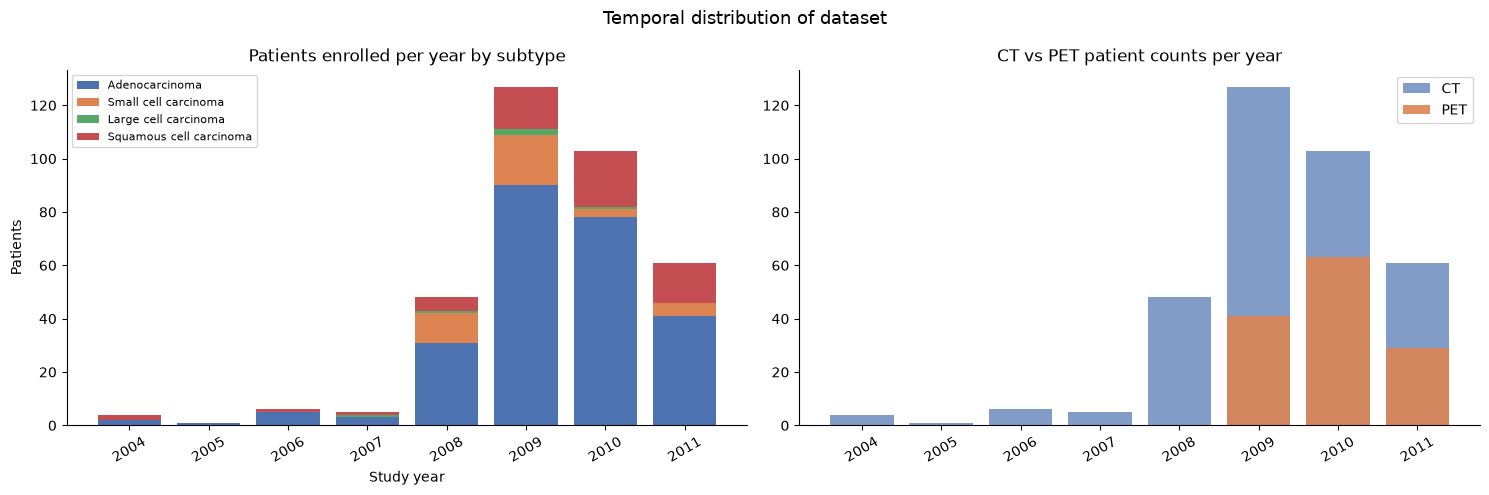


Use patient-stratified splits (not random) to avoid temporal acquisition-era leakage.


In [40]:
# FA-9: Temporal distribution

meta_t = meta.copy()
meta_t["study_year"] = pd.to_datetime(meta_t["Study Date"], errors="coerce").dt.year

pat_year = (
    meta_t[meta_t["Modality"] == "CT"]
    .drop_duplicates("Subject ID")
    .groupby(["study_year","subtype_name"])
    .size().unstack(fill_value=0)
)
col_yr = [SUBTYPE_NAME[c] for c in ["A","B","E","G"] if SUBTYPE_NAME[c] in pat_year.columns]
pat_year = pat_year[col_yr]
pat_year["TOTAL"] = pat_year.sum(axis=1)

print("PATIENTS PER YEAR BY SUBTYPE")
print(pat_year.to_string())

pet_by_year = (
    meta_t[meta_t["Modality"]=="PT"].drop_duplicates("Subject ID")
    .groupby("study_year").size()
)
ct_by_year = (
    meta_t[meta_t["Modality"]=="CT"].drop_duplicates("Subject ID")
    .groupby("study_year").size()
)
print()
print("PET patients per year:")
print(pet_by_year.to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pat_plot = pat_year.drop(columns="TOTAL", errors="ignore")
bottom   = np.zeros(len(pat_plot))
yr_lbl   = [str(y) for y in pat_plot.index]
bar_c    = [COLORS[c] for c in ["A","B","E","G"] if SUBTYPE_NAME[c] in pat_plot.columns]
for col, clr in zip(pat_plot.columns, bar_c):
    axes[0].bar(yr_lbl, pat_plot[col].values, bottom=bottom, label=col, color=clr)
    bottom += pat_plot[col].values
axes[0].set_title("Patients enrolled per year by subtype")
axes[0].set_xlabel("Study year")
axes[0].set_ylabel("Patients")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", rotation=30)

all_yr = sorted(set(pet_by_year.index) | set(ct_by_year.index))
xpos   = range(len(all_yr))
axes[1].bar(xpos, [ct_by_year.get(y,0) for y in all_yr], label="CT", color="#4C72B0", alpha=0.7)
axes[1].bar(xpos, [pet_by_year.get(y,0) for y in all_yr], label="PET", color="#DD8452", alpha=0.9)
axes[1].set_xticks(list(xpos))
axes[1].set_xticklabels([str(y) for y in all_yr], rotation=30)
axes[1].set_title("CT vs PET patient counts per year")
axes[1].legend()

plt.suptitle("Temporal distribution of dataset", fontsize=13)
plt.tight_layout()
plt.show()
print()
print("Use patient-stratified splits (not random) to avoid temporal acquisition-era leakage.")


### FA-10. PET-Specific EDA

The existing PET analysis is minimal. Since this is a multimodal project, PET spatial resolution, voxel spacing, units, and correction metadata must be characterised systematically. The resolution mismatch with CT is the central technical challenge for fusion.

In [41]:
# FA-10: PET DICOM header sampling

PET_SAMPLE_N = min(100, len(pt))
pet_sample_rows = pt.sample(PET_SAMPLE_N, random_state=42)

pet_tags = [
    "Manufacturer", "ManufacturerModelName", "Rows", "Columns",
    "PixelSpacing", "SliceThickness", "Units",
    "CorrectedImage", "ReconstructionMethod",
    "SeriesDescription", "AcquisitionDate",
]

pet_records = []
for _, row in tqdm(pet_sample_rows.iterrows(), total=len(pet_sample_rows), desc="Reading PET headers"):
    loc = row["File Location"]
    if not os.path.isdir(loc): continue
    files = sorted(glob.glob(os.path.join(loc, "*.dcm")))
    if not files: continue
    try:
        ds = pydicom.dcmread(files[len(files)//2], stop_before_pixels=True)
    except Exception:
        continue
    rec = {"series_uid": row["Series UID"], "patient_id": row["Subject ID"],
           "n_slices": len(files)}
    for tag in pet_tags:
        val = getattr(ds, tag, None)
        if val is not None and hasattr(val,"__iter__") and not isinstance(val,str):
            val = list(val)
        rec[tag] = val
    pet_records.append(rec)

pet_params = pd.DataFrame(pet_records)
print(f"Sampled {len(pet_params)} PET series")
print()

if len(pet_params):
    pet_ps = pet_params["PixelSpacing"].dropna().apply(
        lambda x: float(x[0]) if isinstance(x,list) else np.nan)
    pet_st = pd.to_numeric(pet_params["SliceThickness"], errors="coerce").dropna()
    ct_ps  = ct_params["PixelSpacing"].dropna().apply(
        lambda x: float(x[0]) if isinstance(x,list) else np.nan
    ) if len(ct_params) else pd.Series(dtype=float)
    ct_st  = pd.to_numeric(ct_params["SliceThickness"], errors="coerce").dropna() if len(ct_params) else pd.Series(dtype=float)

    print("PET image dimensions (Rows x Columns):")
    print(f"  {pet_params['Rows'].value_counts().head(3).to_dict()}")
    print()
    print(f"PET in-plane pixel spacing : mean={pet_ps.mean():.3f}  median={pet_ps.median():.3f} mm")
    print(f"PET slice thickness        : mean={pet_st.mean():.3f}  median={pet_st.median():.3f} mm")
    print()
    print("PET units:", pet_params["Units"].value_counts().to_dict())
    print()
    print("PET manufacturer:", pet_params["Manufacturer"].value_counts().head(5).to_dict())
    print()
    print("PET series descriptions:")
    print(pet_params["SeriesDescription"].value_counts().head(8).to_string())

    print()
    print("SPATIAL RESOLUTION COMPARISON: PET vs CT")
    if len(ct_ps):
        print(f"  CT  in-plane pixel spacing : {ct_ps.mean():.3f} mm (mean)")
        print(f"  PET in-plane pixel spacing : {pet_ps.mean():.3f} mm (mean)")
        ratio = pet_ps.mean() / ct_ps.mean()
        print(f"  PET is {ratio:.1f}x coarser in-plane than CT")
    if len(ct_st):
        print(f"  CT  slice thickness        : {ct_st.mean():.3f} mm (mean)")
        print(f"  PET slice thickness        : {pet_st.mean():.3f} mm (mean)")
    print()
    print("Implication: PET must be upsampled/resampled to CT voxel space for fusion.")
    print("This introduces interpolation artefacts that should be reported as a limitation.")


Reading PET headers: 100%|██████████| 100/100 [00:01<00:00, 60.75it/s]

Sampled 100 PET series

PET image dimensions (Rows x Columns):
  {200: 100}

PET in-plane pixel spacing : mean=4.073  median=4.073 mm
PET slice thickness        : mean=2.504  median=2.027 mm

PET units: {'BQML': 100}

PET manufacturer: {'SIEMENS': 100}

PET series descriptions:
SeriesDescription
PET WB Corrected    100

SPATIAL RESOLUTION COMPARISON: PET vs CT
  CT  in-plane pixel spacing : 0.742 mm (mean)
  PET in-plane pixel spacing : 4.073 mm (mean)
  PET is 5.5x coarser in-plane than CT
  CT  slice thickness        : 5.203 mm (mean)
  PET slice thickness        : 2.504 mm (mean)

Implication: PET must be upsampled/resampled to CT voxel space for fusion.
This introduces interpolation artefacts that should be reported as a limitation.


### FA-11. PET-CT Pairing and Spatial Compatibility

For early fusion, PET and CT must be co-registered. Verify that paired patients had same-day PET and CT, and quantify the slice-count mismatch that must be resolved during preprocessing.

Patients with both CT and PET: 133

CT series per patient (paired subset):
count    133.00
mean       2.06
std        0.34
min        1.00
25%        2.00
50%        2.00
75%        2.00
max        4.00

PET series per patient:
count    133.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0

CT slices per patient:
count     133.00
mean      703.76
std       176.78
min       230.00
25%       585.00
50%       692.00
75%       798.00
max      1484.00

PET slices per patient:
count    133.00
mean     343.43
std       78.60
min      136.00
25%      273.00
50%      357.00
75%      419.00
max      481.00

Same-day CT+PET : 133/133 patients (100.0%)
Date difference : mean=0.0d  max=0d

PET/CT slice count ratio (paired patients):
count    133.000
mean       0.519
std        0.181
min        0.161
25%        0.363
50%        0.507
75%        0.644
max        1.252

Slice count mismatch exists because PET uses thicker slices at the same Z-ex

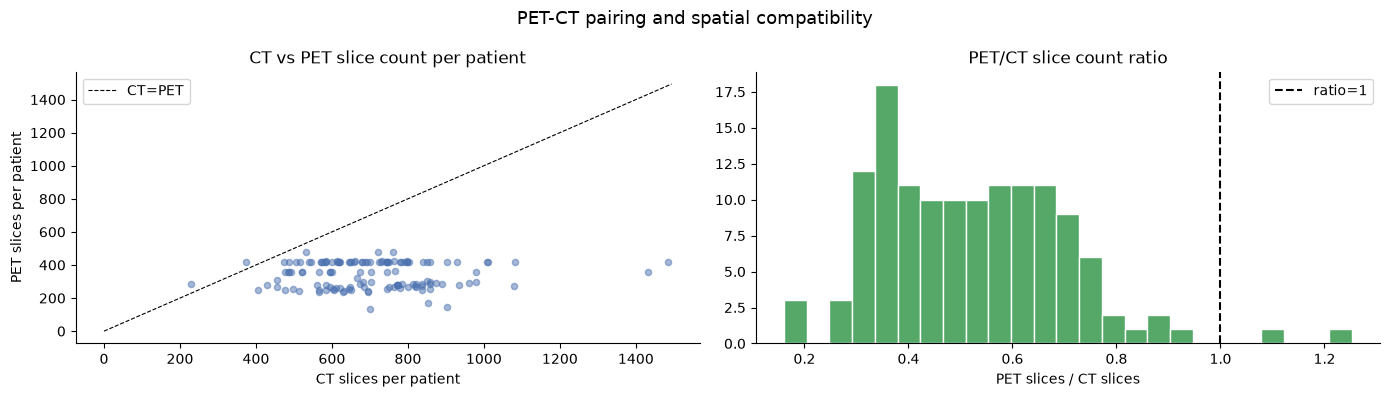

In [42]:
# FA-11: PET-CT pairing analysis

ct_per_pat = (
    ct_img.groupby("Subject ID")
    .agg(ct_series=("Series UID","nunique"), ct_slices=("Number of Images","sum"))
)
pet_per_pat = (
    pt.groupby("Subject ID")
    .agg(pet_series=("Series UID","nunique"), pet_slices=("Number of Images","sum"))
)
ct_date = (meta[meta["Modality"]=="CT"].groupby("Subject ID")["Study Date"]
           .first().rename("ct_date"))
pet_date= (meta[meta["Modality"]=="PT"].groupby("Subject ID")["Study Date"]
           .first().rename("pet_date"))

paired = (ct_per_pat.join(pet_per_pat, how="inner")
                    .join(ct_date, how="left")
                    .join(pet_date, how="left"))
paired["ct_date"]      = pd.to_datetime(paired["ct_date"],  errors="coerce")
paired["pet_date"]     = pd.to_datetime(paired["pet_date"], errors="coerce")
paired["date_diff"]    = (paired["pet_date"] - paired["ct_date"]).dt.days.abs()
paired["same_session"] = paired["date_diff"] == 0
paired["slice_ratio"]  = paired["pet_slices"] / paired["ct_slices"].replace(0, np.nan)

print(f"Patients with both CT and PET: {len(paired)}")
print()
print("CT series per patient (paired subset):")
print(paired["ct_series"].describe().round(2).to_string())
print()
print("PET series per patient:")
print(paired["pet_series"].describe().round(2).to_string())
print()
print("CT slices per patient:")
print(paired["ct_slices"].describe().round(2).to_string())
print()
print("PET slices per patient:")
print(paired["pet_slices"].describe().round(2).to_string())
print()
same_n = paired["same_session"].sum()
print(f"Same-day CT+PET : {same_n}/{len(paired)} patients ({100*same_n/len(paired):.1f}%)")
if paired["date_diff"].notna().any():
    print(f"Date difference : mean={paired['date_diff'].mean():.1f}d  max={paired['date_diff'].max():.0f}d")
print()
print("PET/CT slice count ratio (paired patients):")
print(paired["slice_ratio"].describe().round(3).to_string())
print()
print("Slice count mismatch exists because PET uses thicker slices at the same Z-extent.")
print("Resampling PET to CT voxel space is mandatory before voxel-level fusion.")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].scatter(paired["ct_slices"], paired["pet_slices"], alpha=0.5, color="#4C72B0", s=20)
lim = max(paired["ct_slices"].max(), paired["pet_slices"].max()) + 10
axes[0].plot([0,lim],[0,lim], "k--", linewidth=0.8, label="CT=PET")
axes[0].set_xlabel("CT slices per patient")
axes[0].set_ylabel("PET slices per patient")
axes[0].set_title("CT vs PET slice count per patient")
axes[0].legend()

axes[1].hist(paired["slice_ratio"].dropna(), bins=25, color="#55A868", edgecolor="white")
axes[1].axvline(1.0, color="k", linestyle="--", label="ratio=1")
axes[1].set_title("PET/CT slice count ratio")
axes[1].set_xlabel("PET slices / CT slices")
axes[1].legend()

plt.suptitle("PET-CT pairing and spatial compatibility", fontsize=13)
plt.tight_layout()
plt.show()


### FA-12. Secondary Capture Analysis

In [43]:
# FA-12: Secondary Capture characterisation

print("SECONDARY CAPTURE IMAGE ANALYSIS")
print("=" * 60)
print(f"Total SC series : {len(ct_sc)}")
print(f"SC patients     : {ct_sc['Subject ID'].nunique()}")
print(f"SC images total : {ct_sc['Number of Images'].sum():,}")
print()
sc_pats2  = set(ct_sc["Subject ID"].unique())
pet_pats2 = set(pt["Subject ID"].unique())
print(f"SC patient set identical to PET patient set: {sc_pats2 == pet_pats2}")
print(f"SC patients also in PET: {len(sc_pats2 & pet_pats2)}/{len(sc_pats2)}")
print()

sc_sample = ct_sc.sample(min(20, len(ct_sc)), random_state=42)
sc_records = []
for _, row in sc_sample.iterrows():
    loc = row["File Location"]
    if not os.path.isdir(loc): continue
    files = sorted(glob.glob(os.path.join(loc, "*.dcm")))
    if not files: continue
    try:
        ds = pydicom.dcmread(files[0], stop_before_pixels=True)
    except Exception:
        continue
    sc_records.append({
        "BitsAllocated":    getattr(ds,"BitsAllocated",None),
        "SamplesPerPixel":  getattr(ds,"SamplesPerPixel",None),
        "Photometric":      getattr(ds,"PhotometricInterpretation",None),
        "Rows":             getattr(ds,"Rows",None),
        "Columns":          getattr(ds,"Columns",None),
        "SeriesDesc":       str(getattr(ds,"SeriesDescription","") or ""),
        "RescaleSlope":     getattr(ds,"RescaleSlope",None),
    })

sc_meta_df = pd.DataFrame(sc_records)
if len(sc_meta_df):
    print("SC DICOM properties:")
    for col in ["BitsAllocated","SamplesPerPixel","Photometric","Rows","Columns"]:
        if col in sc_meta_df.columns:
            print(f"  {col}: {sc_meta_df[col].value_counts().to_dict()}")
    print()
    print("SC series descriptions:")
    print(sc_meta_df["SeriesDesc"].value_counts().head(8).to_string())
    print()
    print(f"RescaleSlope present: {sc_meta_df['RescaleSlope'].notna().sum()}/{len(sc_meta_df)}")

print()
print("EXCLUSION JUSTIFICATION:")
print("  1. SamplesPerPixel=3 (RGB) — not quantitative imaging data; HU/SUV cannot be derived.")
print("  2. These are Siemens syngo workstation screenshots of the PET/CT fusion display.")
print("  3. They duplicate information already in CT + PET series, without calibration.")
print("  4. SC images exist only for the 133 PET patients, not all 355 CT patients.")
print("  5. Training on SC would introduce workstation rendering as a confounding variable.")
print("  => Exclude Secondary Capture from all modelling pipelines.")


SECONDARY CAPTURE IMAGE ANALYSIS
Total SC series : 281
SC patients     : 133
SC images total : 57,002

SC patient set identical to PET patient set: True
SC patients also in PET: 133/133

SC DICOM properties:
  BitsAllocated: {8: 20}
  SamplesPerPixel: {3: 20}
  Photometric: {'RGB': 20}
  Rows: {512: 20}
  Columns: {512: 20}

SC series descriptions:
SeriesDesc
Range-CT WB  1.0  B30f-Tra-<ALPHA Range>    17
<ALPHA Range[1]>                             1
<ALPHA Range[2]>                             1
Range-CT WB  1.0  B30f-Tra-<MPR Range>       1

RescaleSlope present: 0/20

EXCLUSION JUSTIFICATION:
  1. SamplesPerPixel=3 (RGB) — not quantitative imaging data; HU/SUV cannot be derived.
  2. These are Siemens syngo workstation screenshots of the PET/CT fusion display.
  3. They duplicate information already in CT + PET series, without calibration.
  4. SC images exist only for the 133 PET patients, not all 355 CT patients.
  5. Training on SC would introduce workstation rendering as a conf

### FA-13. Clinical Metadata by Subtype



Clinical columns: No., NewPatientID, Sex, Age, weight (kg), T-Stage, N-Stage, Ｍ-Stage, Histopathological grading, Smoking History, subtype_code, subtype_name, subtype_c

CLINICAL VARIABLES BY SUBTYPE

  A — Adenocarcinoma (n=251)
    Age: mean=60.9  median=62.0  std=10.2
    Sex: {'F': 133, 'M': 118}
    Weight/BMI: mean=65.1  std=11.8
    Smoking: {0: 160, 1: 91}

  B — Small cell carcinoma (n=38)
    Age: mean=61.3  median=63.5  std=9.6
    Sex: {'M': 21, 'F': 17}
    Weight/BMI: mean=66.7  std=12.0
    Smoking: {0: 20, 1: 18}

  E — Large cell carcinoma (n=5)
    Age: mean=60.6  median=63.0  std=11.8
    Sex: {'M': 4, 'F': 1}
    Weight/BMI: mean=63.0  std=5.7
    Smoking: {1: 3, 0: 2}

  G — Squamous cell carcinoma (n=61)
    Age: mean=62.8  median=61.0  std=9.2
    Sex: {'M': 47, 'F': 14}
    Weight/BMI: mean=65.7  std=12.4
    Smoking: {1: 43, 0: 18}


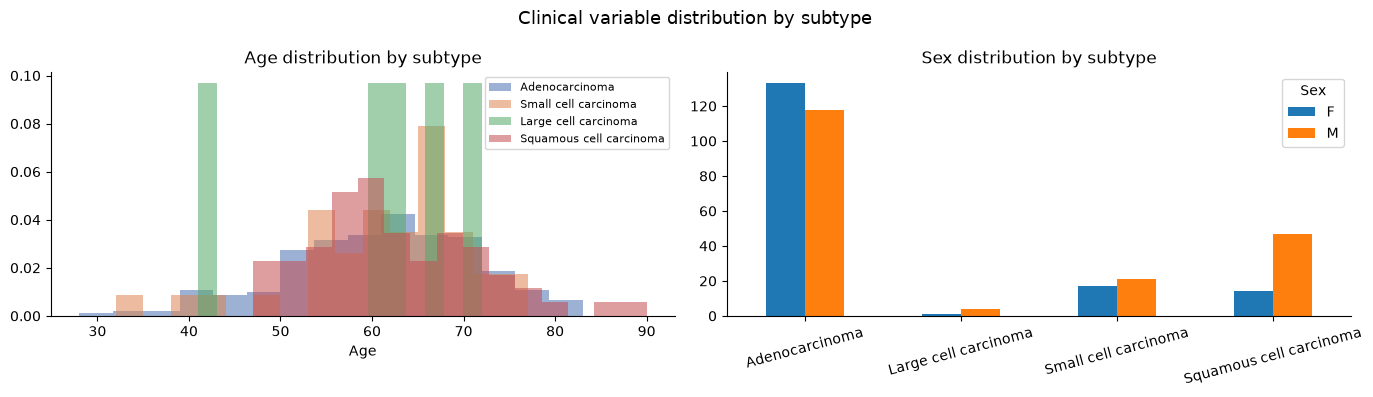

In [44]:
# FA-13: Clinical metadata analysis by subtype

clin_a = clin.copy()
clin_a.columns = [c.strip() for c in clin_a.columns]

# Identify patient ID column
id_col = next((c for c in clin_a.columns
               if any(kw in c.lower() for kw in ["patient","id","subject"])), clin_a.columns[0])
age_col = next((c for c in clin_a.columns if "age" in c.lower()), None)
sex_col = next((c for c in clin_a.columns if "sex" in c.lower() or "gender" in c.lower()), None)
wt_col  = next((c for c in clin_a.columns if "weight" in c.lower() or "bmi" in c.lower()), None)
smk_col = next((c for c in clin_a.columns if "smok" in c.lower()), None)

clin_a["subtype_c"]   = clin_a[id_col].astype(str).str.strip().str[:1]
clin_a["subtype_name"]= clin_a["subtype_c"].map(SUBTYPE_NAME).fillna("?")

print("Clinical columns:", ", ".join(clin_a.columns.tolist()))
print()
print("CLINICAL VARIABLES BY SUBTYPE")
print("=" * 65)
for code in ["A","B","E","G"]:
    sub = clin_a[clin_a["subtype_c"] == code]
    print()
    print(f"  {code} — {SUBTYPE_NAME[code]} (n={len(sub)})")
    if age_col:
        v = pd.to_numeric(sub[age_col], errors="coerce").dropna()
        if len(v): print(f"    Age: mean={v.mean():.1f}  median={v.median():.1f}  std={v.std():.1f}")
    if sex_col:
        print(f"    Sex: {sub[sex_col].value_counts().to_dict()}")
    if wt_col:
        v = pd.to_numeric(sub[wt_col], errors="coerce").dropna()
        if len(v): print(f"    Weight/BMI: mean={v.mean():.1f}  std={v.std():.1f}")
    if smk_col:
        print(f"    Smoking: {sub[smk_col].value_counts().to_dict()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

if age_col:
    for code in ["A","B","E","G"]:
        vals = pd.to_numeric(clin_a[clin_a["subtype_c"]==code][age_col], errors="coerce").dropna()
        if len(vals):
            axes[0].hist(vals, bins=15, alpha=0.55, label=SUBTYPE_NAME[code],
                         color=COLORS[code], density=True)
    axes[0].set_title("Age distribution by subtype")
    axes[0].set_xlabel("Age")
    axes[0].legend(fontsize=8)
else:
    axes[0].text(0.5, 0.5, "Age column not found", ha="center", va="center",
                 transform=axes[0].transAxes)

if sex_col:
    sex_cts = (
        clin_a[clin_a["subtype_c"].isin(["A","B","E","G"])]
        .groupby("subtype_name")[sex_col].value_counts()
        .unstack(fill_value=0)
    )
    sex_cts.plot(kind="bar", ax=axes[1])
    axes[1].set_title("Sex distribution by subtype")
    axes[1].set_xlabel("")
    axes[1].tick_params(axis="x", rotation=15)
else:
    axes[1].text(0.5, 0.5, "Sex column not found", ha="center", va="center",
                 transform=axes[1].transAxes)

plt.suptitle("Clinical variable distribution by subtype", fontsize=13)
plt.tight_layout()
plt.show()


### FA-15. Annotation Label Consistency with Patient Subtype

Do the subtype labels in the XML annotations match the subtype encoded in the patient ID? This determines whether to trust XML labels or use the patient ID as the authoritative subtype source.

In [46]:
# FA-15: Annotation label consistency

boxes_chk = boxes_df.copy()
boxes_chk["expected"]    = boxes_chk["patient_id"].str[0].str.upper()
boxes_chk["actual"]      = boxes_chk["label"].str.strip().str.upper()
boxes_chk["match"]       = boxes_chk["expected"] == boxes_chk["actual"]
boxes_chk["is_standard"] = boxes_chk["actual"].isin({"A","B","E","G"})

total = len(boxes_chk)
matched  = boxes_chk["match"].sum()
non_std  = (~boxes_chk["is_standard"]).sum()

print("ANNOTATION LABEL CONSISTENCY ANALYSIS")
print("=" * 60)
print(f"Total bounding boxes            : {total:,}")
print(f"Labels matching patient ID      : {matched:,}  ({100*matched/total:.1f}%)")
print(f"Non-standard labels (not A/B/E/G): {non_std:,}  ({100*non_std/total:.1f}%)")

print()
print("All unique annotation labels:")
print(boxes_df["label"].value_counts().to_string())

print()
mismatch = boxes_chk[~boxes_chk["match"]]
print(f"MISMATCH CASES (label != patient ID subtype): {len(mismatch)} boxes")
if len(mismatch):
    mm_summary = (mismatch.groupby(["patient_id","expected","actual"])
                  .size().reset_index(name="count"))
    print(mm_summary.to_string(index=False))

print()
print("RECOMMENDATION:")
print("  Use patient ID (Lung_Dx-X####) as the authoritative subtype source.")
print("  Exclude boxes with non-standard labels (Q, numeric IDs, etc.) from training.")
print("  Normalise lowercase labels (a->A, b->B, g->G) for patients with consistent subtypes.")


ANNOTATION LABEL CONSISTENCY ANALYSIS
Total bounding boxes            : 31,659
Labels matching patient ID      : 31,582  (99.8%)
Non-standard labels (not A/B/E/G): 19  (0.1%)

All unique annotation labels:
label
A        13065
a         7911
G         5270
B         2244
g         2089
b          860
E          201
Q           10
A0192        9

MISMATCH CASES (label != patient ID subtype): 77 boxes
patient_id expected actual  count
     A0118        A      Q     10
     A0192        A  A0192      9
     A0212        A      G      4
     A0264        A      B     21
     B0033        B      A     33

RECOMMENDATION:
  Use patient ID (Lung_Dx-X####) as the authoritative subtype source.
  Exclude boxes with non-standard labels (Q, numeric IDs, etc.) from training.
  Normalise lowercase labels (a->A, b->B, g->G) for patients with consistent subtypes.


### FA-17. Detailed HU Statistics by Subtype

Expand the existing HU analysis to include statistical moments and tumour-to-background contrast by subtype, using both lung-window and soft-tissue-window clipping.

DETAILED TUMOUR HU STATISTICS BY SUBTYPE
  Subtype                             n     mean   median      std      IQR       p5      p95
-----------------------------------------------------------------------------------------------
  Adenocarcinoma                346,648   -241.8    -75.0    369.9    639.0   -891.0    171.0
  Small cell carcinoma           21,609   -158.2      2.0    275.2    365.0   -724.0     60.0
  Large cell carcinoma        : n=0 (insufficient)
  Squamous cell carcinoma       277,993   -158.5     11.0    351.7    480.0   -865.0    199.0

TUMOUR-TO-BACKGROUND CONTRAST BY SUBTYPE
  Adenocarcinoma              : tumour=24.1  background=-533.7  contrast=+557.9 HU
  Small cell carcinoma        : tumour=8.5  background=-487.8  contrast=+496.3 HU
  Squamous cell carcinoma     : tumour=49.3  background=-568.1  contrast=+617.4 HU


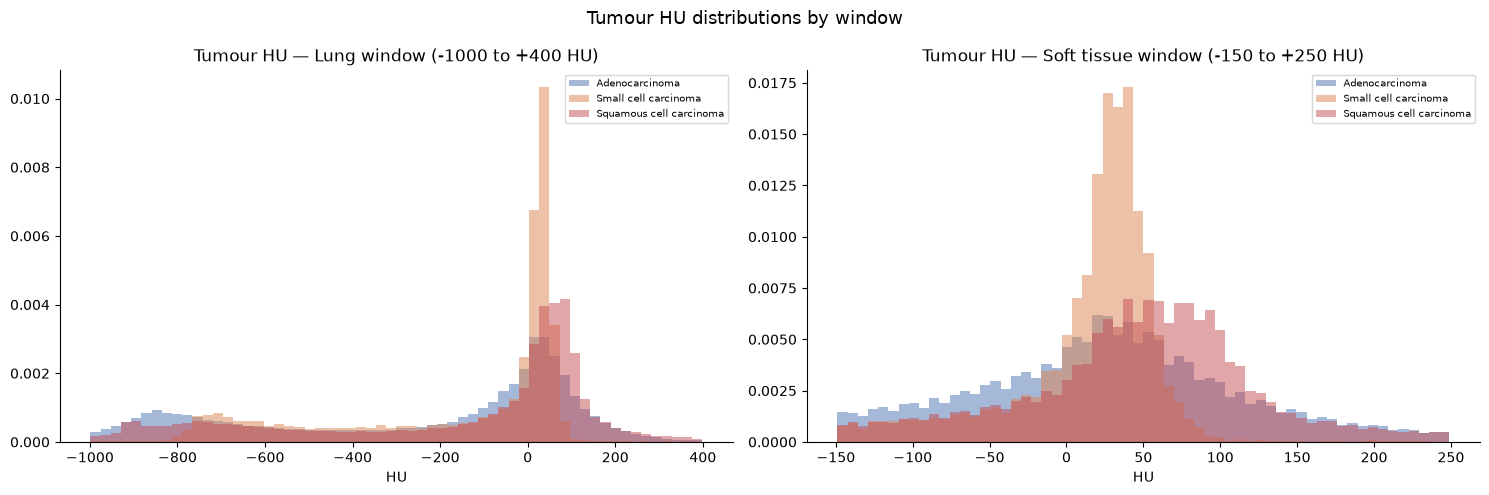

In [48]:
# FA-17: Detailed HU statistics by subtype

try:
    from scipy.stats import skew as _skew, kurtosis as _kurt
    _has_scipy = True
except ImportError:
    _has_scipy = False

print("DETAILED TUMOUR HU STATISTICS BY SUBTYPE")
print("=" * 80)
hdr = f"  {'Subtype':<28} {'n':>8} {'mean':>8} {'median':>8} {'std':>8} {'IQR':>8} {'p5':>8} {'p95':>8}"
if _has_scipy: hdr += f" {'skew':>7} {'kurt':>7}"
print(hdr)
print("-" * (len(hdr)+2))

for code in ["A","B","E","G"]:
    vals = np.array(tumour_hu.get(code, []))
    if len(vals) < 10:
        print(f"  {SUBTYPE_NAME[code]:<28}: n={len(vals)} (insufficient)")
        continue
    vals = vals[(vals > -1000) & (vals < 1000)]
    q25, q75 = np.percentile(vals, [25, 75])
    row = (f"  {SUBTYPE_NAME[code]:<28} {len(vals):>8,} {vals.mean():>8.1f} "
           f"{np.median(vals):>8.1f} {vals.std():>8.1f} {q75-q25:>8.1f} "
           f"{np.percentile(vals,5):>8.1f} {np.percentile(vals,95):>8.1f}")
    if _has_scipy:
        row += f" {_skew(vals):>7.2f} {_kurt(vals):>7.2f}"
    print(row)

print()
print("TUMOUR-TO-BACKGROUND CONTRAST BY SUBTYPE")
print("=" * 55)
for code in ["A","B","E","G"]:
    tv = np.array(tumour_hu.get(code, []))
    bv = np.array(bg_hu.get(code, []))
    if len(tv) < 10 or len(bv) < 10: continue
    tv_c = tv[(tv > -200) & (tv < 400)]
    bv_c = bv[(bv > -1000) & (bv < 400)]
    print(f"  {SUBTYPE_NAME[code]:<28}: tumour={tv_c.mean():.1f}  "
          f"background={bv_c.mean():.1f}  contrast={tv_c.mean()-bv_c.mean():+.1f} HU")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for code in ["A","B","E","G"]:
    vals = np.array(tumour_hu.get(code, []))
    if len(vals) == 0: continue
    axes[0].hist(vals[(vals>-1000)&(vals<400)], bins=60, alpha=0.5,
                 label=SUBTYPE_NAME[code], color=COLORS[code], density=True)
    axes[1].hist(vals[(vals>-150)&(vals<250)], bins=60, alpha=0.5,
                 label=SUBTYPE_NAME[code], color=COLORS[code], density=True)
for ax, title in zip(axes, ["Lung window (-1000 to +400 HU)",
                              "Soft tissue window (-150 to +250 HU)"]):
    ax.set_title(f"Tumour HU — {title}")
    ax.set_xlabel("HU")
    ax.legend(fontsize=7)

plt.suptitle("Tumour HU distributions by window", fontsize=13)
plt.tight_layout()
plt.show()


### FA-18. Visual Atlas

One annotated CT slice per subtype, with bounding box overlaid. Confirms that annotations visually align with tumour regions and reveals qualitative differences.

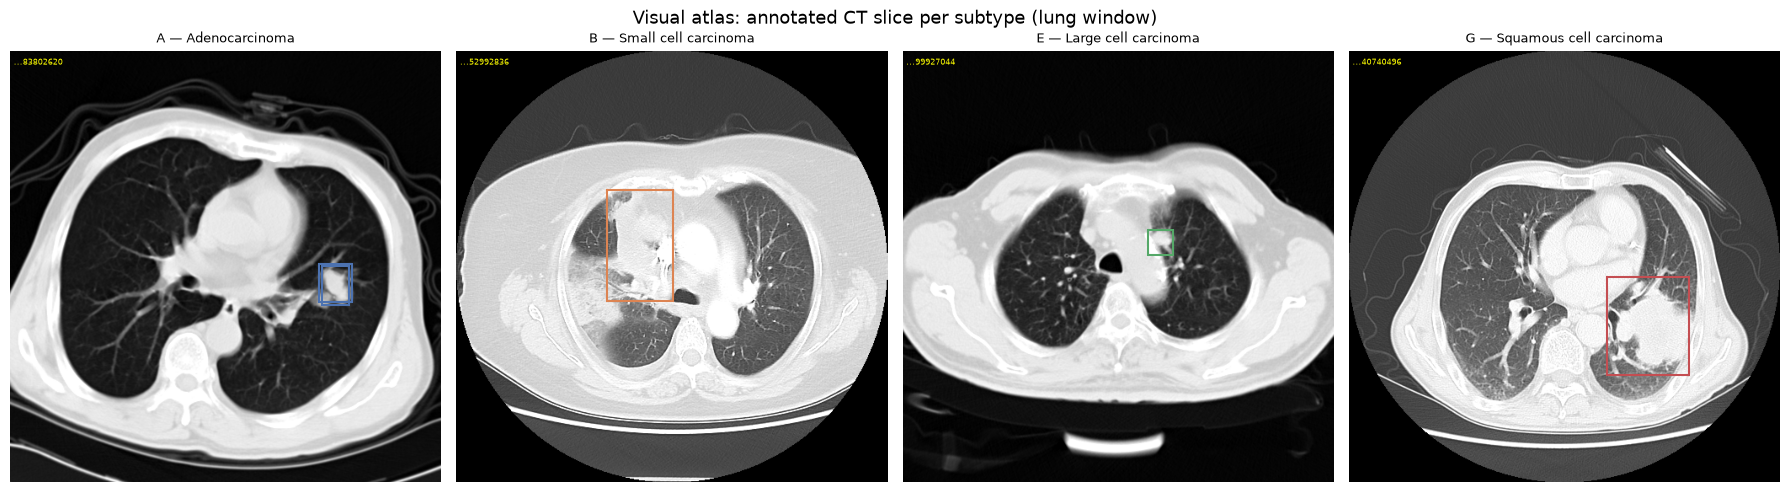

In [49]:
# FA-18: Visual atlas — one annotated CT slice per subtype

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, code in zip(axes, ["A","B","E","G"]):
    ax.set_title(f"{code} — {SUBTYPE_NAME[code]}", fontsize=9)
    ax.axis("off")
    sub_boxes = valid[valid["subtype"] == code]
    found = False
    for sop_uid in sub_boxes["sop_uid"].unique():
        fpath = sop_to_file.get(sop_uid)
        if not fpath: continue
        try:
            ds  = pydicom.dcmread(fpath)
            hu  = ds.pixel_array.astype(np.float32)
            hu  = hu * float(getattr(ds,"RescaleSlope",1)) + float(getattr(ds,"RescaleIntercept",0))
        except Exception:
            continue
        # Lung window: W=1500, L=-600  => [-1350, +150]
        hu_norm = np.clip((hu + 1350) / 1500, 0, 1)
        ax.imshow(hu_norm, cmap="gray", origin="upper")
        for _, box in sub_boxes[sub_boxes["sop_uid"] == sop_uid].iterrows():
            ax.add_patch(patches.Rectangle(
                (box.x1, box.y1), box.w, box.h,
                linewidth=1.5, edgecolor=COLORS[code], facecolor="none"
            ))
        ax.text(4, 16, f"...{sop_uid[-8:]}", color="yellow", fontsize=6)
        found = True
        break
    if not found:
        ax.text(0.5, 0.5, "No indexed DICOM\nfor this subtype",
                ha="center", va="center", fontsize=9, color="gray",
                transform=ax.transAxes)

plt.suptitle("Visual atlas: annotated CT slice per subtype (lung window)", fontsize=13)
plt.tight_layout()
plt.show()


### FA-19. Outlier Patient Analysis

Identify patients with extreme values in slice count, annotation count, bounding box size, or acquisition parameters. Outliers may indicate corrupt data, unusual cases, or quality issues that affect training.

In [50]:
# FA-19: Outlier patient analysis

print("OUTLIER PATIENT ANALYSIS")
print("=" * 65)

ann_series2 = pd.Series(patient_ann_count).sort_values(ascending=False)
print("\nMost annotated slices per patient (top 5):")
print(ann_series2.head(5).to_string())
print("\nFewest annotated slices (excluding 0, bottom 5):")
print(ann_series2[ann_series2 > 0].tail(5).to_string())

if len(ct_params):
    thick = pd.to_numeric(ct_params["SliceThickness"], errors="coerce")
    print(f"\nCT series with slice thickness > 10mm: "
          f"{(thick > 10).sum()} (likely localiser or reformatted series)")
    if (thick > 10).any():
        out_t = ct_params[thick > 10][["patient_id","SliceThickness","ConvolutionKernel"]].drop_duplicates()
        print(out_t.head(10).to_string(index=False))

    ps_vals = ct_params["PixelSpacing"].dropna().apply(
        lambda x: float(x[0]) if isinstance(x,list) else np.nan)
    print(f"\nCT series with pixel spacing > 2.0mm: {(ps_vals > 2).sum()}")

print("\nLargest bounding boxes (area_px):")
print(valid.nlargest(5,"area_px")[["patient_id","subtype","w","h","area_px"]].to_string(index=False))

print("\nSmallest valid bounding boxes (area_px > 0, bottom 5):")
print(valid[valid["area_px"]>0].nsmallest(5,"area_px")[["patient_id","subtype","w","h","area_px"]].to_string(index=False))

ct_series_count = ct_img.groupby("Subject ID")["Series UID"].nunique().sort_values(ascending=False)
print("\nPatients with most CT series:")
print(ct_series_count.head(5).to_string())

ct_slice_count = ct_img.groupby("Subject ID")["Number of Images"].sum().sort_values()
print("\nPatients with fewest total CT slices:")
print(ct_slice_count.head(5).to_string())
print("\nPatients with most total CT slices:")
print(ct_slice_count.tail(5).to_string())


OUTLIER PATIENT ANALYSIS

Most annotated slices per patient (top 5):
A0164    586
G0058    489
B0038    477
A0259    417
A0222    395

Fewest annotated slices (excluding 0, bottom 5):
A0059    4
A0005    2
A0146    2
A0100    2
A0021    2

CT series with slice thickness > 10mm: 1 (likely localiser or reformatted series)
   patient_id  SliceThickness ConvolutionKernel
Lung_Dx-A0040      410.545457          STANDARD

CT series with pixel spacing > 2.0mm: 0

Largest bounding boxes (area_px):
patient_id subtype     w     h  area_px
     G0028       G 159.0 219.0  34821.0
     G0028       G 183.0 189.0  34587.0
     G0022       G 180.0 188.0  33840.0
     G0022       G 187.0 171.0  31977.0
     G0022       G 184.0 164.0  30176.0

Smallest valid bounding boxes (area_px > 0, bottom 5):
patient_id subtype    w    h  area_px
     A0232       A  7.0  9.0     63.0
     A0223       A 13.0  8.0    104.0
     A0232       A 11.0 10.0    110.0
     A0195       A 10.0 12.0    120.0
     A0223       A 1

### FA-20. Patient-Level Split Feasibility

Can conventional train/val/test splits preserve subtype distribution? Large Cell carcinoma (n=5) is the critical constraint.

In [51]:
# FA-20: Patient-level split feasibility

from math import floor as _floor

subtype_pats_fa20 = {}
for code in ["A","B","E","G"]:
    subtype_pats_fa20[code] = set(
        meta[meta["Subject ID"].str.startswith(f"Lung_Dx-{code}")]["Subject ID"].unique()
    )

print("PATIENT-LEVEL SPLIT FEASIBILITY")
print("=" * 70)
print("Patient counts:", {c: len(v) for c, v in subtype_pats_fa20.items()})
print()

for split_name, ratios in [("70/15/15 split", (0.70,0.15,0.15)),
                             ("80/10/10 split", (0.80,0.10,0.10)),
                             ("5-fold CV", None)]:
    print(f"--- {split_name} ---")
    if ratios:
        tr, va, te = ratios
        for code in ["A","B","E","G"]:
            n     = len(subtype_pats_fa20[code])
            n_tr  = _floor(n * tr)
            n_va  = _floor(n * va)
            n_te  = n - n_tr - n_va
            warn  = "  <<< WARNING: <3 in a split" if min(n_tr,n_va,n_te) < 3 else ""
            print(f"  {code} — {SUBTYPE_NAME[code]:<28} n={n:>3}: "
                  f"train={n_tr}  val={n_va}  test={n_te}{warn}")
    else:
        for code in ["A","B","E","G"]:
            n        = len(subtype_pats_fa20[code])
            per_fold = n // 5
            warn = "  <<< <1 per fold" if per_fold < 1 else ""
            print(f"  {code} — {SUBTYPE_NAME[code]:<28} n={n:>3}: "
                  f"~{per_fold} patients per fold{warn}")
    print()

print("KEY FINDING:")
print("  Large Cell (E, n=5) cannot support any standard random split reliably.")
print("  Options: exclude E from classification, treat as 3-class, use leave-one-out for E,")
print("  or report E performance separately as a small-n case study.")
print()
print("  PET+CT fusion cohort has only 133 patients.")
print("  PET subtype distribution:", {c: len(subtype_pats_fa20[c] & set(pt["Subject ID"].unique()))
      for c in ["A","B","E","G"]})


PATIENT-LEVEL SPLIT FEASIBILITY
Patient counts: {'A': 251, 'B': 38, 'E': 5, 'G': 61}

--- 70/15/15 split ---
  A — Adenocarcinoma               n=251: train=175  val=37  test=39
  B — Small cell carcinoma         n= 38: train=26  val=5  test=7
  E — Large cell carcinoma         n=  5: train=3  val=0  test=2  <<< WARNING: <3 in a split
  G — Squamous cell carcinoma      n= 61: train=42  val=9  test=10

--- 80/10/10 split ---
  A — Adenocarcinoma               n=251: train=200  val=25  test=26
  B — Small cell carcinoma         n= 38: train=30  val=3  test=5
  E — Large cell carcinoma         n=  5: train=4  val=0  test=1  <<< WARNING: <3 in a split
  G — Squamous cell carcinoma      n= 61: train=48  val=6  test=7

--- 5-fold CV ---
  A — Adenocarcinoma               n=251: ~50 patients per fold
  B — Small cell carcinoma         n= 38: ~7 patients per fold
  E — Large cell carcinoma         n=  5: ~1 patients per fold
  G — Squamous cell carcinoma      n= 61: ~12 patients per fold

KEY 

### FA-21. Detection Task Feasibility

For object detection training, how many positive and negative slices exist? Are annotations dense enough to support 3D detection, or is 2D detection the only realistic approach?

In [52]:
# FA-21: Detection task feasibility

print("DETECTION TASK FEASIBILITY ANALYSIS")
print("=" * 65)

det_rows = []
for pat_id, n_pos in patient_ann_count.items():
    if n_pos == 0: continue
    full_id  = f"Lung_Dx-{pat_id}"
    total_ct = ct_slices_per_pat.get(full_id, np.nan)
    det_rows.append({
        "patient_id":      pat_id,
        "subtype":         pat_id[0],
        "positive_slices": n_pos,
        "total_ct_slices": total_ct,
        "negative_slices": (total_ct - n_pos) if pd.notna(total_ct) else np.nan,
    })
det_df = pd.DataFrame(det_rows)

tot_pos_d = det_df["positive_slices"].sum()
tot_neg_d = det_df["negative_slices"].dropna().sum()
tot_boxes_d = len(valid)

print(f"Annotated patients (detection-capable): {len(det_df)}")
print(f"Total positive slices (with annotation): {int(tot_pos_d):,}")
print(f"Total negative slices (unannotated CT) : {int(tot_neg_d):,}")
print(f"Overall pos:neg ratio                  : 1 : {tot_neg_d/max(tot_pos_d,1):.0f}")
print(f"Valid bounding boxes total             : {tot_boxes_d:,}")
print(f"Mean boxes per positive slice          : {tot_boxes_d/max(tot_pos_d,1):.2f}")

print()
print("3D DETECTION FEASIBILITY:")
ann_s = pd.Series(patient_ann_count)
print(f"  Patients with only 1 annotated slice : {(ann_s==1).sum()}")
print(f"  Median annotated slice span           : {ann_s[ann_s>0].median():.0f} slices per patient")
if len(ct_params):
    med_thick = pd.to_numeric(ct_params["SliceThickness"], errors="coerce").median()
    if pd.notna(med_thick):
        print(f"  Median CT slice thickness             : {med_thick:.1f} mm")
        print(f"  Estimated median tumour Z-extent      : "
              f"~{ann_s[ann_s>0].median() * med_thick:.0f} mm")
print()
print("  Annotations are 2D slice-level bounding boxes, not 3D volumes.")
print("  Recommendation: train 2D detector per slice; optionally aggregate 3D boxes post-hoc.")

print()
print("By subtype:")
for code in ["A","B","E","G"]:
    sub = det_df[det_df["subtype"]==code]
    if len(sub) == 0: continue
    tot = sub["total_ct_slices"].dropna().sum()
    pos = sub["positive_slices"].sum()
    print(f"  {code} — {SUBTYPE_NAME[code]:<28}: "
          f"n={len(sub):>3}  pos slices={int(pos):>5}  "
          f"coverage={100*pos/max(tot,1):.1f}%")


DETECTION TASK FEASIBILITY ANALYSIS
Annotated patients (detection-capable): 357
Total positive slices (with annotation): 31,562
Total negative slices (unannotated CT) : 173,057
Overall pos:neg ratio                  : 1 : 5
Valid bounding boxes total             : 31,658
Mean boxes per positive slice          : 1.00

3D DETECTION FEASIBILITY:
  Patients with only 1 annotated slice : 0
  Median annotated slice span           : 45 slices per patient
  Median CT slice thickness             : 5.0 mm
  Estimated median tumour Z-extent      : ~225 mm

  Annotations are 2D slice-level bounding boxes, not 3D volumes.
  Recommendation: train 2D detector per slice; optionally aggregate 3D boxes post-hoc.

By subtype:
  A — Adenocarcinoma              : n=253  pos slices=20894  coverage=14.0%
  B — Small cell carcinoma        : n= 38  pos slices= 3116  coverage=21.6%
  E — Large cell carcinoma        : n=  5  pos slices=  201  coverage=24.9%
  G — Squamous cell carcinoma     : n= 61  pos slices= 

### FA-22 & FA-23. Fusion Task Feasibility and CT vs PET Subset Comparison

Is early fusion feasible? And is the PET subset systematically different from the full CT cohort? If so, CT-only and PET+CT results are not directly comparable.

In [53]:
# FA-22: Fusion feasibility
# FA-23: CT full cohort vs PET subset comparison

print("FUSION TASK FEASIBILITY")
print("=" * 65)
ct_set2   = set(meta[meta["Modality"]=="CT"]["Subject ID"].unique())
pet_set2  = set(meta[meta["Modality"]=="PT"]["Subject ID"].unique())
ann_set2  = {f"Lung_Dx-{p}" for p,n in patient_ann_count.items() if n > 0}
paired2   = ct_set2 & pet_set2
pair_ann2 = paired2 & ann_set2

print(f"CT patients (full cohort)              : {len(ct_set2)}")
print(f"PET patients                           : {len(pet_set2)}")
print(f"CT+PET paired (fusion cohort)          : {len(paired2)}")
print(f"CT+PET+annotations (detection fusion)  : {len(pair_ann2)}")
print()

def subtype_dist(pat_set):
    return {c: sum(1 for p in pat_set if p.replace("Lung_Dx-","")[:1]==c)
            for c in "ABEG"}

bd_all    = subtype_dist(ct_set2)
bd_paired = subtype_dist(paired2)
comp_df = pd.DataFrame({
    "Full CT cohort (n=355)": bd_all,
    "CT+PET cohort (n=133)":  bd_paired,
})
comp_df.index = [SUBTYPE_NAME.get(c,c) for c in comp_df.index]
comp_df["% of subtype with PET"] = (100*comp_df["CT+PET cohort (n=133)"] /
                                     comp_df["Full CT cohort (n=355)"].replace(0,np.nan)).round(1)
print("Subtype distribution:")
print(comp_df.to_string())

print()
print("FUSION FEASIBILITY NOTES:")
print("  Early fusion (CT+PET channel stack): feasible for paired 133-patient subset.")
print("  PET must be resampled to CT voxel resolution before stacking.")
print("  Large Cell (E=0 PET) means PET+CT model is 3-class only.")
print("  Missing-modality training needed if deploying on CT-only cases.")
print()

print("=" * 65)
print("CT FULL COHORT vs PET SUBSET COMPARISON (clinical variables)")
print("=" * 65)

if id_col in clin_a.columns:
    clin_a["full_id"] = "Lung_Dx-" + clin_a[id_col].astype(str).str.strip()
    clin_full   = clin_a[clin_a["full_id"].isin(ct_set2)]
    clin_paired = clin_a[clin_a["full_id"].isin(paired2)]

    for col_n, col_lbl in [(age_col,"Age"), (sex_col,"Sex")]:
        if col_n and col_n in clin_a.columns:
            fv = pd.to_numeric(clin_full[col_n],   errors="coerce").dropna()
            pv = pd.to_numeric(clin_paired[col_n], errors="coerce").dropna()
            if len(fv) and len(pv):
                print(f"  {col_lbl}: full CT mean={fv.mean():.1f}  PET subset mean={pv.mean():.1f}")
            else:
                print(f"  {col_lbl} full CT   : {clin_full[col_n].value_counts().to_dict()}")
                print(f"  {col_lbl} PET subset: {clin_paired[col_n].value_counts().to_dict()}")

    print()
    print("  Subtype (full CT)   :", clin_full["subtype_c"].value_counts().sort_index().to_dict())
    print("  Subtype (PET subset):", clin_paired["subtype_c"].value_counts().sort_index().to_dict())

print()
print("If clinical/demographic distributions differ significantly between cohorts,")
print("CT-only and PET+CT model performances cannot be directly compared.")


FUSION TASK FEASIBILITY
CT patients (full cohort)              : 355
PET patients                           : 133
CT+PET paired (fusion cohort)          : 133
CT+PET+annotations (detection fusion)  : 132

Subtype distribution:
                         Full CT cohort (n=355)  CT+PET cohort (n=133)  % of subtype with PET
Adenocarcinoma                              251                     95                   37.8
Small cell carcinoma                         38                      9                   23.7
Large cell carcinoma                          5                      0                    0.0
Squamous cell carcinoma                      61                     29                   47.5

FUSION FEASIBILITY NOTES:
  Early fusion (CT+PET channel stack): feasible for paired 133-patient subset.
  PET must be resampled to CT voxel resolution before stacking.
  Large Cell (E=0 PET) means PET+CT model is 3-class only.
  Missing-modality training needed if deploying on CT-only cases.

CT FULL

###  Annotation folders vs valid metadata patients 

In [ ]:
#  Reconcile annotation folders (disk) with metadata patients 

ann_folders          = set(ann_patient_dirs)
ann_folders_with_xml = {p for p in ann_folders if patient_ann_count.get(p, 0) > 0}
ann_folders_empty    = ann_folders - ann_folders_with_xml

meta_all_pats = set(meta["Subject ID"].str.replace("Lung_Dx-", "", regex=False).unique())
meta_ct_pats  = set(
    meta[meta["Modality"] == "CT"]["Subject ID"]
    .str.replace("Lung_Dx-", "", regex=False).unique()
)

folders_not_in_meta   = ann_folders - meta_all_pats   # XML/folder but no metadata row
ct_pats_no_ann_folder = meta_ct_pats - ann_folders    # CT patient, no annotation folder
usable_ann_patients   = ann_folders_with_xml & meta_ct_pats  # the cohort for CT detection

print("ANNOTATION FOLDERS vs METADATA PATIENTS")
print("=" * 60)
print(f"Annotation folders on disk               : {len(ann_folders)}")
print(f"  ... containing >= 1 XML file           : {len(ann_folders_with_xml)}")
print(f"  ... empty (0 XML files)                : {len(ann_folders_empty)}")
print(f"Patients in metadata.csv (any modality)  : {len(meta_all_pats)}")
print(f"CT patients in metadata.csv              : {len(meta_ct_pats)}")
print()
print(f"Annotation folders WITHOUT a metadata row: {len(folders_not_in_meta)}")
if folders_not_in_meta:
    print(f"   -> {sorted(folders_not_in_meta)}")
print(f"CT patients WITHOUT an annotation folder : {len(ct_pats_no_ann_folder)}")
print(f"USABLE annotated CT patients (XML & meta): {len(usable_ann_patients)}")
print()
print("All subsequent FX cells operate on the USABLE annotated CT patients only.")


ANNOTATION FOLDERS vs METADATA PATIENTS
Annotation folders on disk               : 358
  ... containing >= 1 XML file           : 357
  ... empty (0 XML files)                : 1
Patients in metadata.csv (any modality)  : 355
CT patients in metadata.csv              : 355

Annotation folders WITHOUT a metadata row: 4
   -> ['A0060', 'A0067', 'A0076', 'A0266']
CT patients WITHOUT an annotation folder : 1
USABLE annotated CT patients (XML & meta): 353

All subsequent FX cells operate on the USABLE annotated CT patients only.


### Build full CT SOPInstanceUID index 

One row per CT slice, mapping `SOPInstanceUID` to its file, series, patient, and the spatial metadata (`ImagePositionPatient` Z, `ImageOrientationPatient`, `FrameOfReferenceUID`, `PatientPosition`, pixel spacing, slice thickness) needed by the later tasks. Cached to `ct_full_sop_index.pkl`.

In [ ]:
# Build the complete CT SOP-UID -> file/series/patient index 

CT_INDEX_CACHE = os.path.join(ROOT, "ct_full_sop_index.pkl")
_idx_tags = ["SOPInstanceUID", "ImagePositionPatient", "ImageOrientationPatient",
             "FrameOfReferenceUID", "PatientPosition", "PixelSpacing", "SliceThickness"]

def _build_index(series_df, desc):
    """Read headers for every .dcm in every series folder of series_df."""
    records = []
    for _, srow in tqdm(series_df.iterrows(), total=len(series_df), desc=desc):
        loc = srow["File Location"]
        if not os.path.isdir(loc):
            continue
        series_uid  = srow["Series UID"]
        patient_id  = srow["Subject ID"]
        series_desc = str(srow.get("Series Description", "") or "")
        for fp in glob.glob(os.path.join(loc, "*.dcm")):
            try:
                ds = pydicom.dcmread(fp, stop_before_pixels=True, specific_tags=_idx_tags)
            except Exception:
                continue
            sop = getattr(ds, "SOPInstanceUID", None)
            if sop is None:
                continue
            pos = getattr(ds, "ImagePositionPatient", None)
            z   = float(pos[2]) if (pos is not None and len(pos) >= 3) else np.nan
            ori = getattr(ds, "ImageOrientationPatient", None)
            ori_str = str([round(float(v), 4) for v in ori]) if ori is not None else ""
            ps  = getattr(ds, "PixelSpacing", None)
            st  = getattr(ds, "SliceThickness", None)
            records.append({
                "sop_uid":       str(sop),
                "file":          fp,
                "series_uid":    series_uid,
                "patient_id":    patient_id,
                "series_desc":   series_desc,
                "z_pos":         z,
                "frame_of_ref":  str(getattr(ds, "FrameOfReferenceUID", "") or ""),
                "orientation":   ori_str,
                "patient_pos":   str(getattr(ds, "PatientPosition", "") or ""),
                "pixel_spacing": float(ps[0]) if ps is not None else np.nan,
                "slice_thick":   float(st) if st is not None else np.nan,
            })
    return pd.DataFrame(records)

if os.path.exists(CT_INDEX_CACHE):
    ct_index_df = pd.read_pickle(CT_INDEX_CACHE)
    print(f"Loaded cached CT index: {len(ct_index_df):,} slices")
else:
    print("Building full CT index (one-time; reads every CT DICOM header)...")
    ct_index_df = _build_index(ct_img, "Indexing CT slices")
    ct_index_df.to_pickle(CT_INDEX_CACHE)
    print(f"Built and cached CT index: {len(ct_index_df):,} slices")

print(f"Unique SOP UIDs : {ct_index_df['sop_uid'].nunique():,}")
print(f"Unique series   : {ct_index_df['series_uid'].nunique():,}")
print(f"Unique patients : {ct_index_df['patient_id'].nunique():,}")
print(f"Slices with valid Z position: {ct_index_df['z_pos'].notna().sum():,}")


Loaded cached CT index: 148,457 slices
Unique SOP UIDs : 148,457
Unique series   : 881
Unique patients : 355
Slices with valid Z position: 148,457


###  Annotated CT series via the full index 

With every CT slice indexed, each annotation `SOPInstanceUID` can now be traced to its exact CT series. This replaces the sampled FA-2 estimate and reveals what fraction of annotations are truly traceable and whether they concentrate in one series per patient.

In [ ]:
# Recalculate annotated CT series using the full index 

ann_sop  = set(boxes_df["sop_uid"].unique())
idx_ann  = ct_index_df[ct_index_df["sop_uid"].isin(ann_sop)].copy()
traceable = set(idx_ann["sop_uid"].unique())

print("ANNOTATION TRACEABILITY (full index)")
print("=" * 55)
print(f"Distinct annotation SOP UIDs (XML)   : {len(ann_sop):,}")
print(f"Traceable to a CT slice              : {len(traceable):,}  "
      f"({100*len(traceable)/max(len(ann_sop),1):.1f}%)")
print(f"Untraceable (no CT slice match)      : {len(ann_sop - traceable):,}")
print()

ann_series_per_pat = idx_ann.groupby("patient_id")["series_uid"].nunique()
dist = Counter(ann_series_per_pat.values)
print("Annotated CT series per patient:")
for k in sorted(dist):
    print(f"  {k} annotated series: {dist[k]} patients")
print()
print(f"Patients whose annotations span > 1 CT series: {(ann_series_per_pat > 1).sum()}")

ann_series_ids = set(idx_ann["series_uid"].unique())
print(f"Distinct annotated CT series total           : {len(ann_series_ids)}")
print()
desc_counts = (
    ct_index_df[ct_index_df["series_uid"].isin(ann_series_ids)]
    .drop_duplicates("series_uid")["series_desc"].replace("", "(blank)").value_counts()
)
print("Series descriptions of the annotated CT series:")
print(desc_counts.head(15).to_string())
print()
print("Interpretation: annotations concentrate in a single CT reconstruction per")
print("patient; train detection on that specific annotated series, not all CT series.")


ANNOTATION TRACEABILITY (full index)
Distinct annotation SOP UIDs (XML)   : 31,399
Traceable to a CT slice              : 20,381  (64.9%)
Untraceable (no CT slice match)      : 11,018

Annotated CT series per patient:
  1 annotated series: 7 patients
  2 annotated series: 292 patients
  3 annotated series: 23 patients
  4 annotated series: 15 patients
  5 annotated series: 8 patients
  6 annotated series: 10 patients

Patients whose annotations span > 1 CT series: 348
Distinct annotated CT series total           : 820

Series descriptions of the annotated CT series:
series_desc
Thorax  1.0  B70f             129
5mm                           110
Thorax  1.0  B31f              91
5mm Lung SS50                  90
A phase 5mm Stnd SS50          69
ThoraxRoutine  10.0  B40f      43
Recon 2 5mm                    43
CT WB  1.0  B30f               43
ThoraxRoutine  5.0.0  B70f     38
5mm Stnd SS50                  27
lung iDose 3                   14
iDose 2                        12
iDose 4

###  Coverage and positive/negative slices within the annotated series 

FA-3/FA-4 measured coverage against *all* CT slices a patient had — which is misleading when a patient has several reconstructions. The correct denominator is the **annotated series itself**. Negatives are the unannotated slices *within that series*, which is the true background pool a 2D detector would see.

COVERAGE WITHIN ANNOTATED CT SERIES (full index)
       total_slices  positive_slices  negative_slices  coverage_pct
count        355.00           355.00           355.00        355.00
mean         415.97            57.41           358.56         15.59
std          329.75            54.84           298.42         11.02
min           16.00             2.00             0.00          2.08
25%          127.00            18.00           111.00          8.58
50%          248.00            39.00           210.00         12.66
75%          674.00            78.00           569.50         19.60
max         1715.00           361.00          1647.00        100.00

By subtype (median coverage within annotated series):
  A - Adenocarcinoma              : n=251  median coverage=11.3%  median positive slices=35
  B - Small cell carcinoma        : n= 38  median coverage=18.0%  median positive slices=30
  E - Large cell carcinoma        : n=  5  median coverage=22.9%  median positive slices=43
  G - Sq

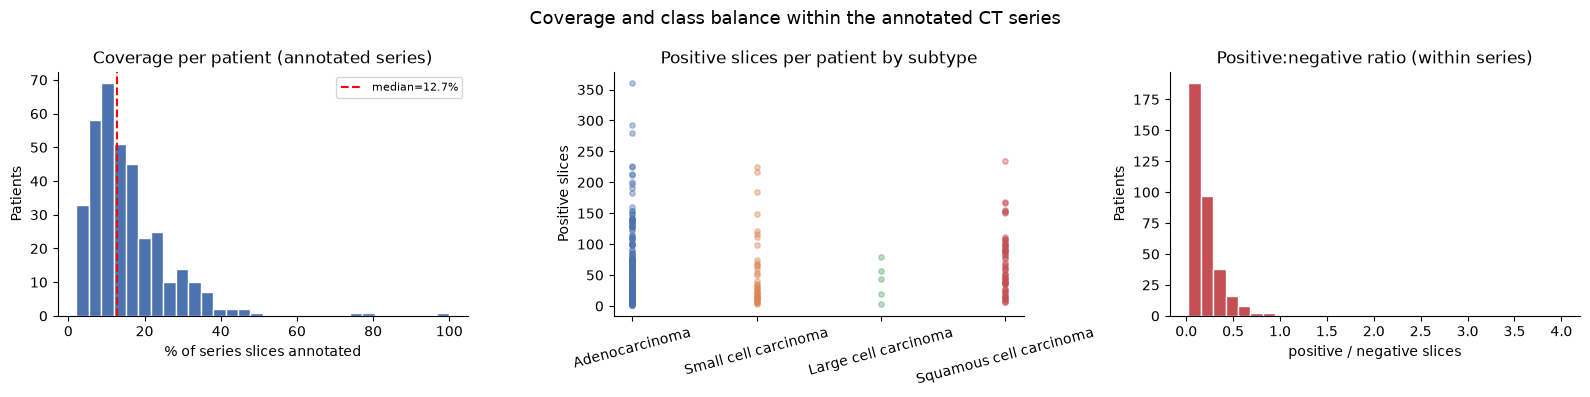

In [ ]:
# Coverage and pos/neg restricted to the annotated CT series 

series_total = ct_index_df.groupby("series_uid").size()                 # all slices/series
series_pos   = idx_ann.groupby("series_uid")["sop_uid"].nunique()       # annotated/series
series_to_pat = (
    ct_index_df.drop_duplicates("series_uid").set_index("series_uid")["patient_id"]
)

cov_rows = []
for su in ann_series_ids:
    total = int(series_total.get(su, 0))
    pos   = int(series_pos.get(su, 0))
    pat   = series_to_pat.get(su, "?")
    code  = pat.replace("Lung_Dx-", "")[:1]
    cov_rows.append({
        "series_uid": su, "patient_id": pat, "subtype": code,
        "total_slices": total, "positive_slices": pos,
        "negative_slices": max(total - pos, 0),
        "coverage_pct": (100 * pos / total) if total else np.nan,
    })
cov_series_df = pd.DataFrame(cov_rows)

cov_pat = (
    cov_series_df.groupby("patient_id")
    .agg(subtype=("subtype", "first"),
         n_ann_series=("series_uid", "nunique"),
         total_slices=("total_slices", "sum"),
         positive_slices=("positive_slices", "sum"),
         negative_slices=("negative_slices", "sum"))
    .reset_index()
)
cov_pat["coverage_pct"] = 100 * cov_pat["positive_slices"] / cov_pat["total_slices"]

print("COVERAGE WITHIN ANNOTATED CT SERIES (full index)")
print("=" * 60)
print(cov_pat[["total_slices", "positive_slices", "negative_slices", "coverage_pct"]]
      .describe().round(2).to_string())
print()
print("By subtype (median coverage within annotated series):")
for code in ["A", "B", "E", "G"]:
    sub = cov_pat[cov_pat["subtype"] == code]
    if len(sub) == 0:
        continue
    print(f"  {code} - {SUBTYPE_NAME[code]:<28}: n={len(sub):>3}  "
          f"median coverage={sub['coverage_pct'].median():.1f}%  "
          f"median positive slices={sub['positive_slices'].median():.0f}")
print()

tot_pos = int(cov_pat["positive_slices"].sum())
tot_neg = int(cov_pat["negative_slices"].sum())
print("POSITIVE vs NEGATIVE (within annotated series only)")
print("=" * 60)
print(f"Positive slices (annotated)            : {tot_pos:,}")
print(f"Negative slices (unannotated in series): {tot_neg:,}")
print(f"Pos:neg ratio                          : 1 : {tot_neg/max(tot_pos,1):.1f}")
print()
print("Contrast with FA-4 (all CT slices as negatives): restricting to the annotated")
print("series gives a far less extreme imbalance and a defensible negative pool.")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(cov_pat["coverage_pct"].dropna(), bins=30, color="#4C72B0", edgecolor="white")
axes[0].axvline(cov_pat["coverage_pct"].median(), color="red", linestyle="--",
                label=f"median={cov_pat['coverage_pct'].median():.1f}%")
axes[0].set_title("Coverage per patient (annotated series)")
axes[0].set_xlabel("% of series slices annotated")
axes[0].set_ylabel("Patients")
axes[0].legend(fontsize=8)

for code in ["A", "B", "E", "G"]:
    s = cov_pat[cov_pat["subtype"] == code]["positive_slices"]
    axes[1].scatter([SUBTYPE_NAME[code]] * len(s), s, alpha=0.4, color=COLORS[code], s=15)
axes[1].set_title("Positive slices per patient by subtype")
axes[1].set_ylabel("Positive slices")
axes[1].tick_params(axis="x", rotation=15)

ratio = cov_pat["positive_slices"] / cov_pat["negative_slices"].replace(0, np.nan)
axes[2].hist(ratio.dropna(), bins=30, color="#C44E52", edgecolor="white")
axes[2].set_title("Positive:negative ratio (within series)")
axes[2].set_xlabel("positive / negative slices")
axes[2].set_ylabel("Patients")

plt.suptitle("Coverage and class balance within the annotated CT series", fontsize=13)
plt.tight_layout()
plt.show()


###Tumour Z-span from ImagePositionPatient 

FA-5 approximated the tumour's craniocaudal extent as (annotated slice count x slice thickness), which ignores slice gaps and overlaps. Here we use the actual `z` coordinates of the annotated slices to measure the true span in millimetres.

TUMOUR Z-SPAN FROM ImagePositionPatient (mm)
count    355.0
mean      48.7
std       44.3
min        0.0
25%       21.4
50%       35.0
75%       60.0
max      367.5

By subtype (median true Z-span):
  A - Adenocarcinoma              : n=251  median Z-span=30.0 mm  (rough estimate=80.0 mm)
  B - Small cell carcinoma        : n= 38  median Z-span=47.5 mm  (rough estimate=116.0 mm)
  E - Large cell carcinoma        : n=  5  median Z-span=60.0 mm  (rough estimate=215.0 mm)
  G - Squamous cell carcinoma     : n= 61  median Z-span=50.0 mm  (rough estimate=112.0 mm)

Correlation (true Z-span vs rough estimate): r = 0.503
Differences arise from slice gaps/overlap and non-contiguous annotations.


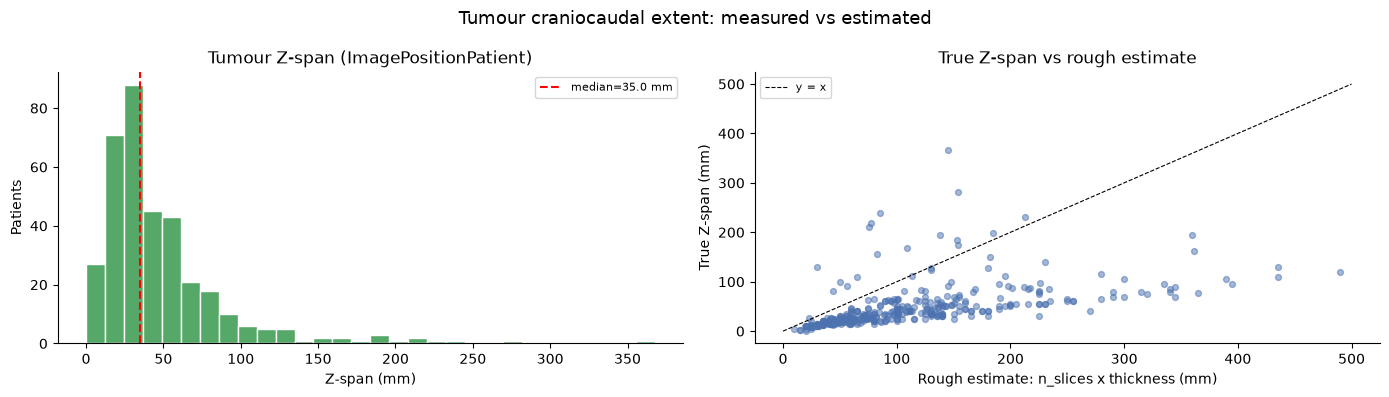

In [59]:
# FX-5: Real Z-span from ImagePositionPatient (Task 5)

z_rows = []
for pat, g in idx_ann.groupby("patient_id"):
    zs = g["z_pos"].dropna()
    if len(zs) == 0:
        continue
    code = pat.replace("Lung_Dx-", "")[:1]
    n_ann = g["sop_uid"].nunique()
    thick = g["slice_thick"].dropna().median()
    z_rows.append({
        "patient_id": pat, "subtype": code,
        "n_ann_slices": n_ann,
        "z_min": zs.min(), "z_max": zs.max(),
        "z_span_mm": zs.max() - zs.min(),
        "rough_extent_mm": n_ann * thick if pd.notna(thick) else np.nan,
    })
zspan_df = pd.DataFrame(z_rows)

print("TUMOUR Z-SPAN FROM ImagePositionPatient (mm)")
print("=" * 55)
print(zspan_df["z_span_mm"].describe().round(1).to_string())
print()
print("By subtype (median true Z-span):")
for code in ["A", "B", "E", "G"]:
    sub = zspan_df[zspan_df["subtype"] == code]
    if len(sub) == 0:
        continue
    print(f"  {code} - {SUBTYPE_NAME[code]:<28}: n={len(sub):>3}  "
          f"median Z-span={sub['z_span_mm'].median():.1f} mm  "
          f"(rough estimate={sub['rough_extent_mm'].median():.1f} mm)")
print()

comp = zspan_df.dropna(subset=["z_span_mm", "rough_extent_mm"])
if len(comp) > 2:
    corr = comp["z_span_mm"].corr(comp["rough_extent_mm"])
    print(f"Correlation (true Z-span vs rough estimate): r = {corr:.3f}")
    print("Differences arise from slice gaps/overlap and non-contiguous annotations.")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(zspan_df["z_span_mm"].dropna(), bins=30, color="#55A868", edgecolor="white")
axes[0].axvline(zspan_df["z_span_mm"].median(), color="red", linestyle="--",
                label=f"median={zspan_df['z_span_mm'].median():.1f} mm")
axes[0].set_title("Tumour Z-span (ImagePositionPatient)")
axes[0].set_xlabel("Z-span (mm)")
axes[0].set_ylabel("Patients")
axes[0].legend(fontsize=8)

if len(comp) > 2:
    axes[1].scatter(comp["rough_extent_mm"], comp["z_span_mm"], alpha=0.5,
                    color="#4C72B0", s=18)
    lim = max(comp["rough_extent_mm"].max(), comp["z_span_mm"].max()) + 10
    axes[1].plot([0, lim], [0, lim], "k--", linewidth=0.8, label="y = x")
    axes[1].set_xlabel("Rough estimate: n_slices x thickness (mm)")
    axes[1].set_ylabel("True Z-span (mm)")
    axes[1].set_title("True Z-span vs rough estimate")
    axes[1].legend(fontsize=8)

plt.suptitle("Tumour craniocaudal extent: measured vs estimated", fontsize=13)
plt.tight_layout()
plt.show()


### PET-CT geometric compatibility 

For voxel-level fusion, PET and CT must share a spatial frame. We build the full PET index, then for each paired patient check whether CT and PET share a `FrameOfReferenceUID` (the DICOM guarantee of co-registration) and how much their axial Z-ranges overlap. A shared frame of reference means no external registration is required — only resampling to a common grid.

Loaded cached PET index: 45,676 slices

PET-CT GEOMETRIC COMPATIBILITY
Paired patients (CT and PET both present): 133
Sharing a FrameOfReferenceUID            : 103/133 (77.4%)
Median CT/PET axial Z-overlap            : 100.0% of CT range

Frame-of-reference sharing by subtype:
  A - Adenocarcinoma              : 75/95 share FoR
  B - Small cell carcinoma        : 4/9 share FoR
  G - Squamous cell carcinoma     : 24/29 share FoR

Some paired studies do NOT share a frame of reference: those require explicit
registration before fusion, or should be flagged/excluded.


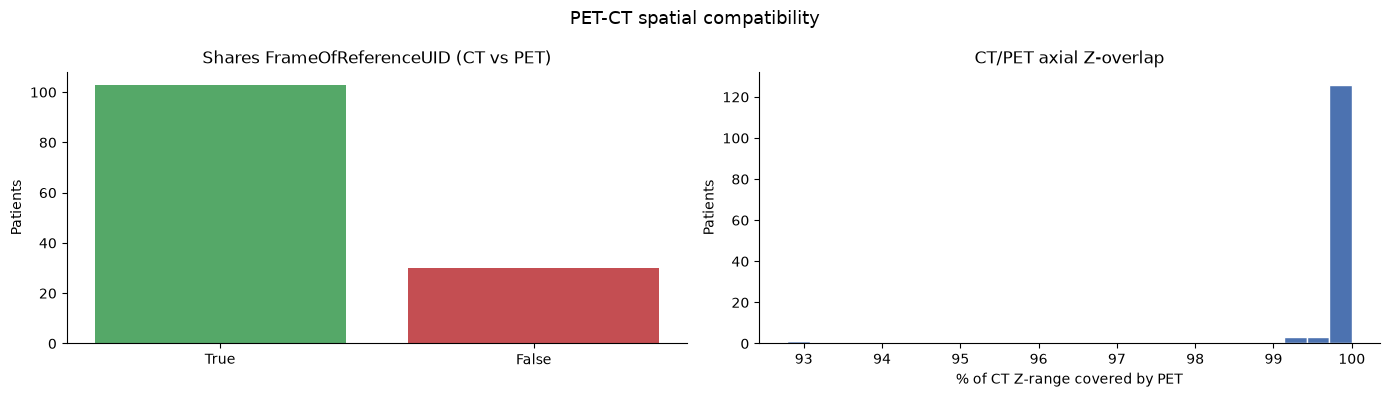

In [ ]:
# PET-CT geometric compatibility via FrameOfReferenceUID + Z-range

PET_INDEX_CACHE = os.path.join(ROOT, "pet_full_sop_index.pkl")
if os.path.exists(PET_INDEX_CACHE):
    pet_index_df = pd.read_pickle(PET_INDEX_CACHE)
    print(f"Loaded cached PET index: {len(pet_index_df):,} slices")
else:
    print("Building full PET index (one-time; reads every PET DICOM header)...")
    pet_index_df = _build_index(pt, "Indexing PET slices")
    pet_index_df.to_pickle(PET_INDEX_CACHE)
    print(f"Built and cached PET index: {len(pet_index_df):,} slices")
print()

ct_for  = ct_index_df.groupby("patient_id")["frame_of_ref"].agg(lambda s: set(s) - {""})
pet_for = pet_index_df.groupby("patient_id")["frame_of_ref"].agg(lambda s: set(s) - {""})
paired_pats = sorted(set(ct_for.index) & set(pet_for.index))

geo_rows = []
for pat in paired_pats:
    shared = ct_for[pat] & pet_for[pat]
    ct_z  = ct_index_df[ct_index_df["patient_id"] == pat]["z_pos"].dropna()
    pet_z = pet_index_df[pet_index_df["patient_id"] == pat]["z_pos"].dropna()
    ovl_pct = np.nan
    if len(ct_z) and len(pet_z):
        lo = max(ct_z.min(), pet_z.min())
        hi = min(ct_z.max(), pet_z.max())
        overlap  = max(0.0, hi - lo)
        ct_range = ct_z.max() - ct_z.min()
        ovl_pct  = (100 * overlap / ct_range) if ct_range else np.nan
    geo_rows.append({
        "patient_id": pat,
        "subtype": pat.replace("Lung_Dx-", "")[:1],
        "shares_frame_of_ref": len(shared) > 0,
        "ct_for_count": len(ct_for[pat]),
        "pet_for_count": len(pet_for[pat]),
        "z_overlap_pct": ovl_pct,
    })
geo_df = pd.DataFrame(geo_rows)

print("PET-CT GEOMETRIC COMPATIBILITY")
print("=" * 55)
print(f"Paired patients (CT and PET both present): {len(geo_df)}")
if len(geo_df):
    n_shared = int(geo_df["shares_frame_of_ref"].sum())
    print(f"Sharing a FrameOfReferenceUID            : {n_shared}/{len(geo_df)} "
          f"({100*n_shared/len(geo_df):.1f}%)")
    print(f"Median CT/PET axial Z-overlap            : "
          f"{geo_df['z_overlap_pct'].median():.1f}% of CT range")
    print()
    print("Frame-of-reference sharing by subtype:")
    for code in ["A", "B", "E", "G"]:
        sub = geo_df[geo_df["subtype"] == code]
        if len(sub) == 0:
            continue
        print(f"  {code} - {SUBTYPE_NAME[code]:<28}: "
              f"{int(sub['shares_frame_of_ref'].sum())}/{len(sub)} share FoR")
    print()
    if n_shared == len(geo_df):
        print("All paired studies share a frame of reference: PET and CT are intrinsically")
        print("co-registered. Fusion needs only resampling to a common voxel grid.")
    else:
        print("Some paired studies do NOT share a frame of reference: those require explicit")
        print("registration before fusion, or should be flagged/excluded.")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    vc = geo_df["shares_frame_of_ref"].value_counts()
    axes[0].bar([str(k) for k in vc.index], vc.values, color=["#55A868", "#C44E52"])
    axes[0].set_title("Shares FrameOfReferenceUID (CT vs PET)")
    axes[0].set_ylabel("Patients")
    axes[1].hist(geo_df["z_overlap_pct"].dropna(), bins=25, color="#4C72B0", edgecolor="white")
    axes[1].set_title("CT/PET axial Z-overlap")
    axes[1].set_xlabel("% of CT Z-range covered by PET")
    axes[1].set_ylabel("Patients")
    plt.suptitle("PET-CT spatial compatibility", fontsize=13)
    plt.tight_layout()
    plt.show()


###  Image-left/right vs anatomical laterality 

FA-6 labelled boxes with `cx < 256` as 'left lung' — but that is the **image** left, not the patient's anatomy. Under the standard axial orientation `ImageOrientationPatient = [1,0,0,0,1,0]` with head-first-supine positioning, increasing column index runs toward the patient's **left**, so image-left (low `cx`) is actually the patient's **right** lung (radiological convention). Here we verify the orientation before asserting any anatomical side.

CT ORIENTATION / POSITION AUDIT
ImageOrientationPatient (top values):
orientation
[1.0, 0.0, 0.0, 0.0, 1.0, 0.0]      148456
[1.0, -0.0, 0.0, 0.0, 0.0, -1.0]         1

PatientPosition (top values):
patient_pos
HFS    120606
FFS     27851

Slices with standard axial orientation : 100.0%
Slices with PatientPosition == HFS     : 81.2%

BOUNDING-BOX LATERALITY (corrected terminology)
Boxes with verifiable standard axial geometry: 20,551/31,658

Image-left  (cx <  256): 47.4%
Image-right (cx >= 256): 52.6%

Under verified standard-axial + head-first-supine geometry, image-left maps
to the patient's RIGHT side (radiological convention):
  Anatomical RIGHT lung (image-left) : 49.0%
  Anatomical LEFT  lung (image-right): 51.0%


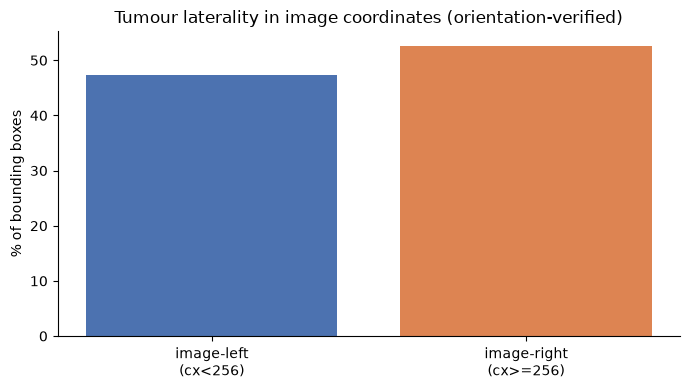


Note: FA-6's 'left/right lung' labels are image-side labels. The anatomical
mapping above supersedes them for any clinical laterality claim.


In [ ]:
# Verify orientation, then relabel laterality correctly 

import ast as _ast

def _is_std_axial(s):
    """True if ImageOrientationPatient is ~[1,0,0,0,1,0] (standard axial)."""
    try:
        v = _ast.literal_eval(s)
        return (abs(v[0]-1) < 0.05 and abs(v[1]) < 0.05 and abs(v[2]) < 0.05 and
                abs(v[3]) < 0.05 and abs(v[4]-1) < 0.05 and abs(v[5]) < 0.05)
    except Exception:
        return False

ori_counts = ct_index_df["orientation"].replace("", "(missing)").value_counts()
pos_counts = ct_index_df["patient_pos"].replace("", "(missing)").value_counts()

print("CT ORIENTATION / POSITION AUDIT")
print("=" * 55)
print("ImageOrientationPatient (top values):")
print(ori_counts.head(8).to_string())
print()
print("PatientPosition (top values):")
print(pos_counts.head(8).to_string())
print()

std_mask  = ct_index_df["orientation"].apply(_is_std_axial)
frac_std  = 100 * std_mask.mean()
hfs_frac  = 100 * (ct_index_df["patient_pos"] == "HFS").mean()
print(f"Slices with standard axial orientation : {frac_std:.1f}%")
print(f"Slices with PatientPosition == HFS     : {hfs_frac:.1f}%")
print()

# Attach orientation/position to annotated boxes via the full index
sop_geom = ct_index_df.drop_duplicates("sop_uid").set_index("sop_uid")[
    ["orientation", "patient_pos"]
]
loc_chk = valid.merge(sop_geom, left_on="sop_uid", right_index=True, how="left")
loc_chk["cx"] = (loc_chk["x1"] + loc_chk["x2"]) / 2
loc_chk["std_axial"] = loc_chk["orientation"].apply(_is_std_axial)
loc_chk["hfs"]       = loc_chk["patient_pos"] == "HFS"

verifiable = loc_chk[loc_chk["std_axial"]]
img_left_pct = 100 * (loc_chk["cx"] < 256).mean()

print("BOUNDING-BOX LATERALITY (corrected terminology)")
print("=" * 55)
print(f"Boxes with verifiable standard axial geometry: "
      f"{len(verifiable):,}/{len(loc_chk):,}")
print()
print(f"Image-left  (cx <  256): {img_left_pct:.1f}%")
print(f"Image-right (cx >= 256): {100 - img_left_pct:.1f}%")
print()
if len(verifiable) and verifiable["hfs"].mean() > 0.5:
    vleft = 100 * (verifiable["cx"] < 256).mean()
    print("Under verified standard-axial + head-first-supine geometry, image-left maps")
    print("to the patient's RIGHT side (radiological convention):")
    print(f"  Anatomical RIGHT lung (image-left) : {vleft:.1f}%")
    print(f"  Anatomical LEFT  lung (image-right): {100 - vleft:.1f}%")
else:
    print("Orientation/position not uniformly verifiable -> report only image-left/right;")
    print("do NOT assert anatomical laterality without per-slice geometry checks.")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["image-left\n(cx<256)", "image-right\n(cx>=256)"],
       [img_left_pct, 100 - img_left_pct], color=["#4C72B0", "#DD8452"])
ax.set_ylabel("% of bounding boxes")
ax.set_title("Tumour laterality in image coordinates (orientation-verified)")
plt.tight_layout()
plt.show()

print()
print("Note: FA-6's 'left/right lung' labels are image-side labels. The anatomical")
print("mapping above supersedes them for any clinical laterality claim.")
